# Segmentation + Evaluation

BROKEN

2025-08-04 01:54:23 — INFO — Evaluation notebook start.
2025-08-04 01:54:23 — INFO — Installing python-dotenv (missing)
2025-08-04 01:54:24 — INFO — Installing Pillow (missing)
2025-08-04 01:54:26 — INFO — Installing google-genai (missing)
2025-08-04 01:54:27 — INFO — GenAI client initialized.
2025-08-04 01:54:27 — INFO — ISIC 2017 dataset found at D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1
2025-08-04 01:54:27 — INFO — Starting evaluation run for model: gemini-2.5-flash on ISIC 2017 dataset.
2025-08-04 01:54:27 — INFO — Detailed predictions will be saved to: D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\predictions_gemini-2.5-flash
2025-08-04 01:54:27 — INFO — --- Starting Pre-Run Validation ---
2025-08-04 01:54:28 — INFO — Validation complete. Found 4074 unique, valid image-mask pairs.
2025-08-04 01:54:28 — INFO — Full evaluation sample size is 4074 images.
2025-08-04 01:54:28 — INFO — Found 2750 existing predictions in cache.
2025-08-04 01:54:28 — INFO — 
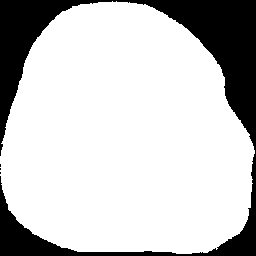
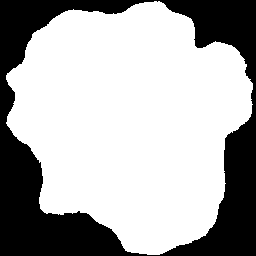
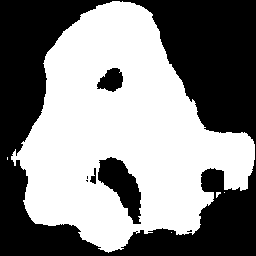
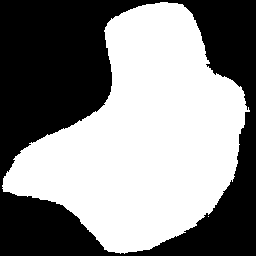
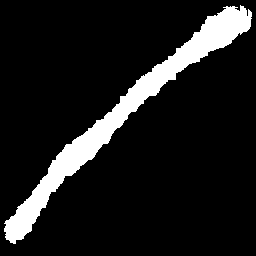
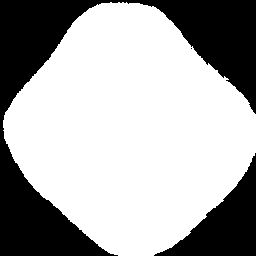
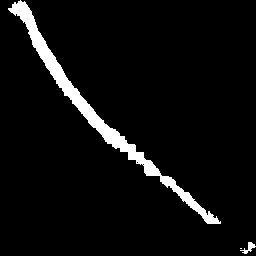
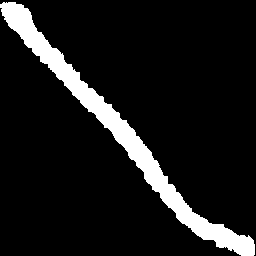
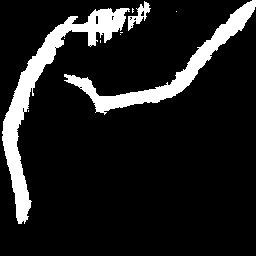
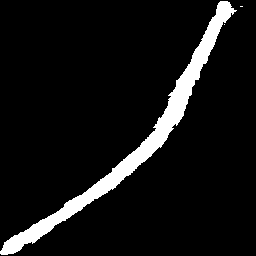
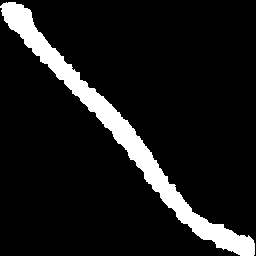
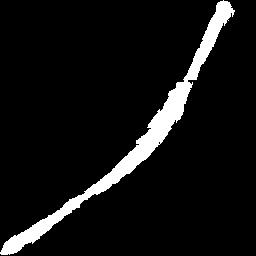
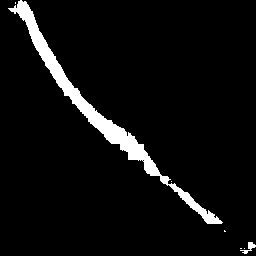
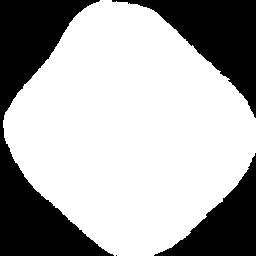
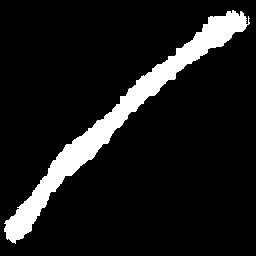
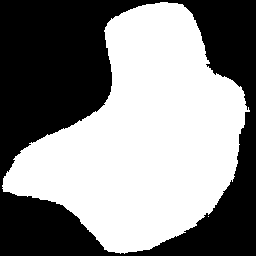
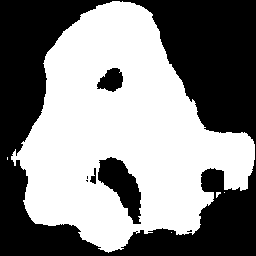
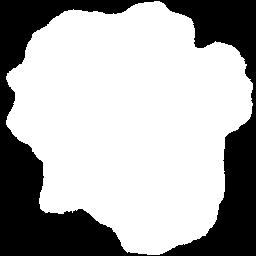
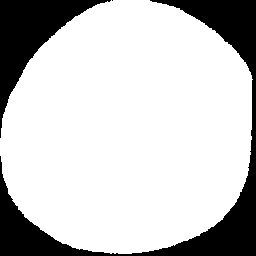
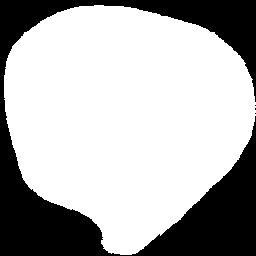
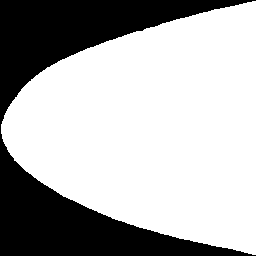
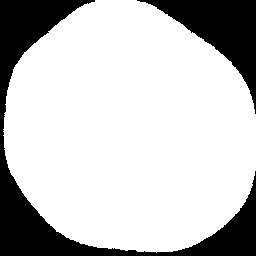
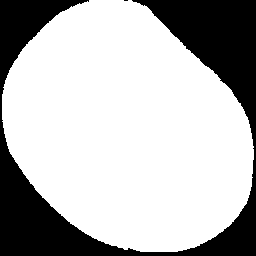
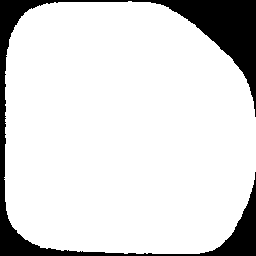
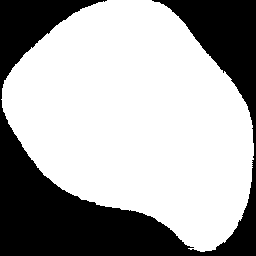
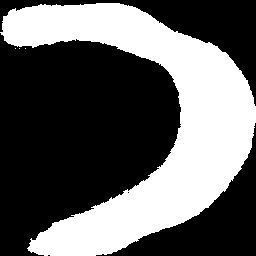
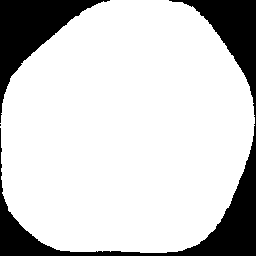
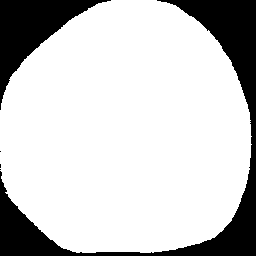
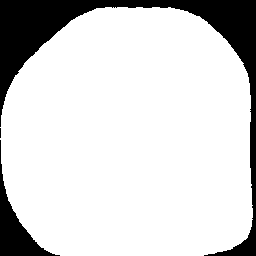
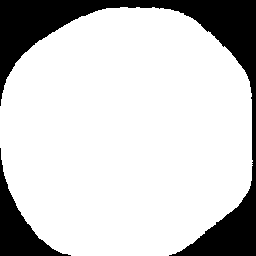
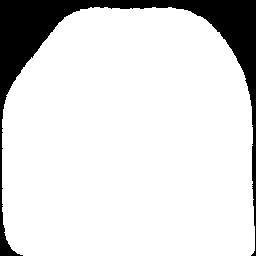
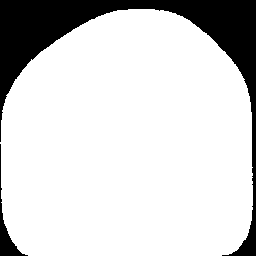
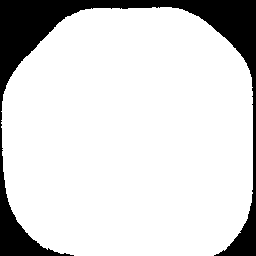
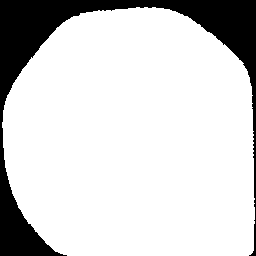
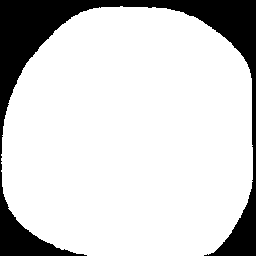
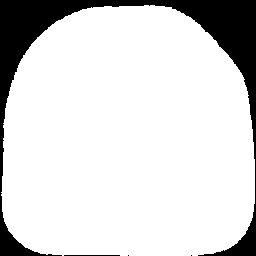
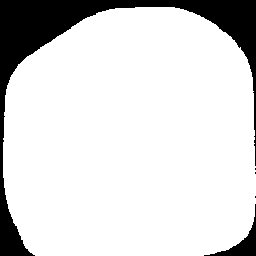
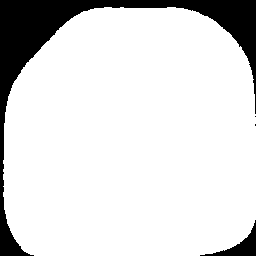
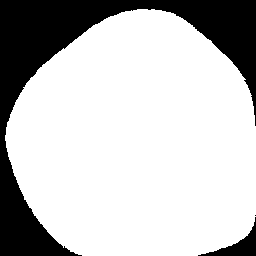
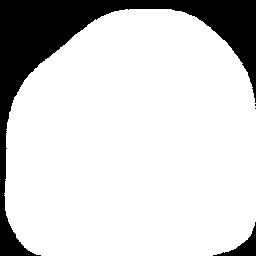
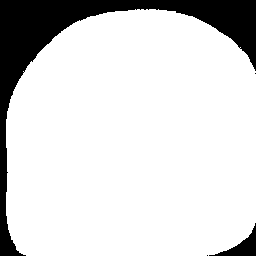
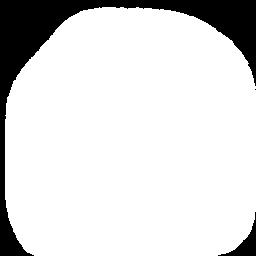
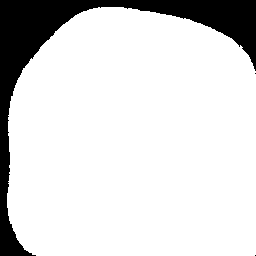
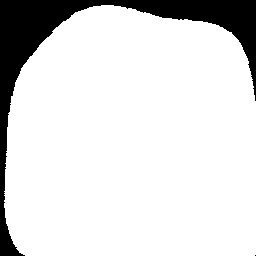
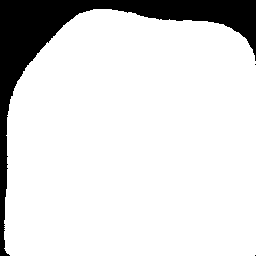
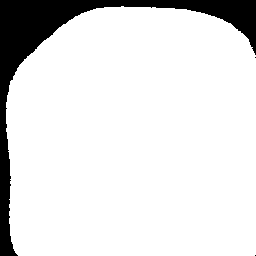
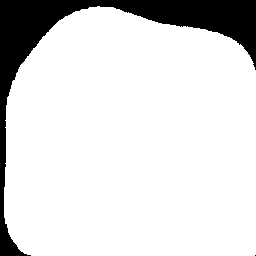
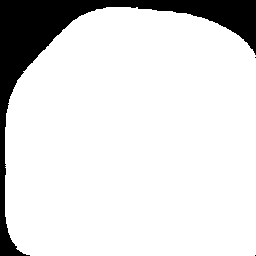
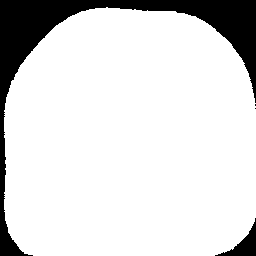
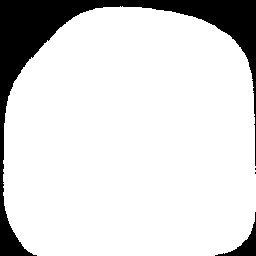
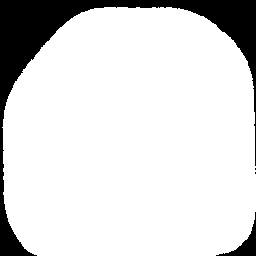
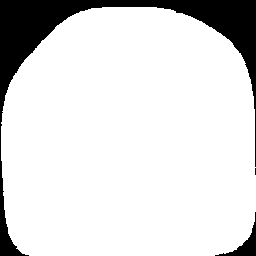
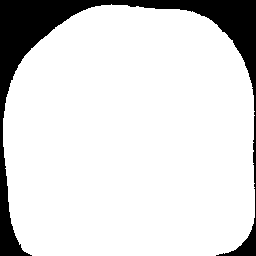
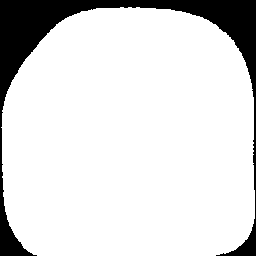
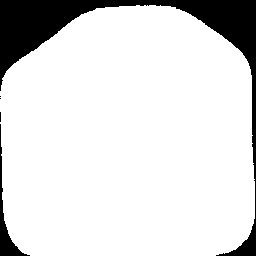
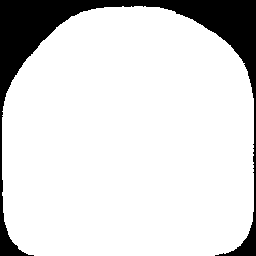
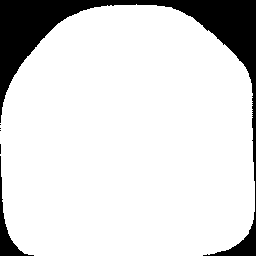
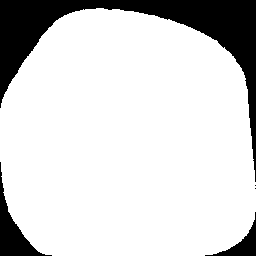
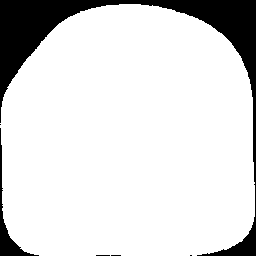
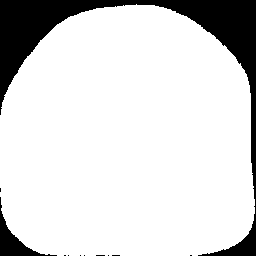
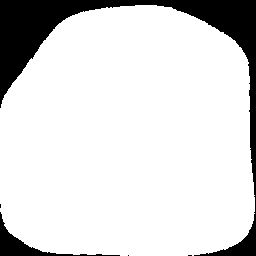
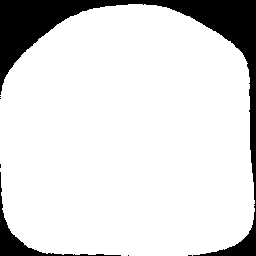
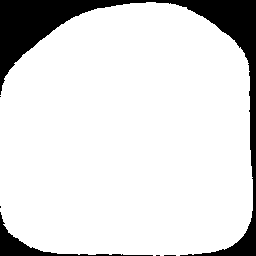
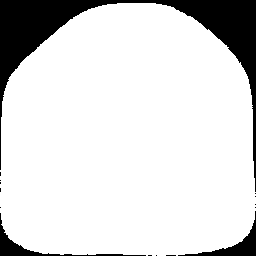
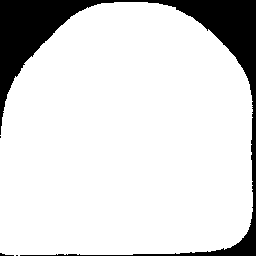
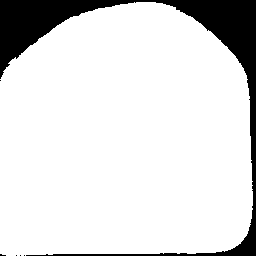
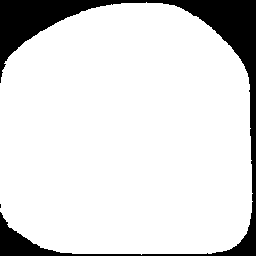
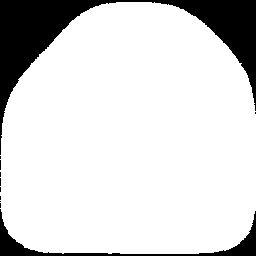
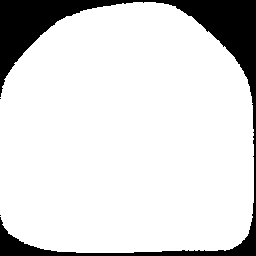
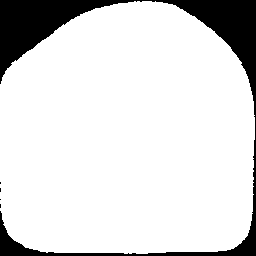
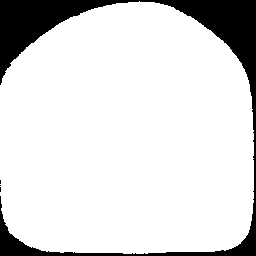
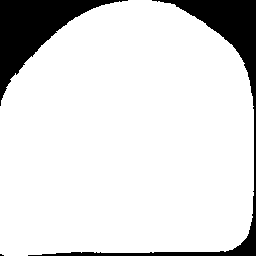
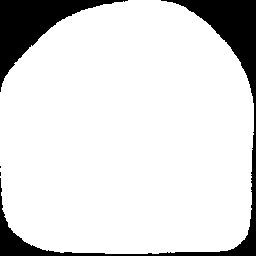
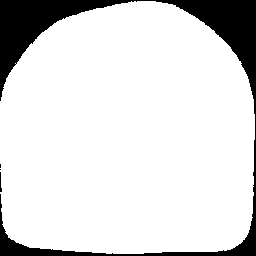
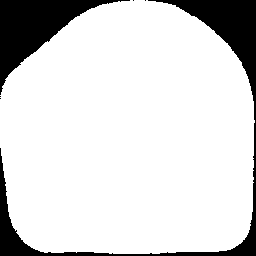
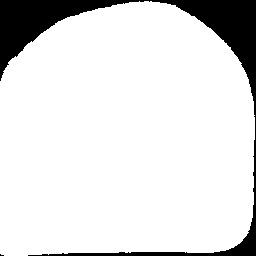
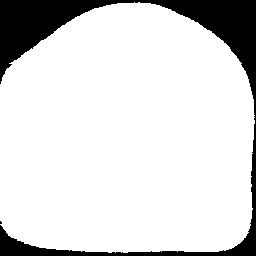
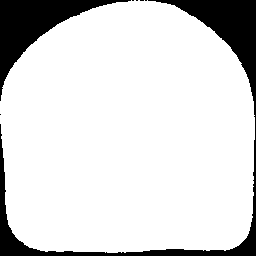
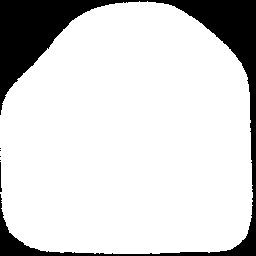
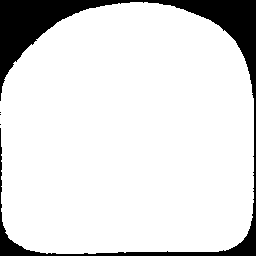
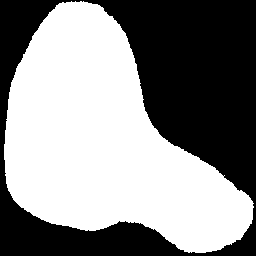
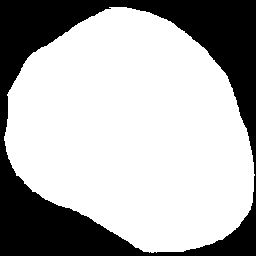
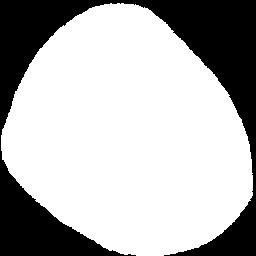
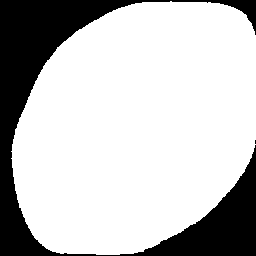
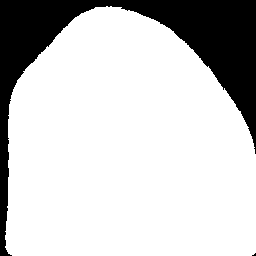
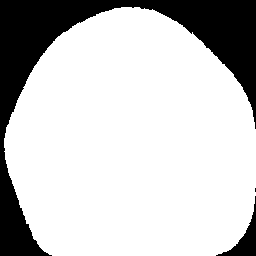
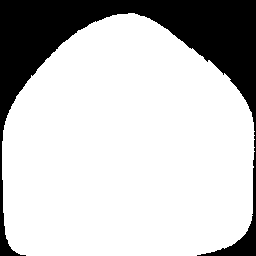
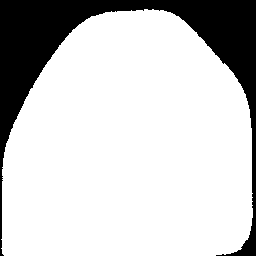
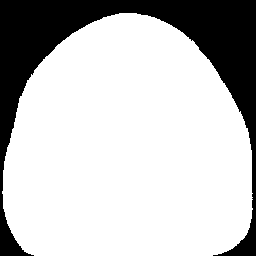
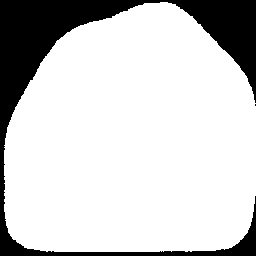
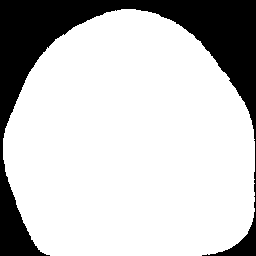
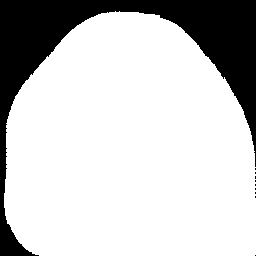
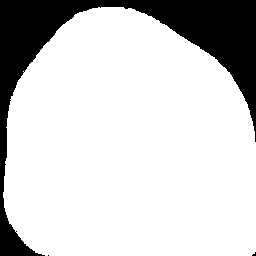
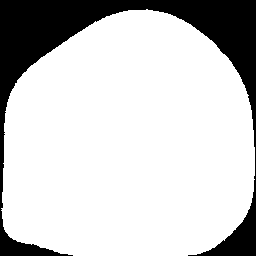
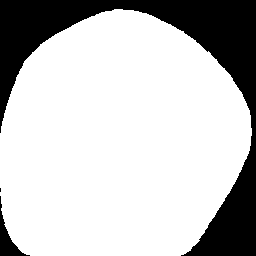
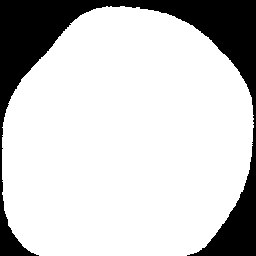
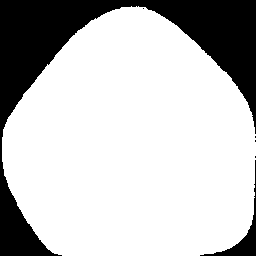
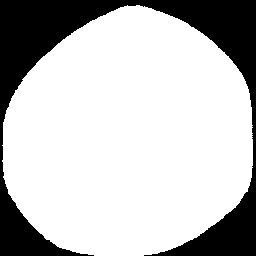
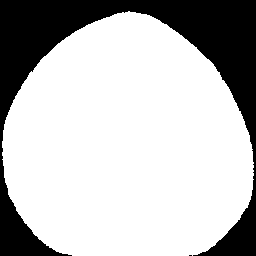
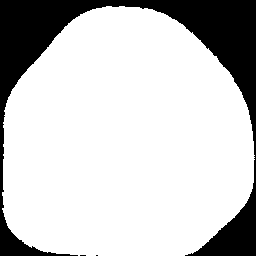
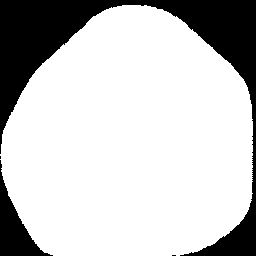
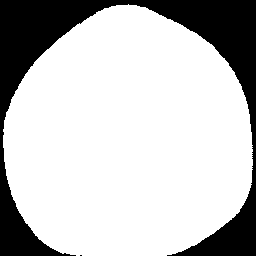
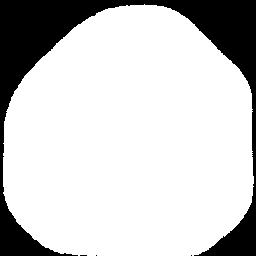
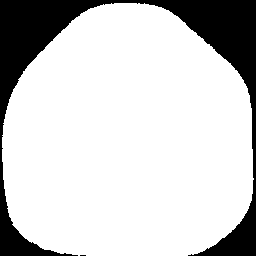
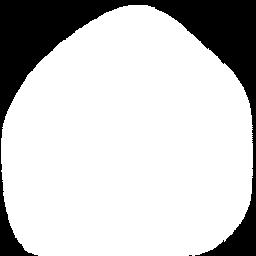
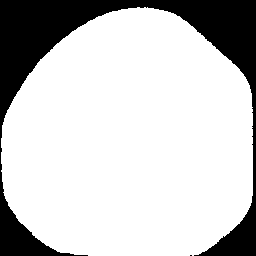
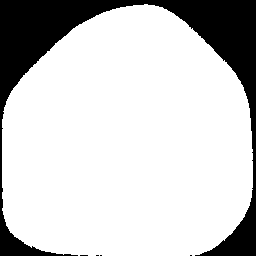
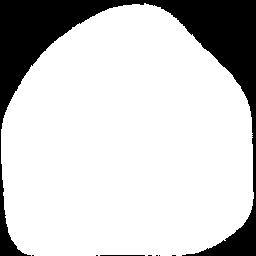
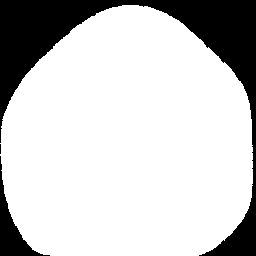
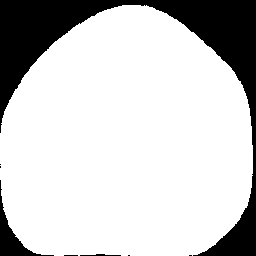
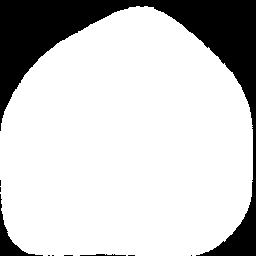
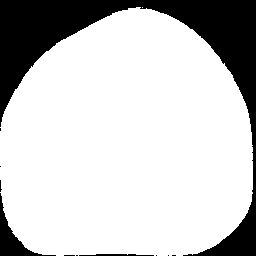
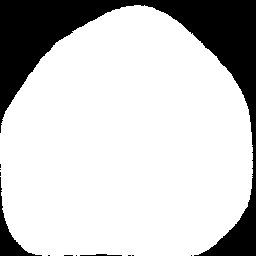
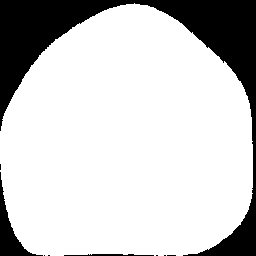
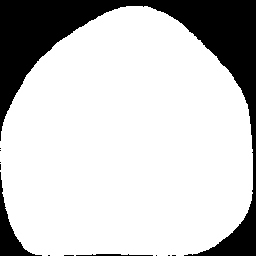
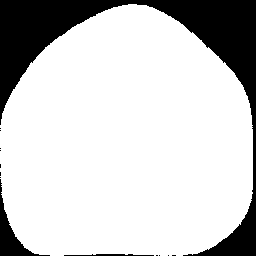
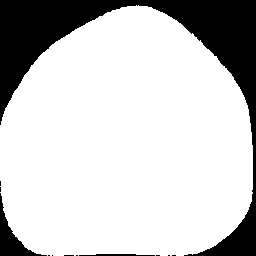
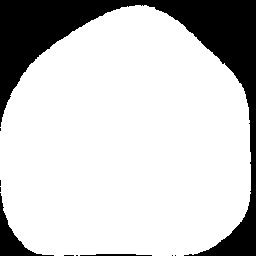
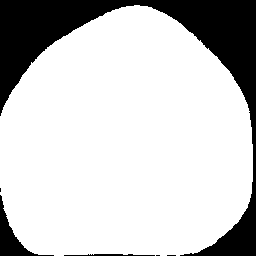
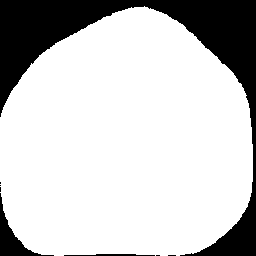
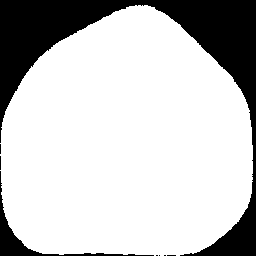
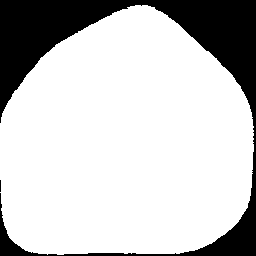
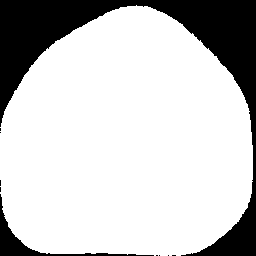
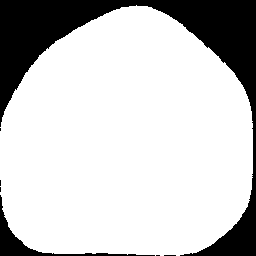
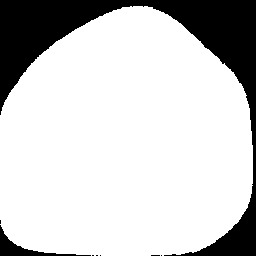
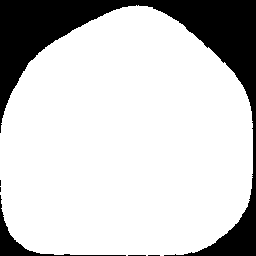
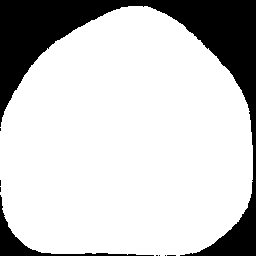
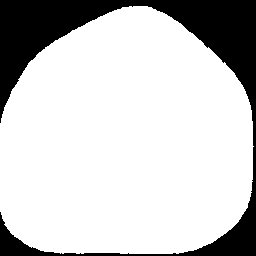
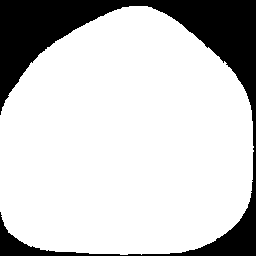
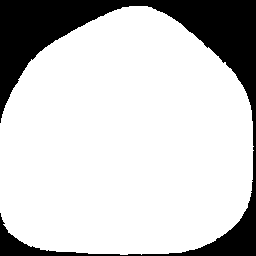
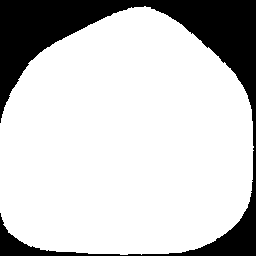
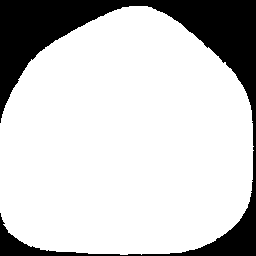
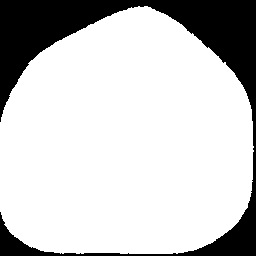
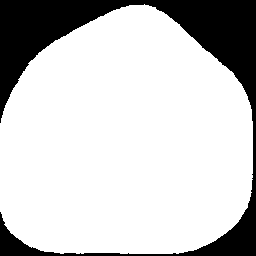
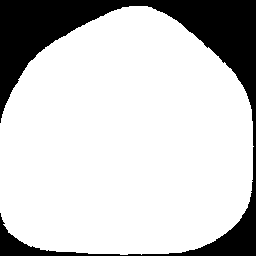
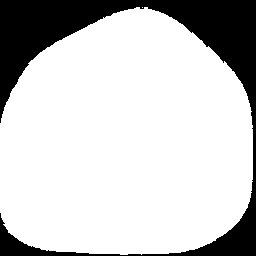
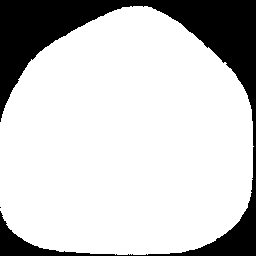
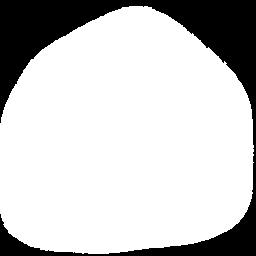
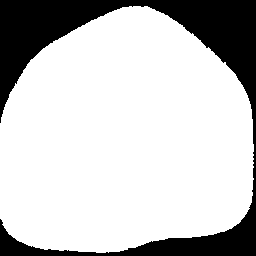
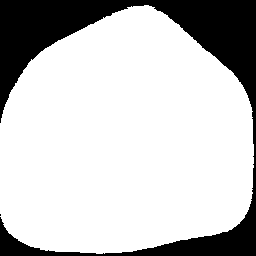
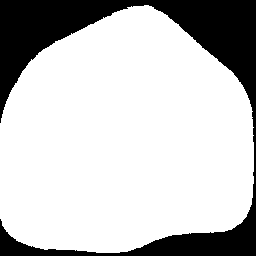
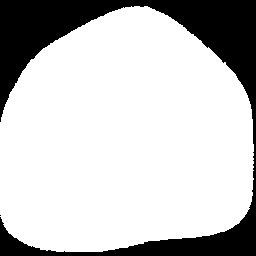
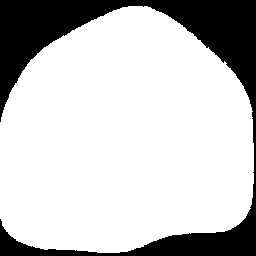
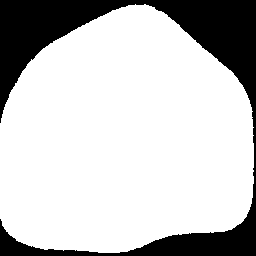
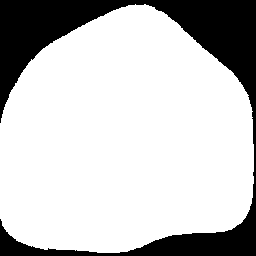
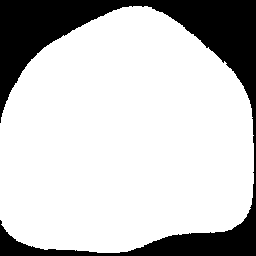
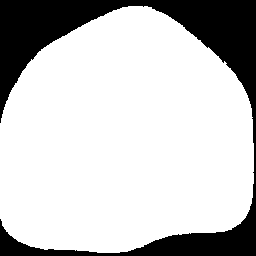
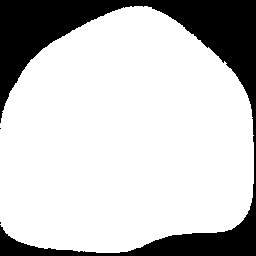
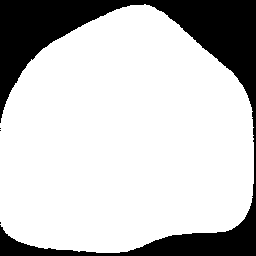
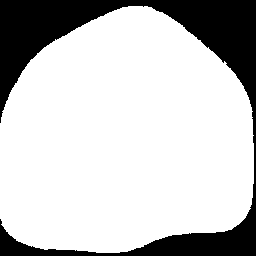
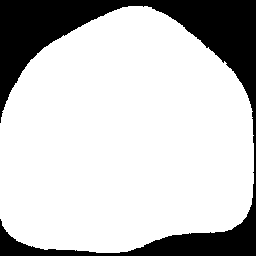
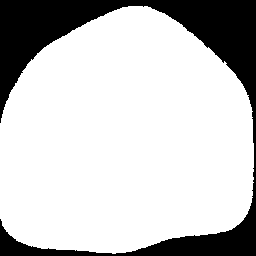
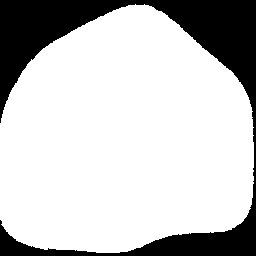
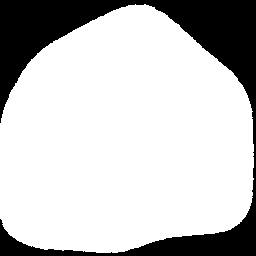
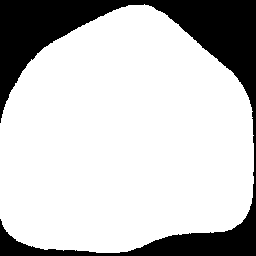
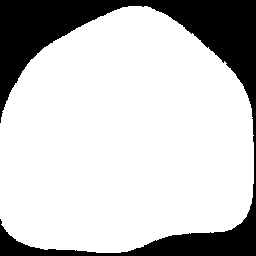
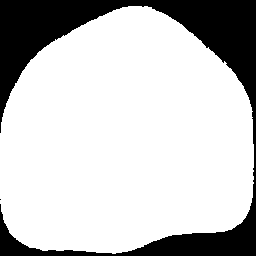
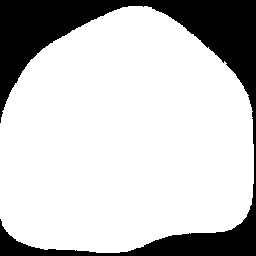
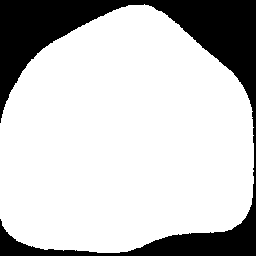
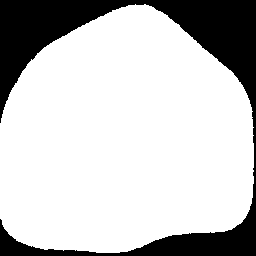
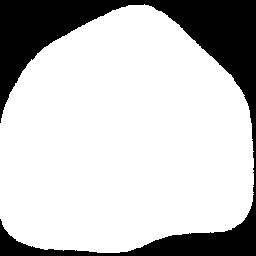
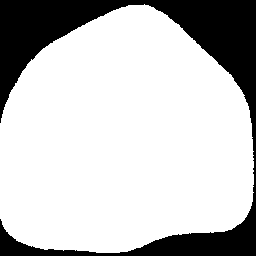
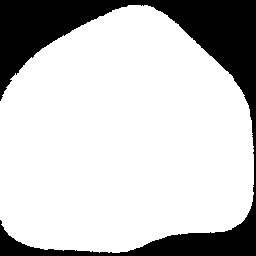
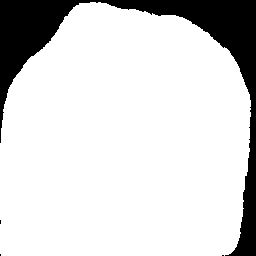
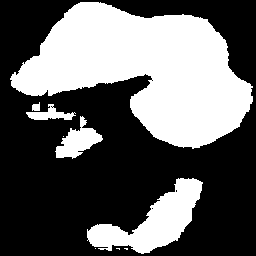
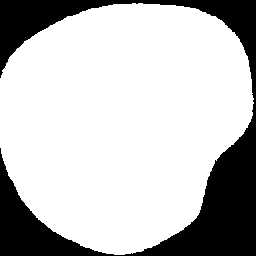
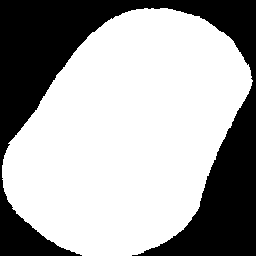
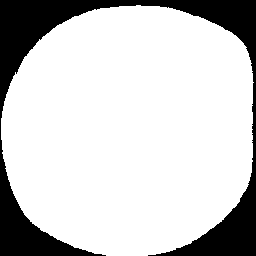
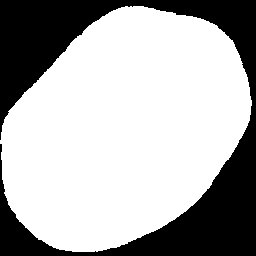
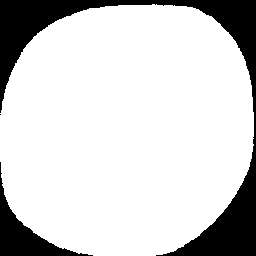
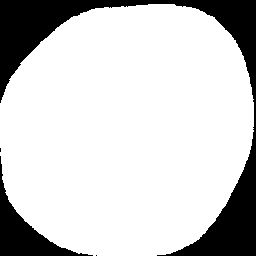
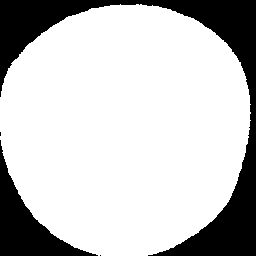
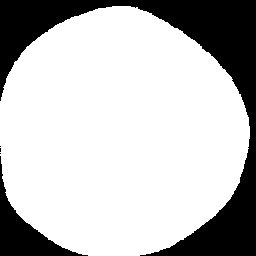
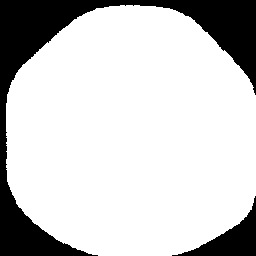
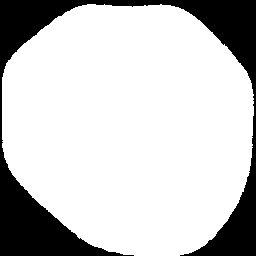
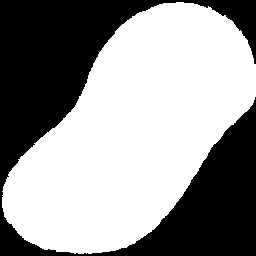
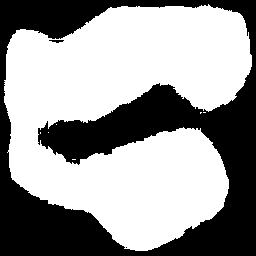
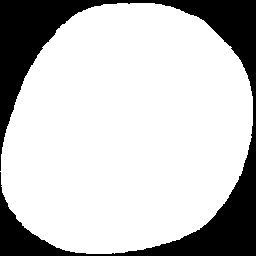
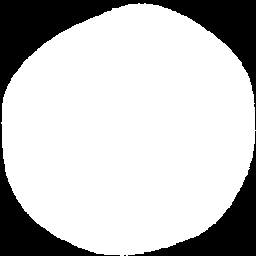
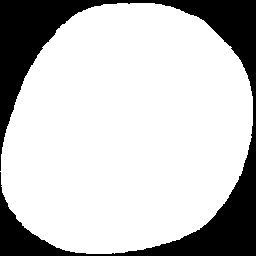
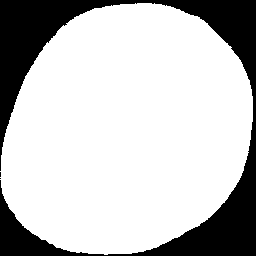
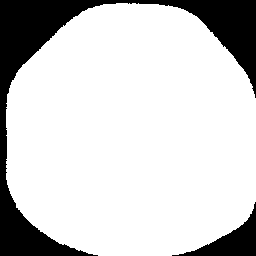
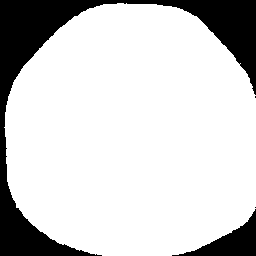
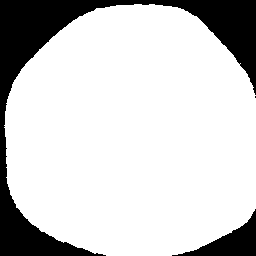
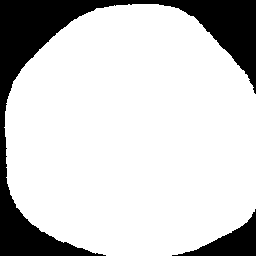
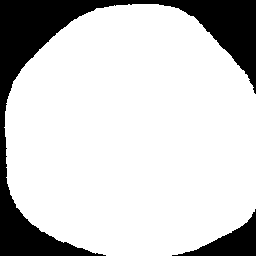
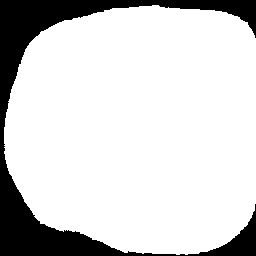
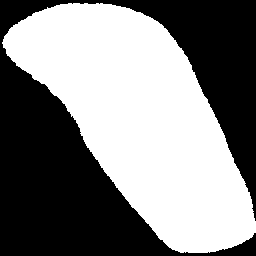
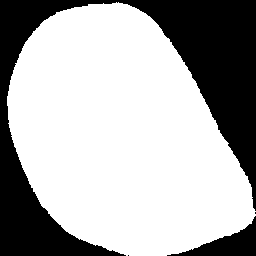
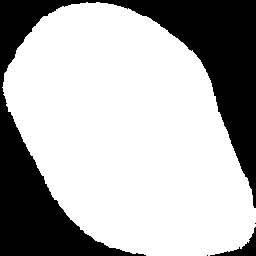
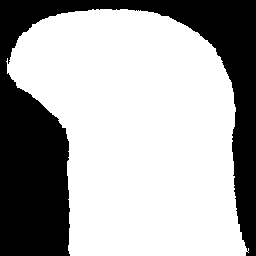
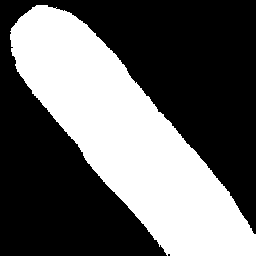
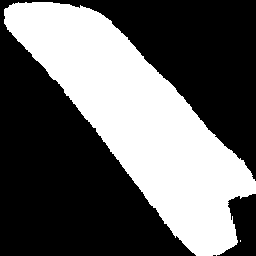
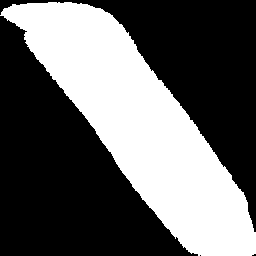
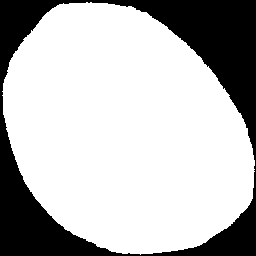
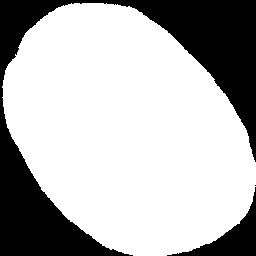
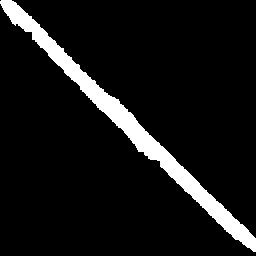
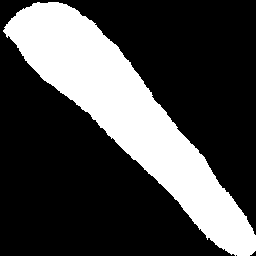
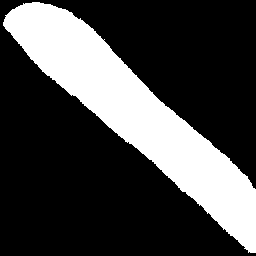
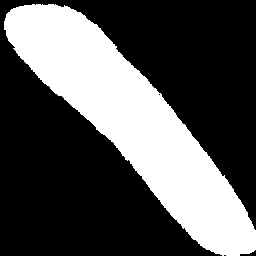
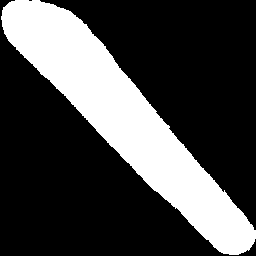
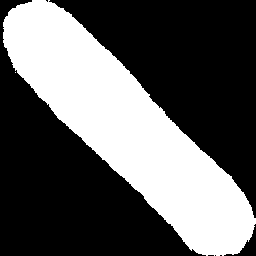
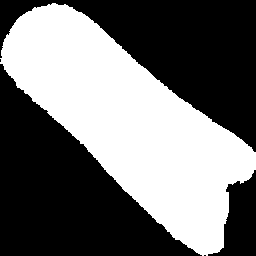
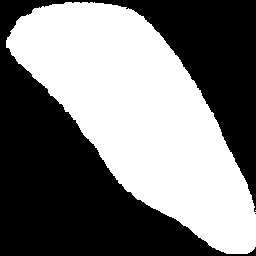
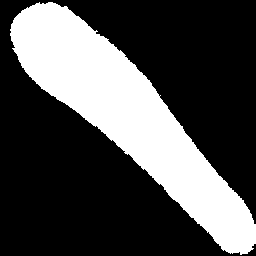
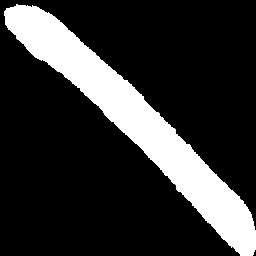
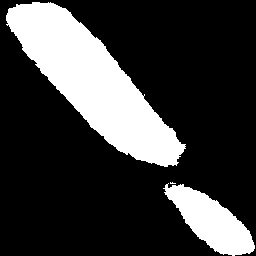
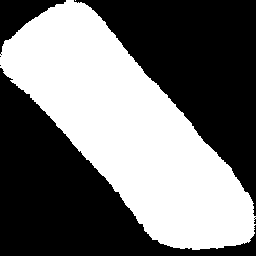
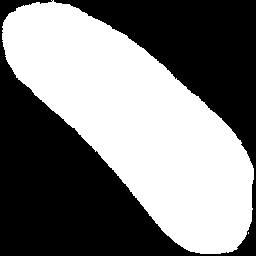
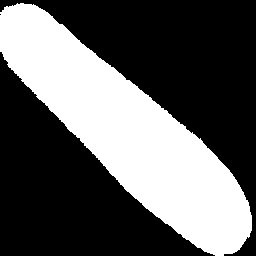
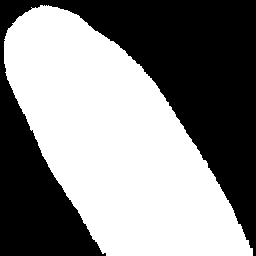
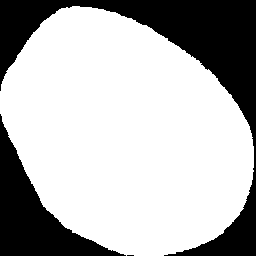
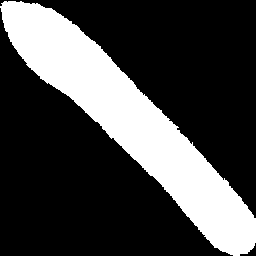
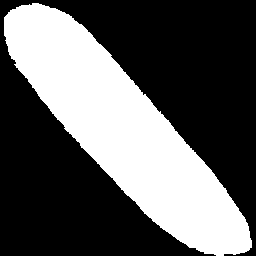
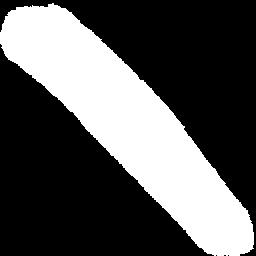
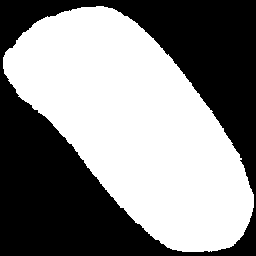
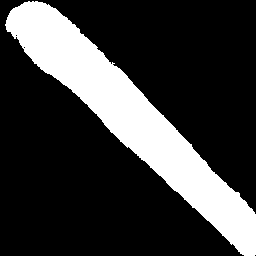
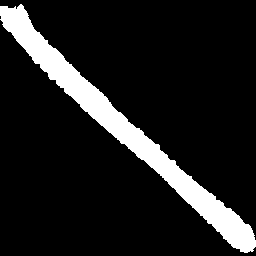
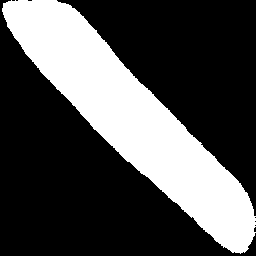
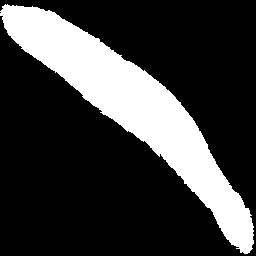
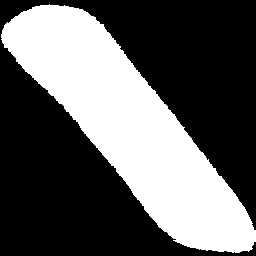
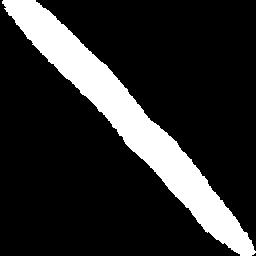
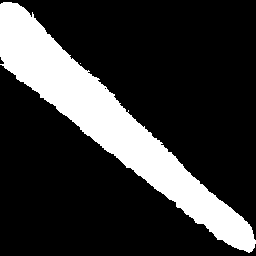
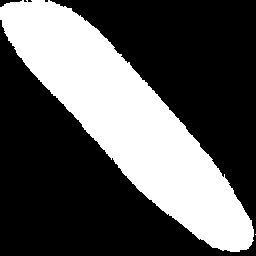
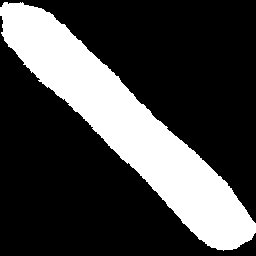
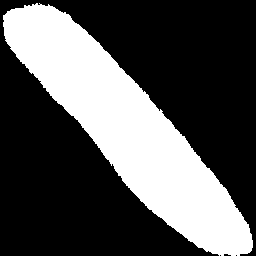
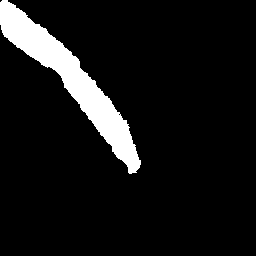
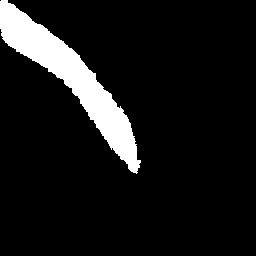
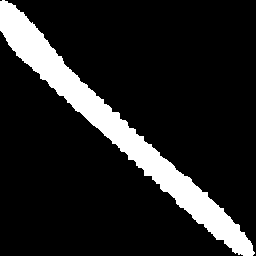
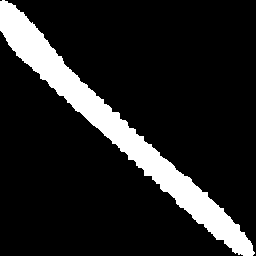
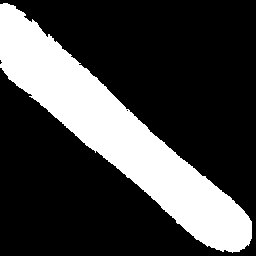
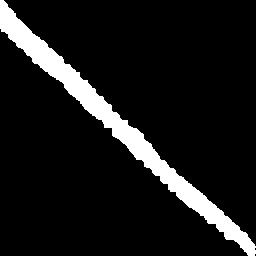
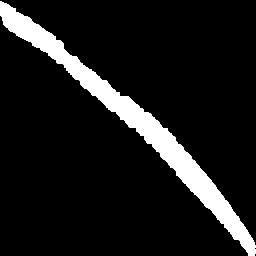
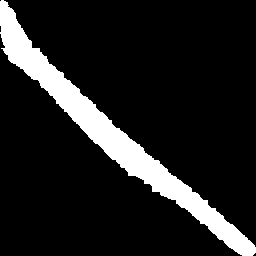
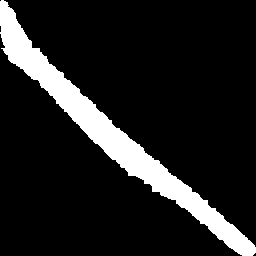
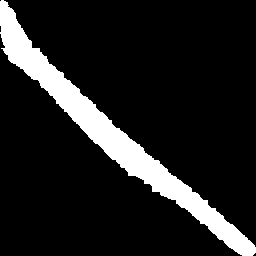
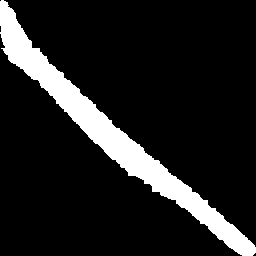
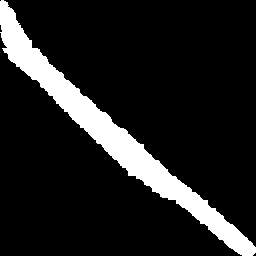
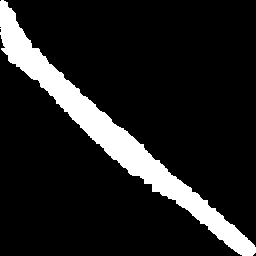
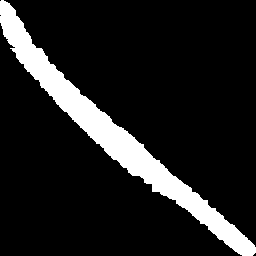
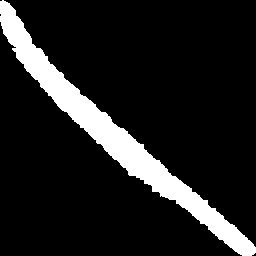
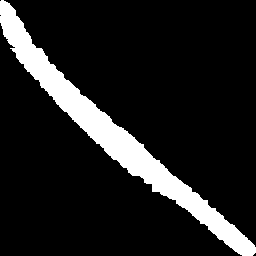
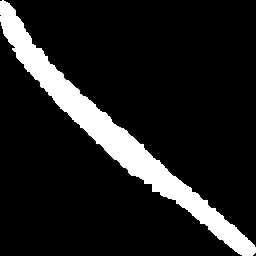
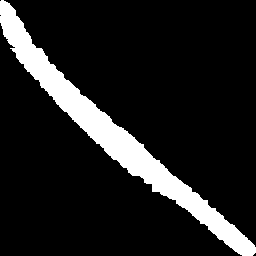
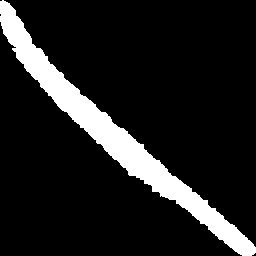
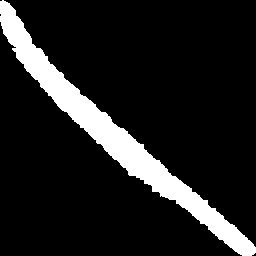
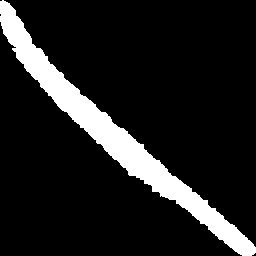
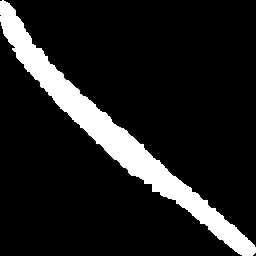
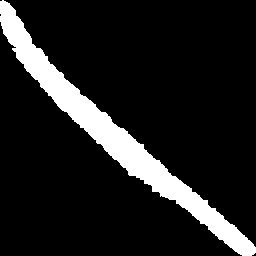
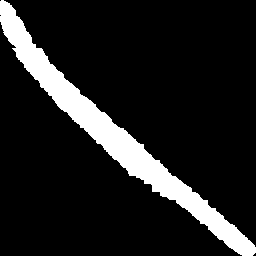
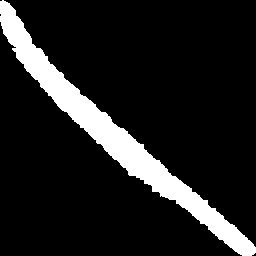
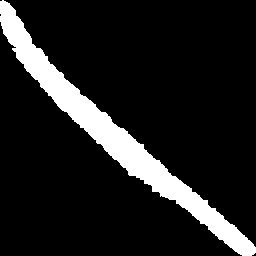
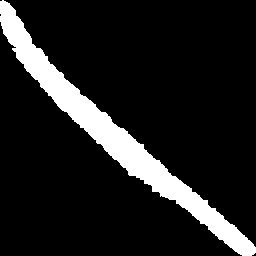
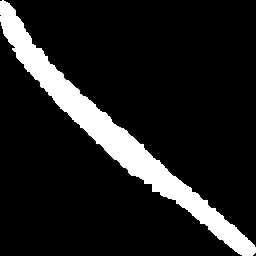
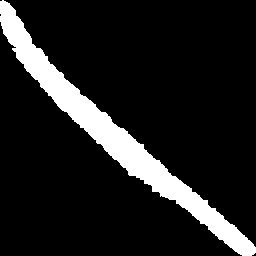
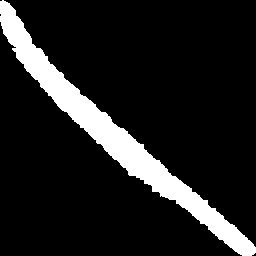
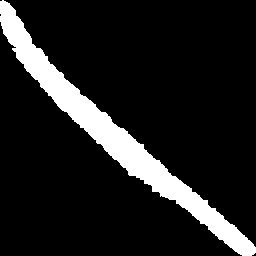
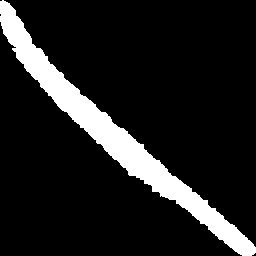
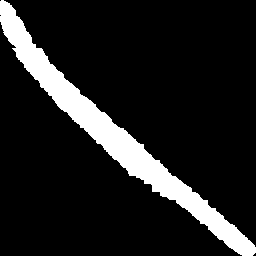
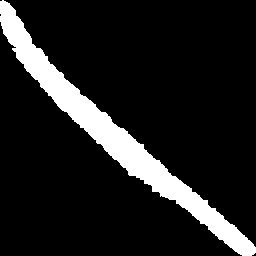
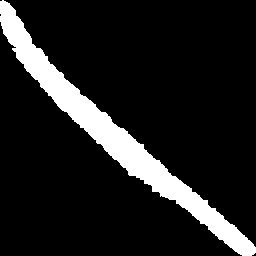
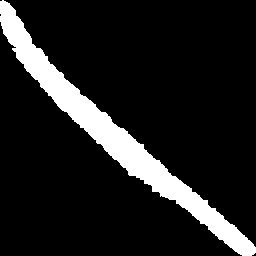
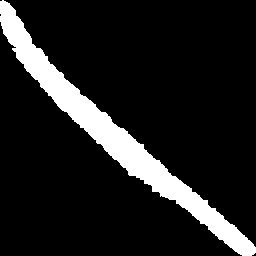
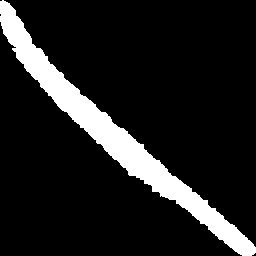
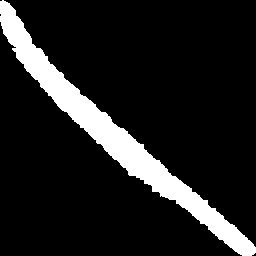
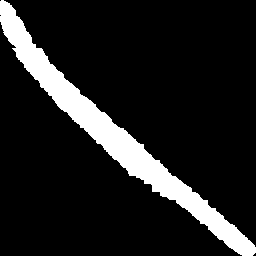
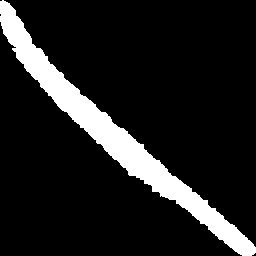
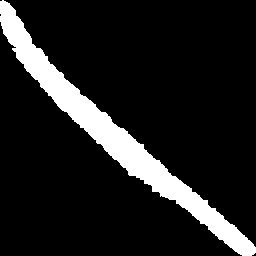
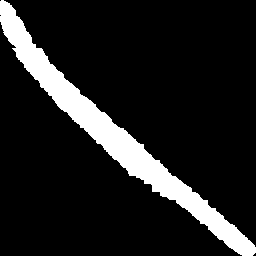
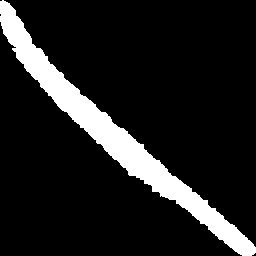
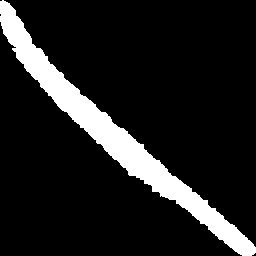
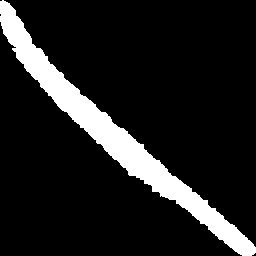
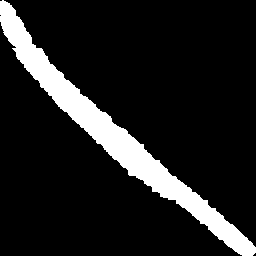
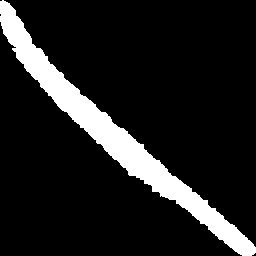
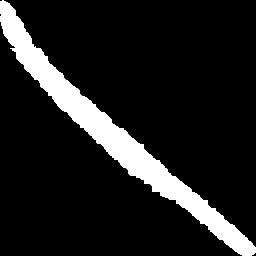
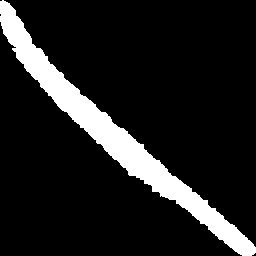
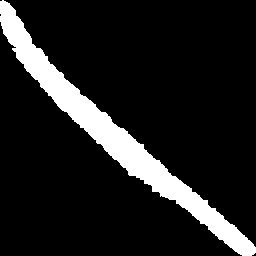
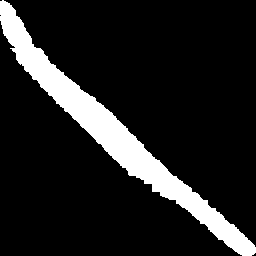
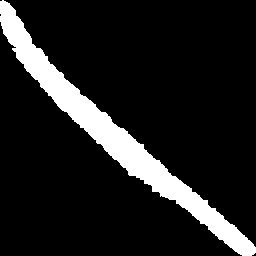
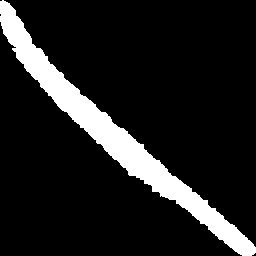
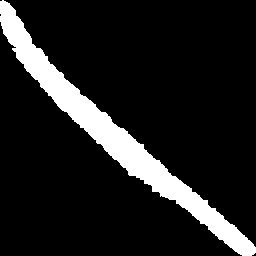
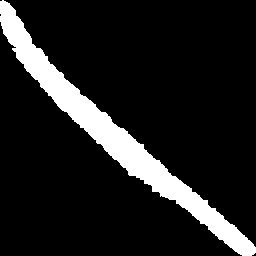
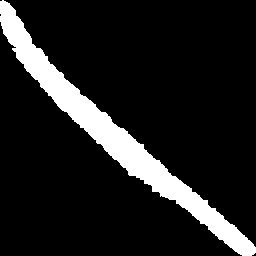
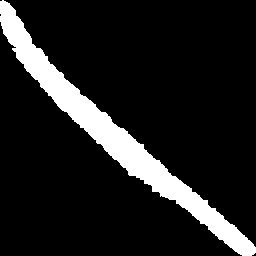
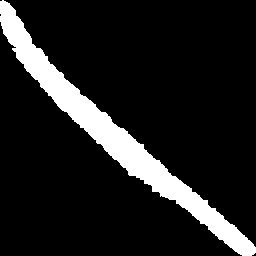
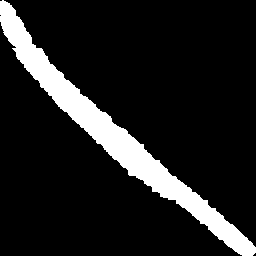
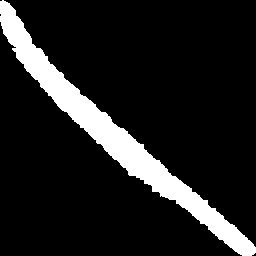
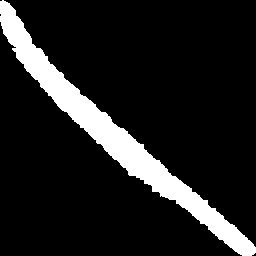
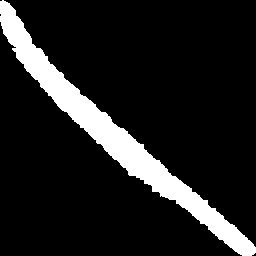
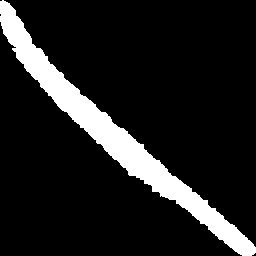
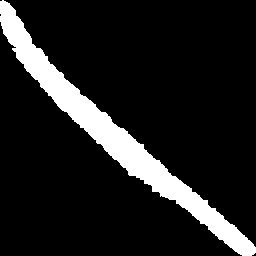
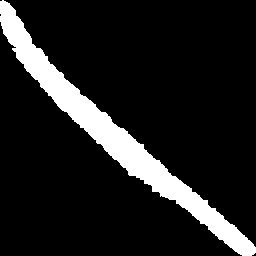
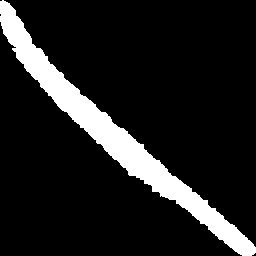
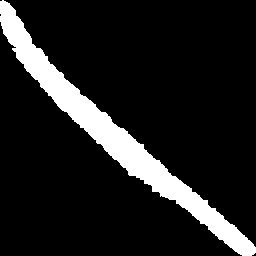
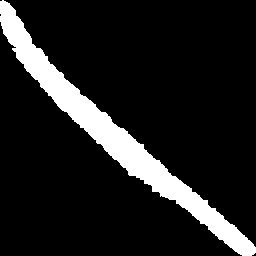
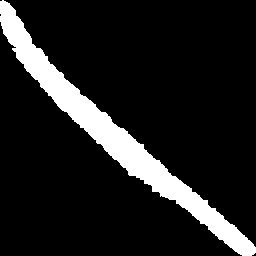
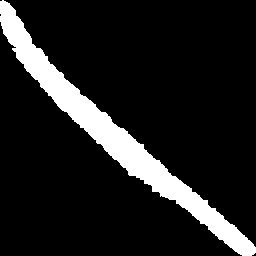
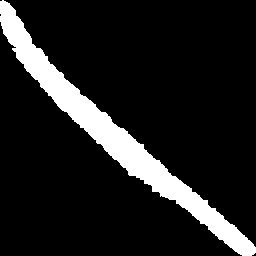
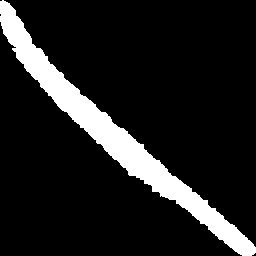
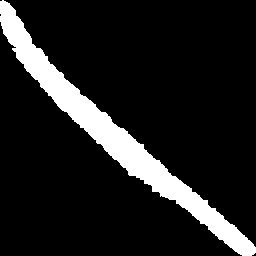
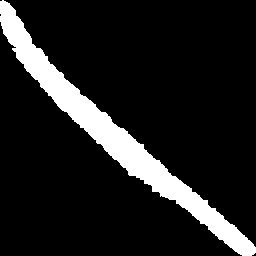
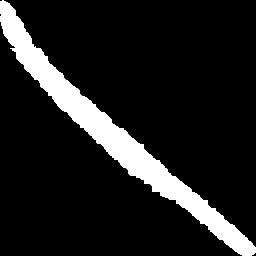
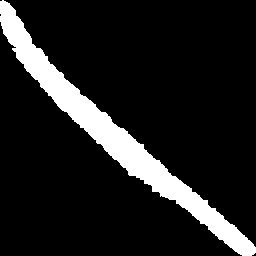
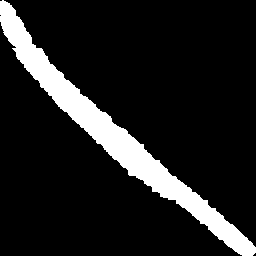
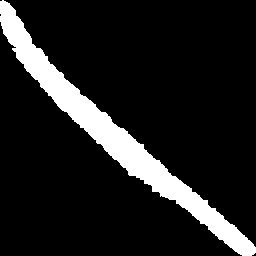
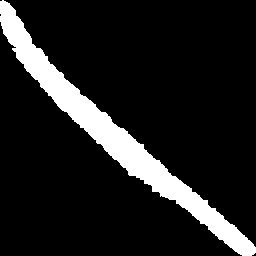
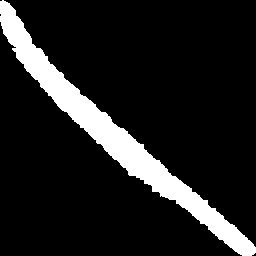
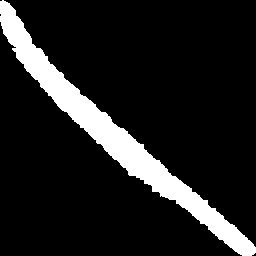
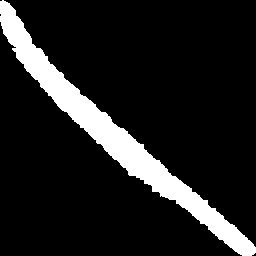
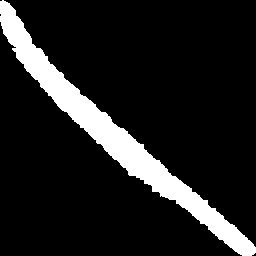
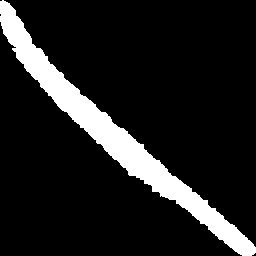
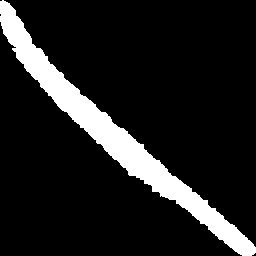
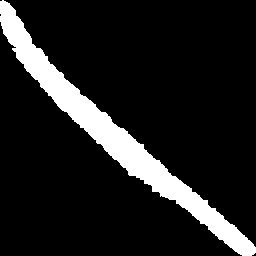
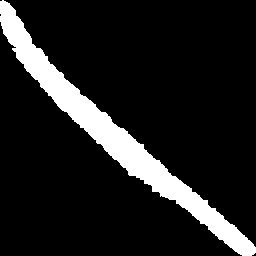
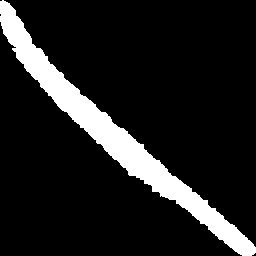
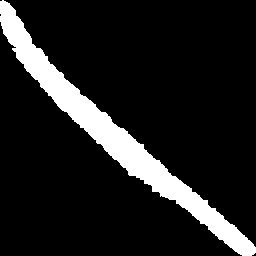
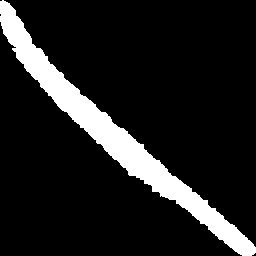
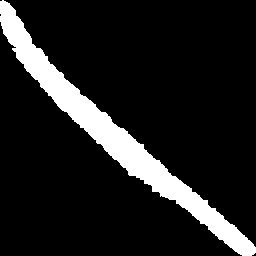
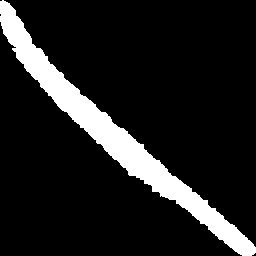
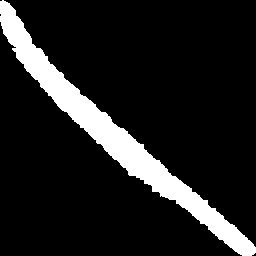
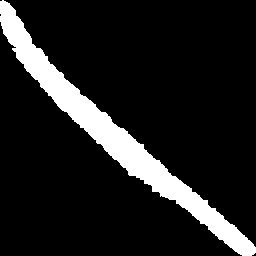
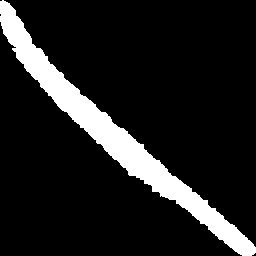
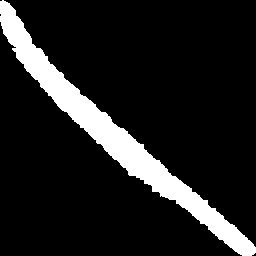
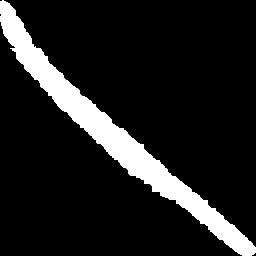
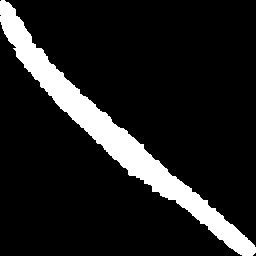
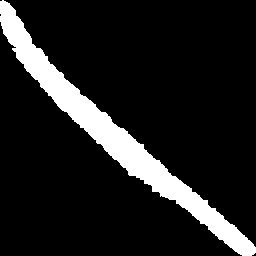
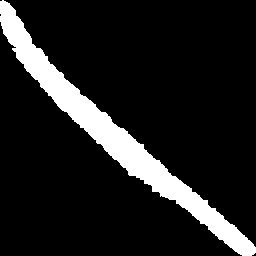
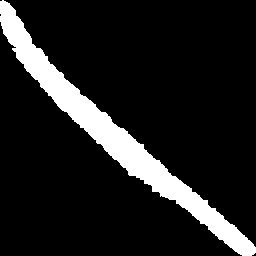
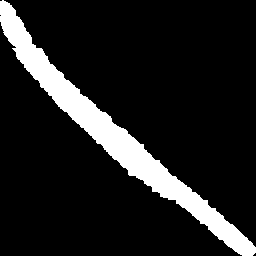
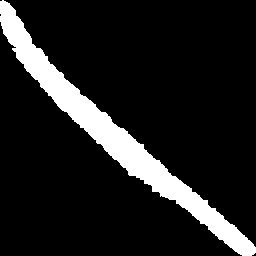
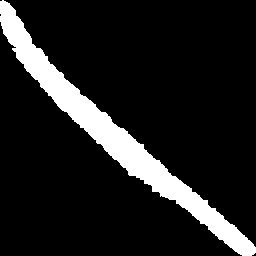
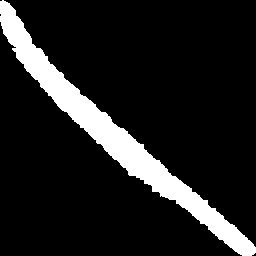
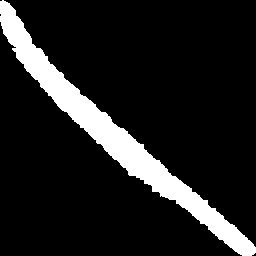
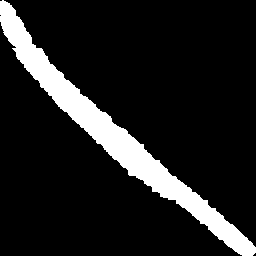
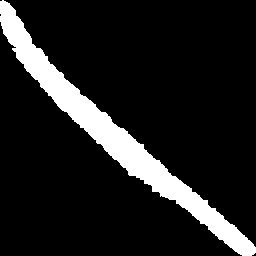
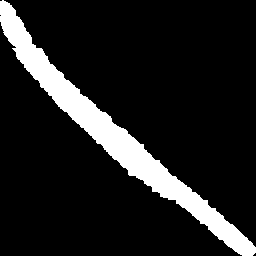
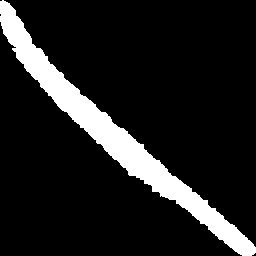
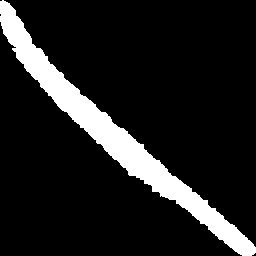
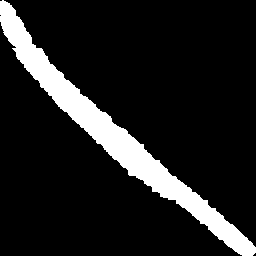
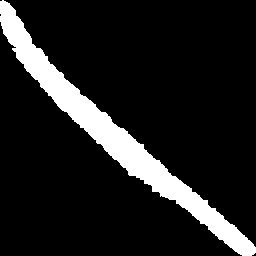
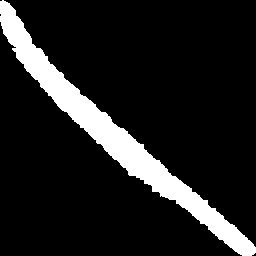
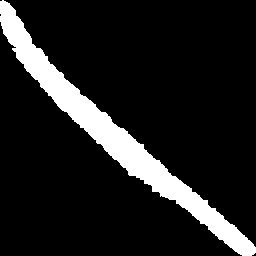
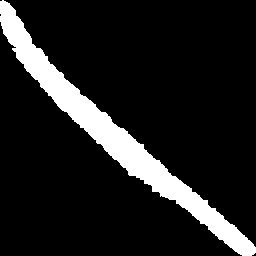
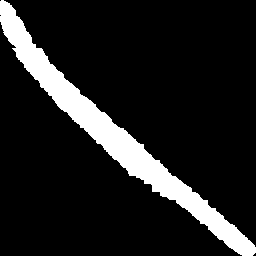
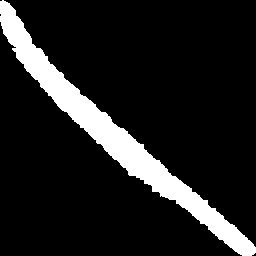
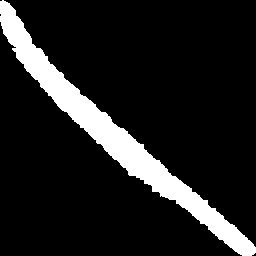
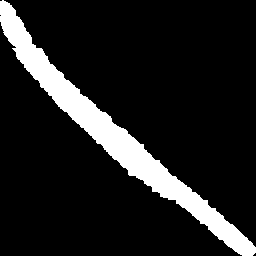
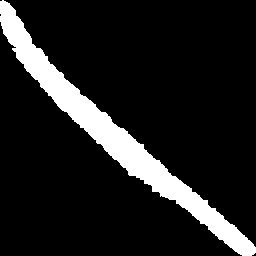
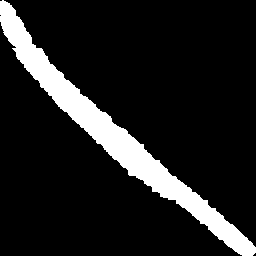
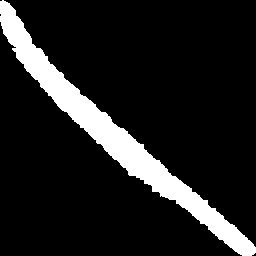
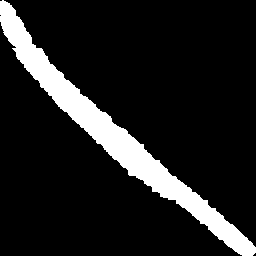
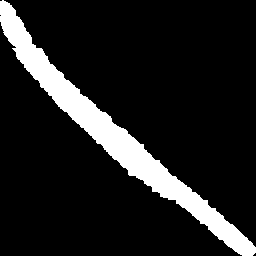
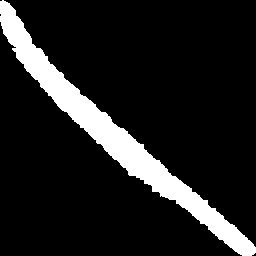
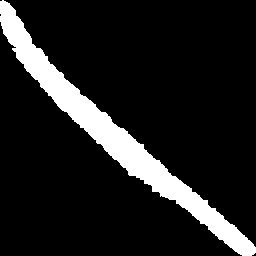
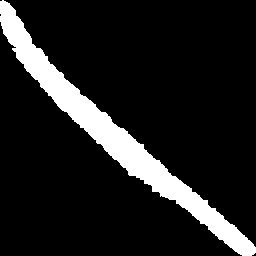
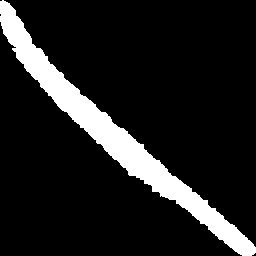
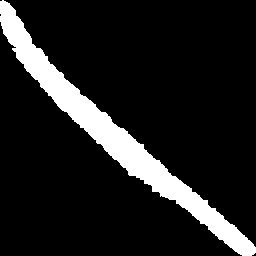
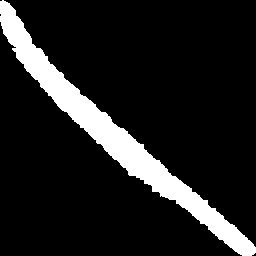
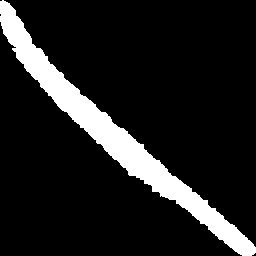
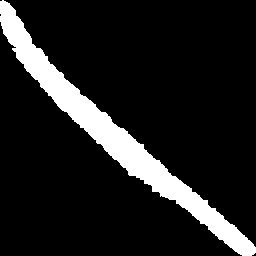
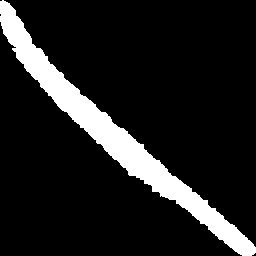
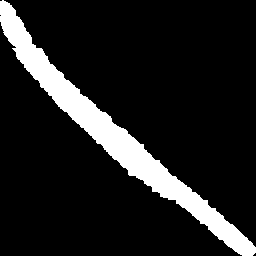
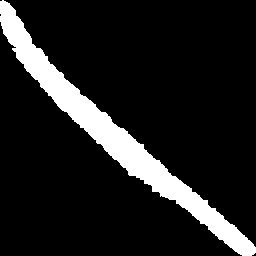
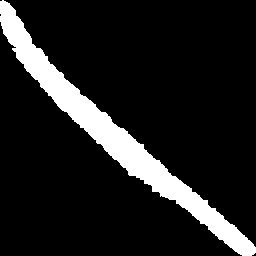
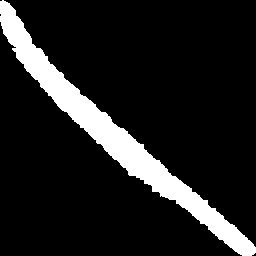
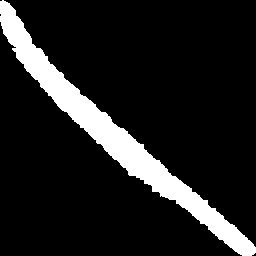
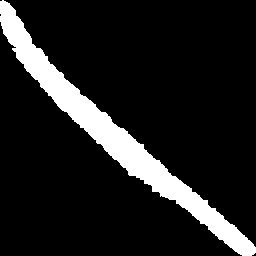
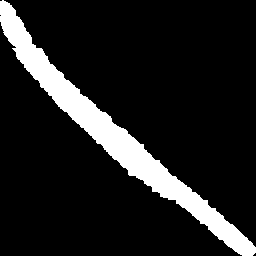
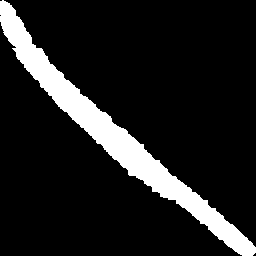
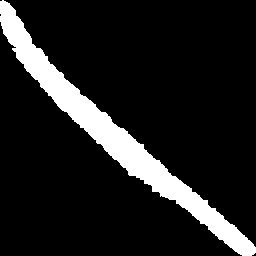
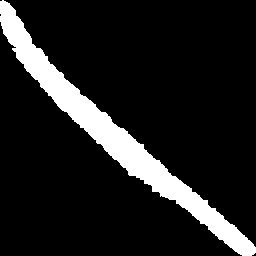
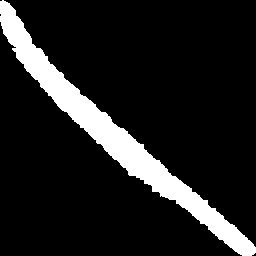
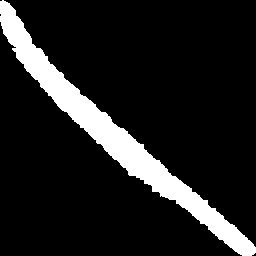
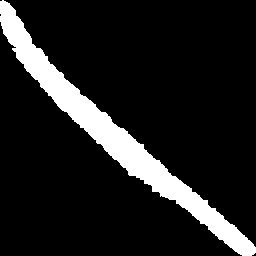
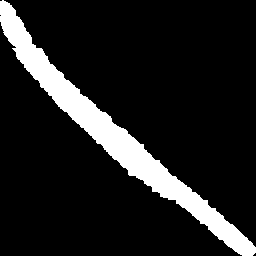
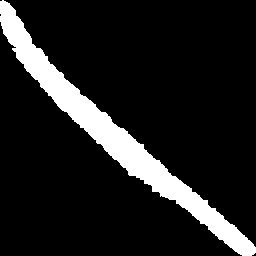
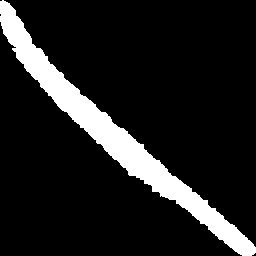
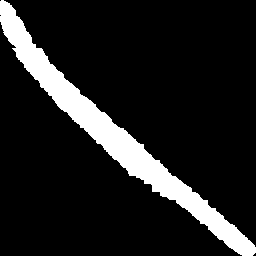
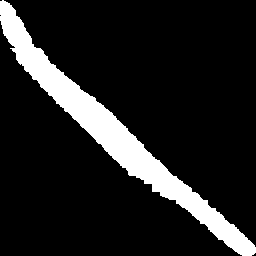
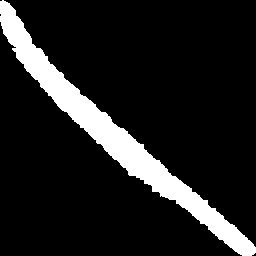
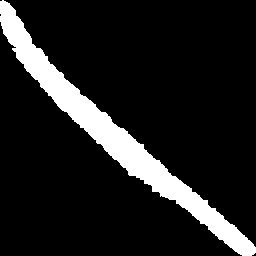
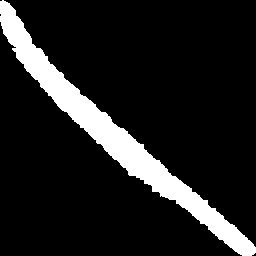
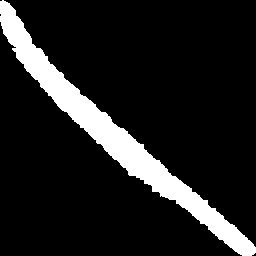
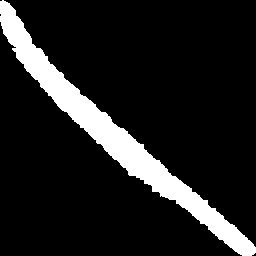
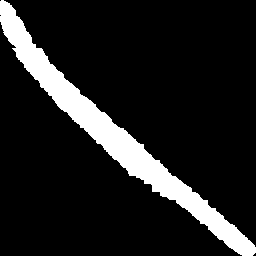
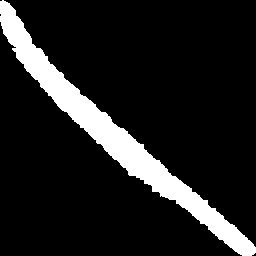
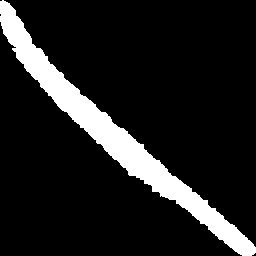
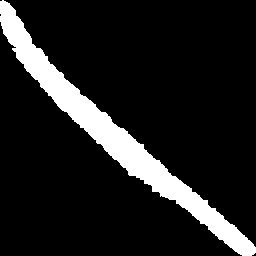
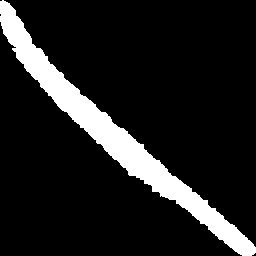
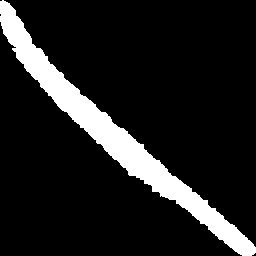
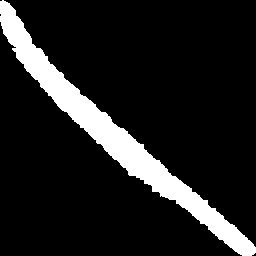
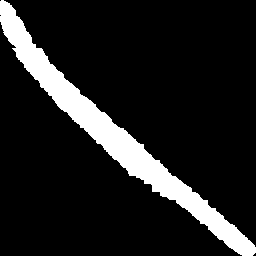
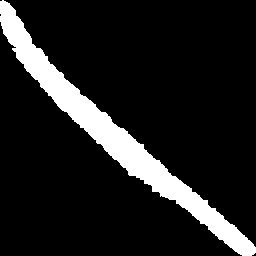
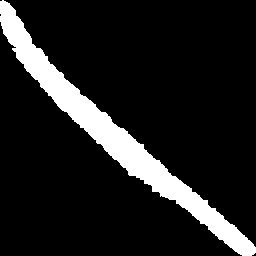
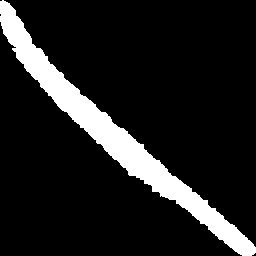
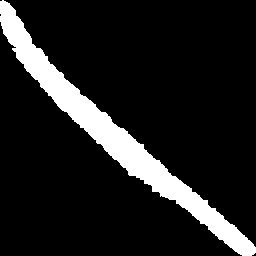
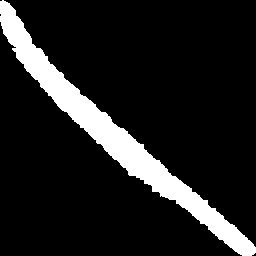
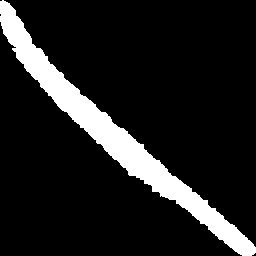
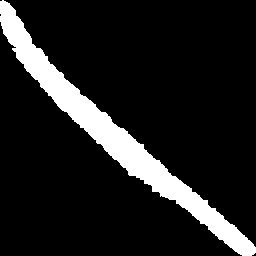
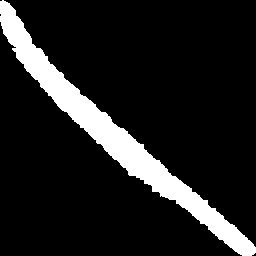
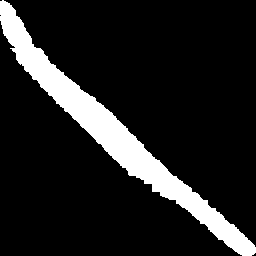
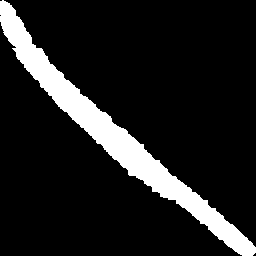
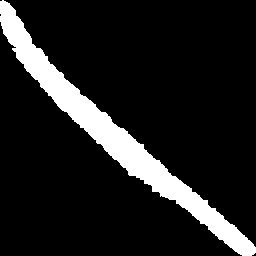
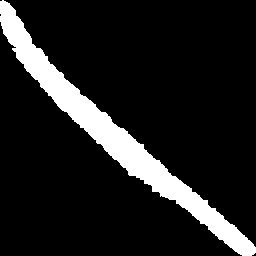
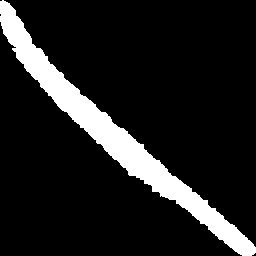
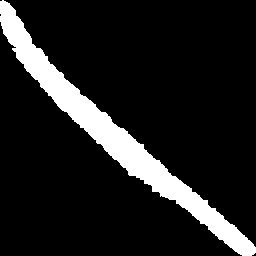
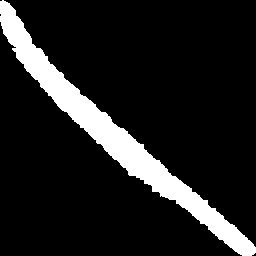
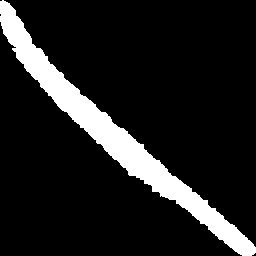
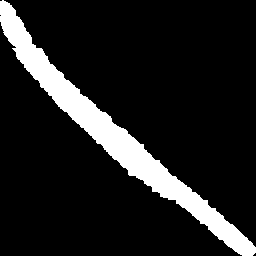
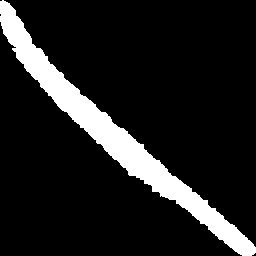
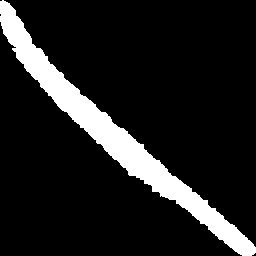
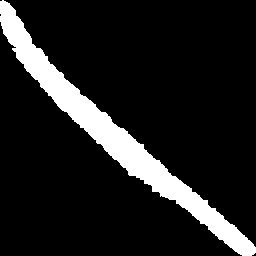
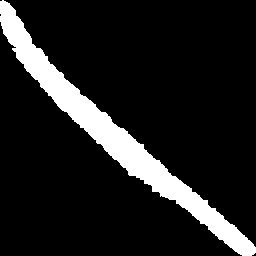
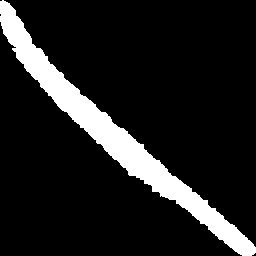
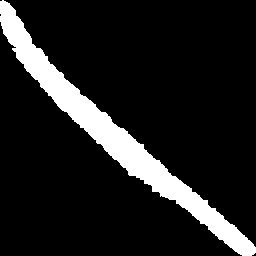
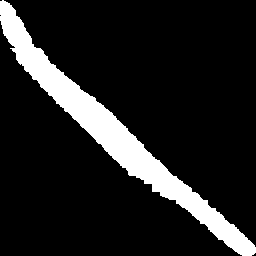
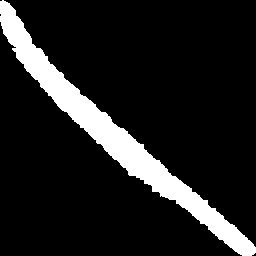
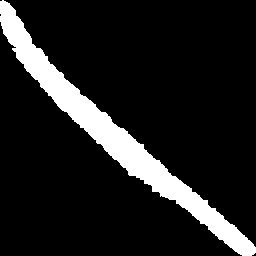
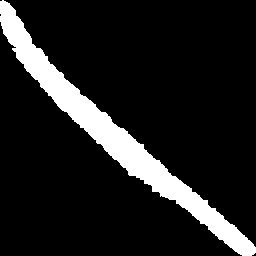
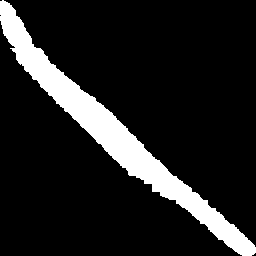
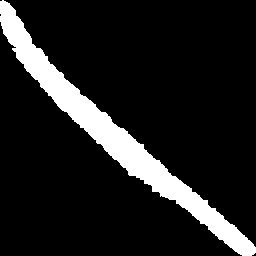
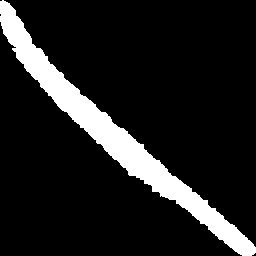
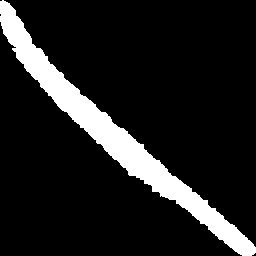
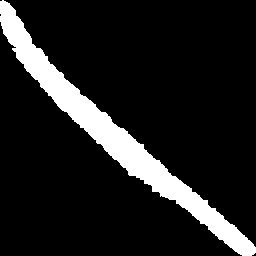
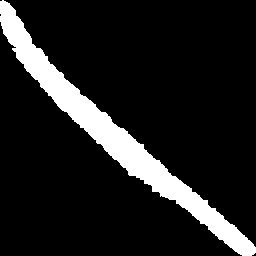
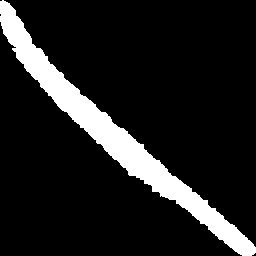
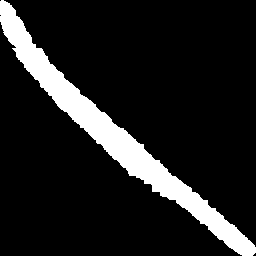
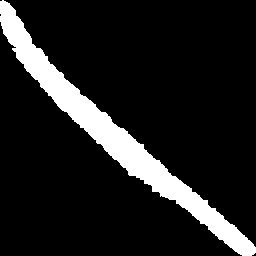
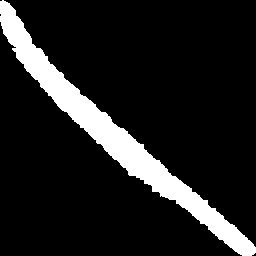
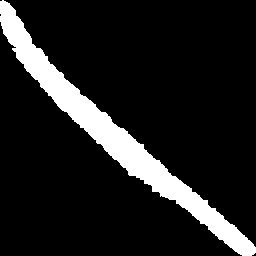
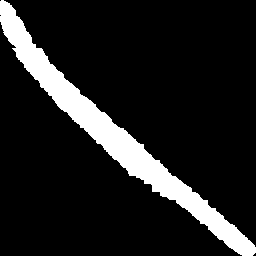
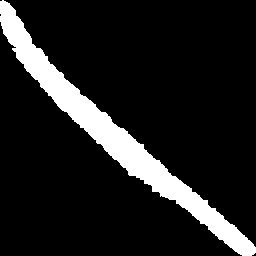
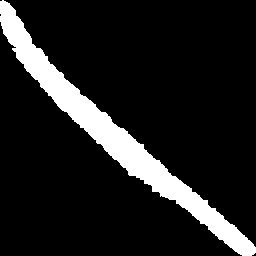
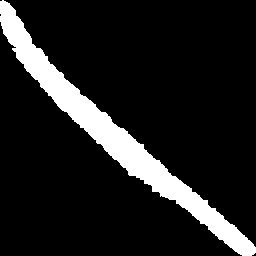
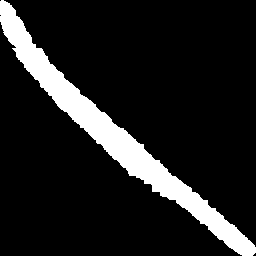
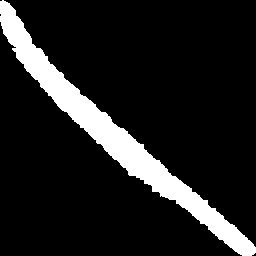
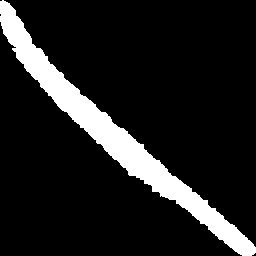
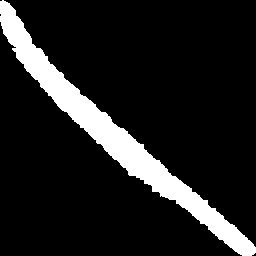
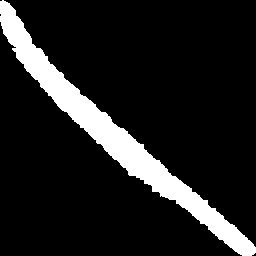
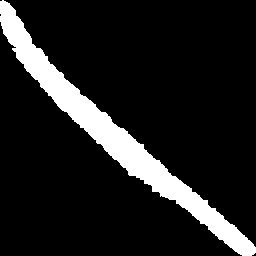
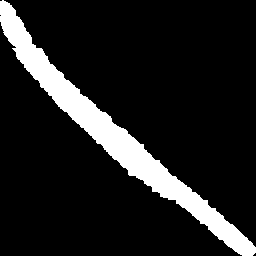
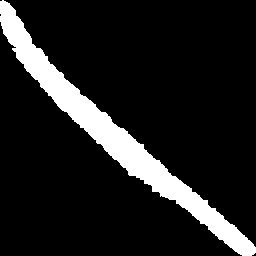
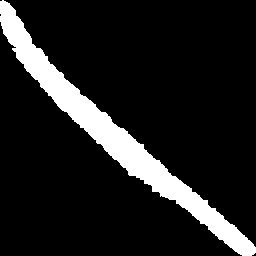
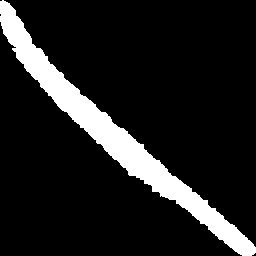
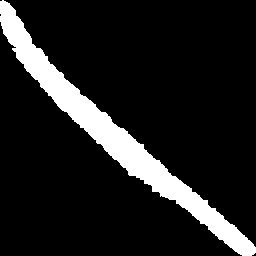
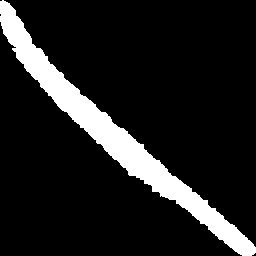
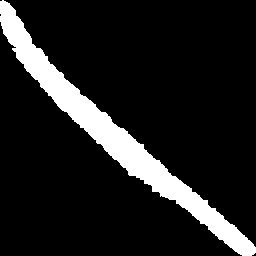
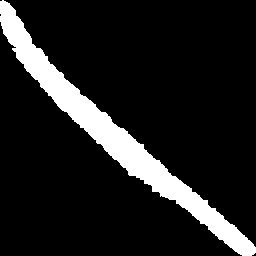
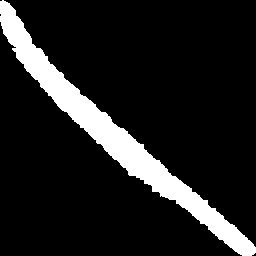
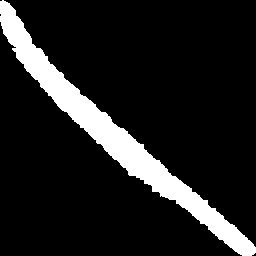
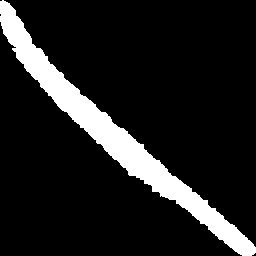
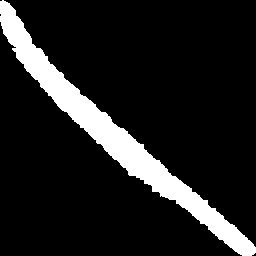
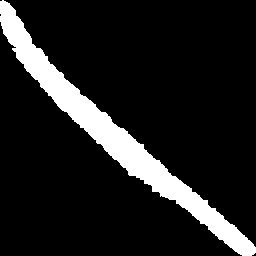
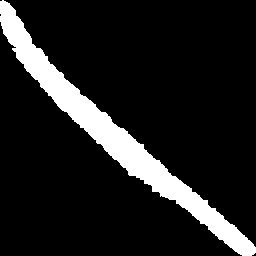
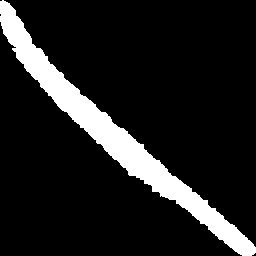
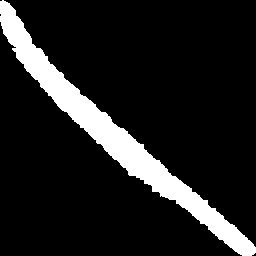
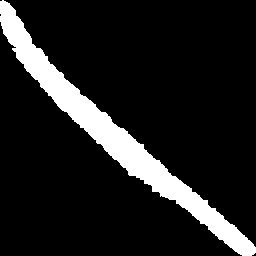
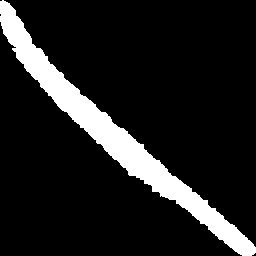
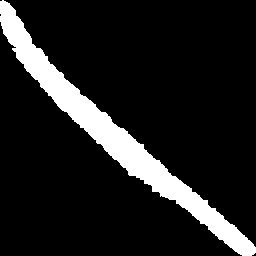
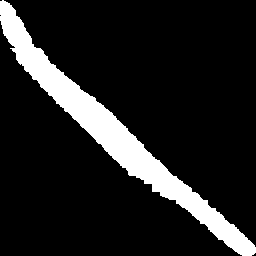
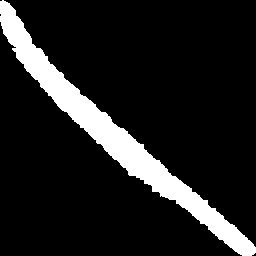
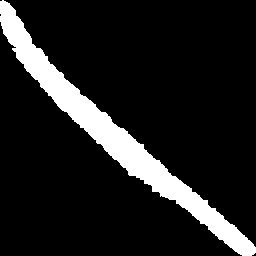
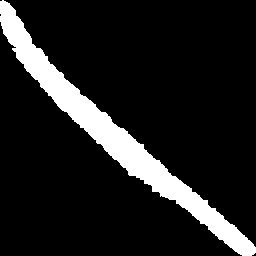
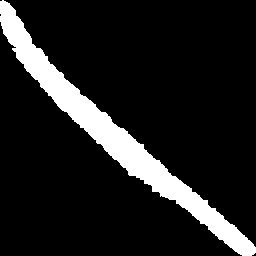
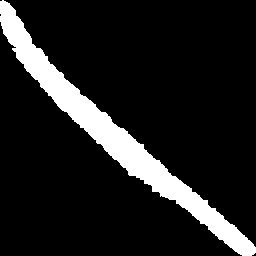
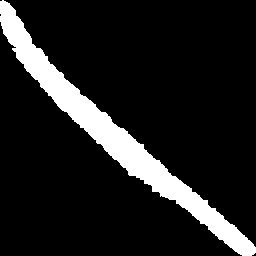
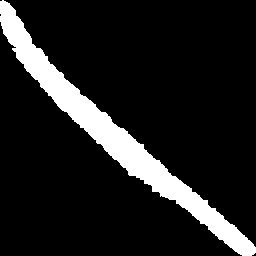
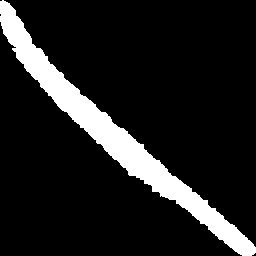
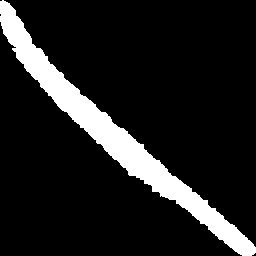
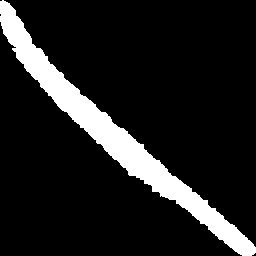
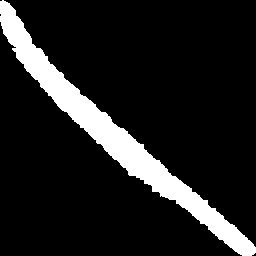
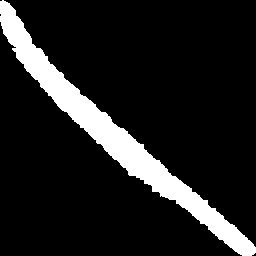
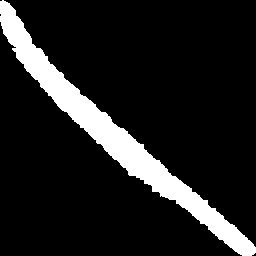
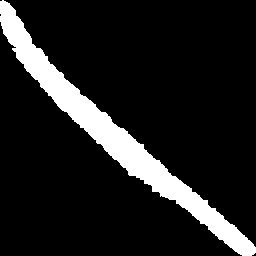
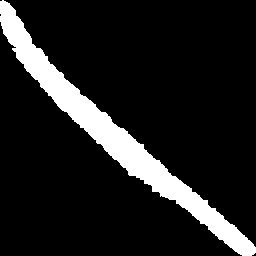
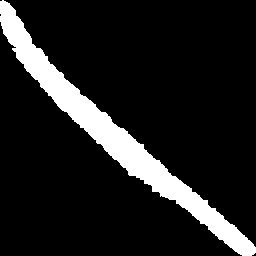
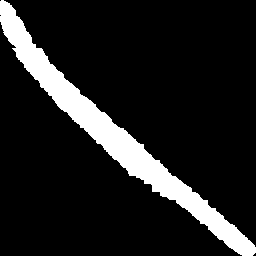
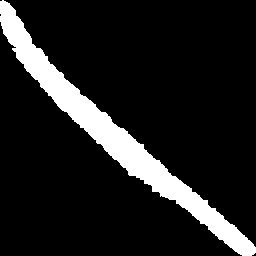
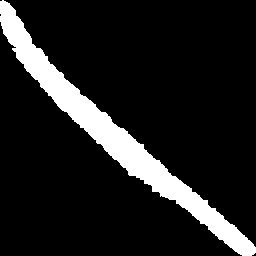
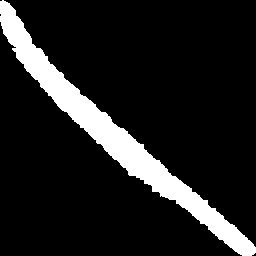
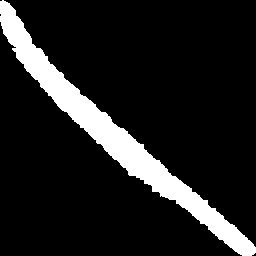
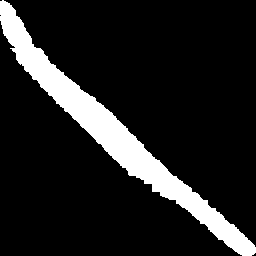
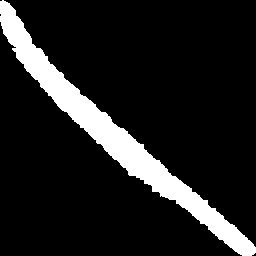
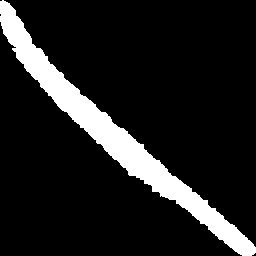
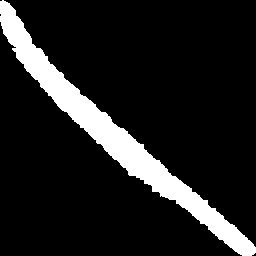
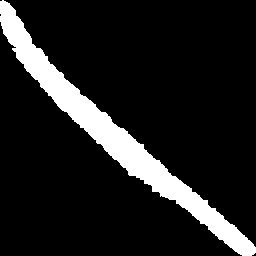
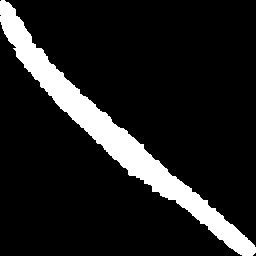
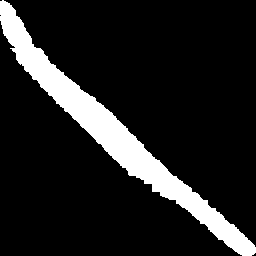
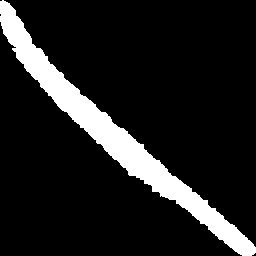
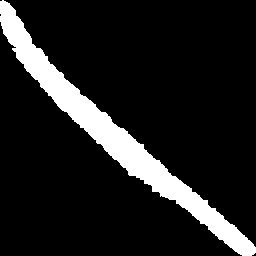
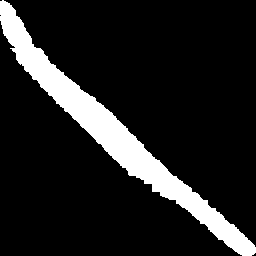
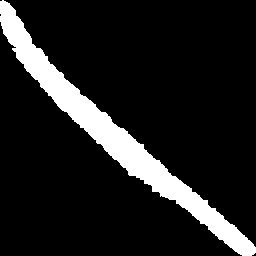
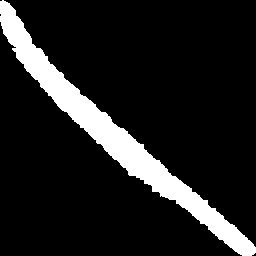
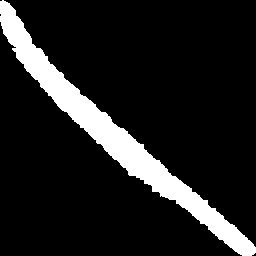
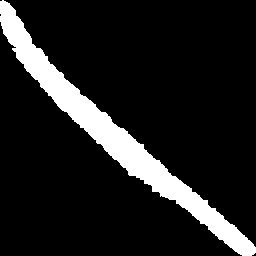
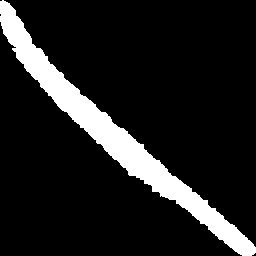
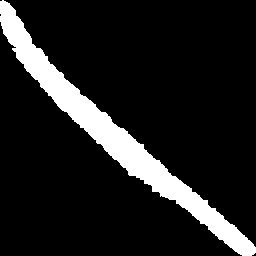
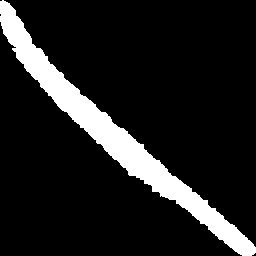
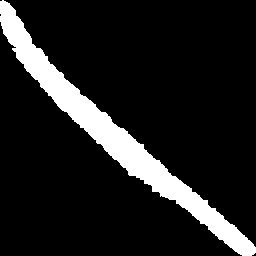
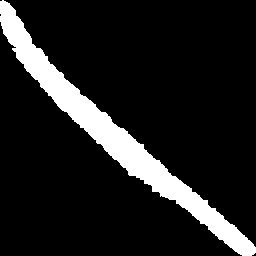
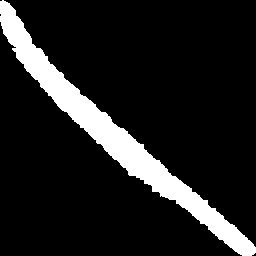
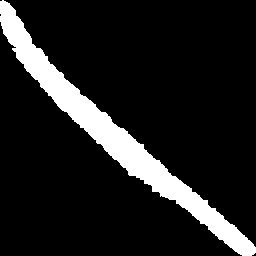
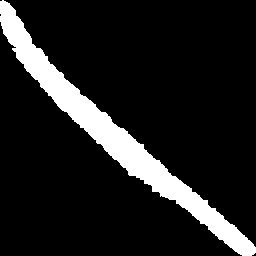
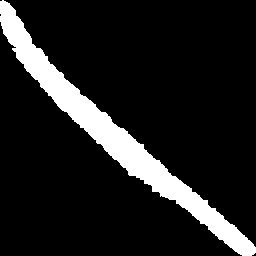
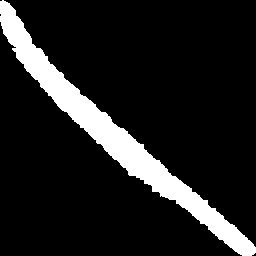
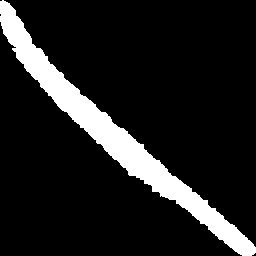
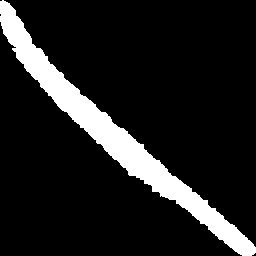
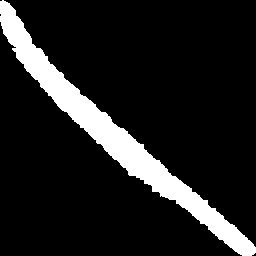
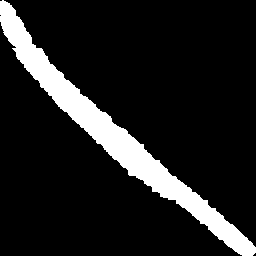
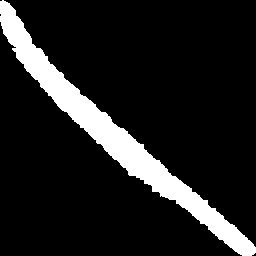
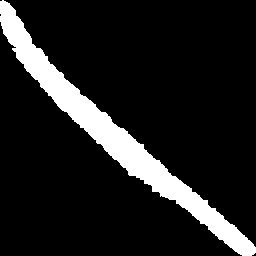
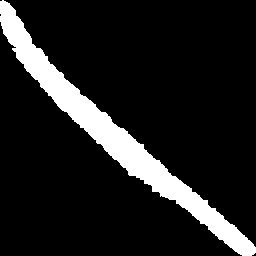
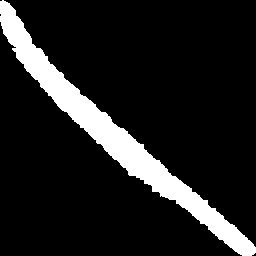
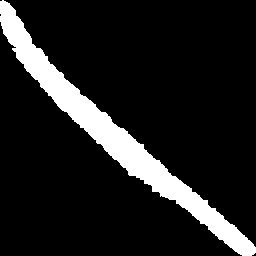
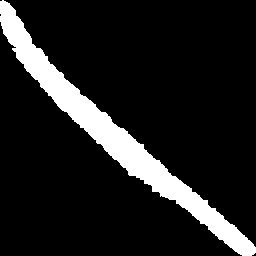
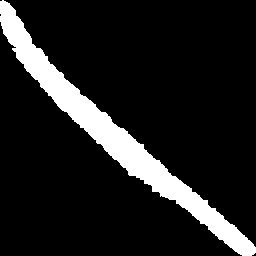
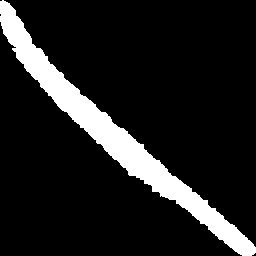
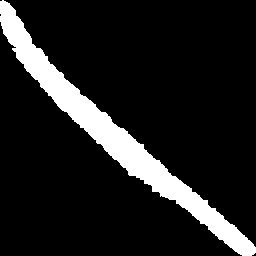
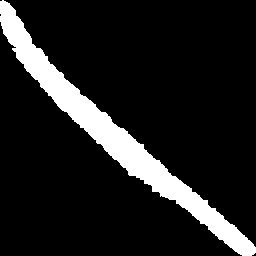
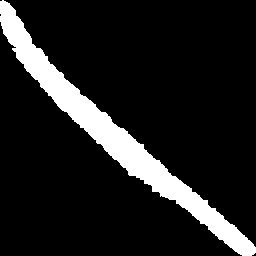
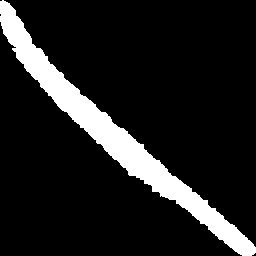
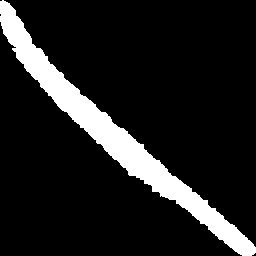
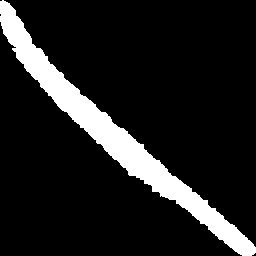
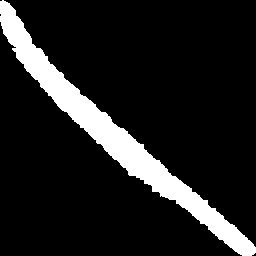
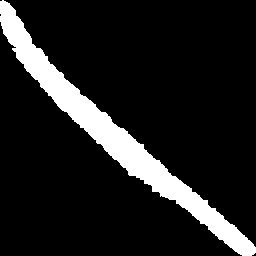
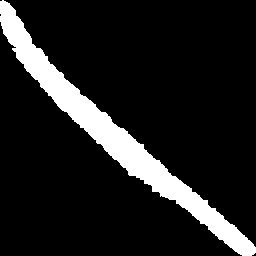
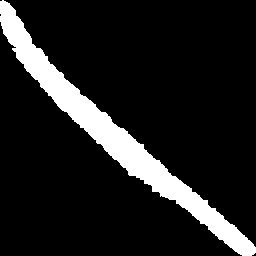
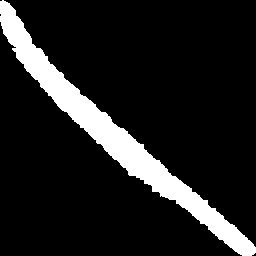
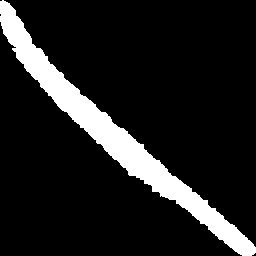
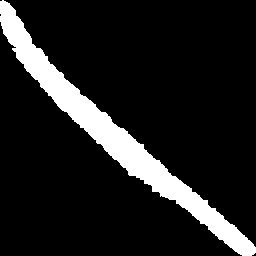
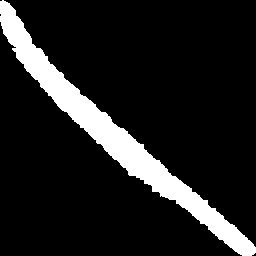
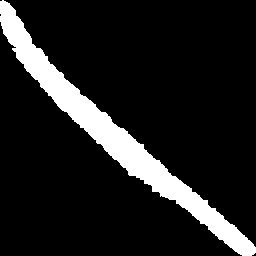
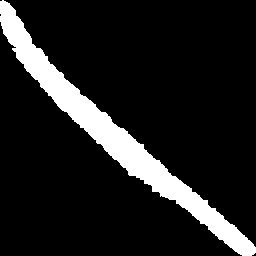
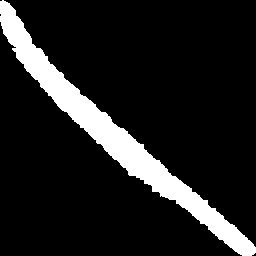
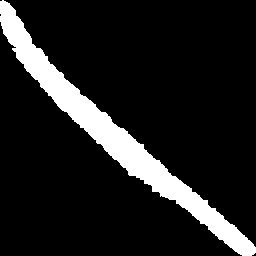
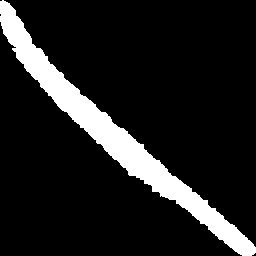
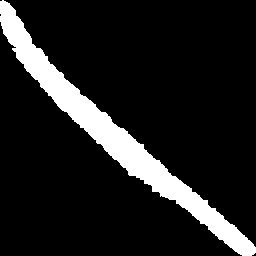
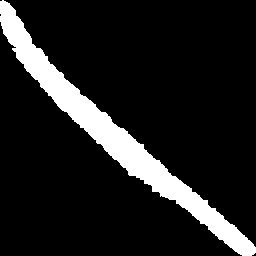
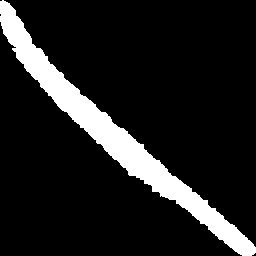
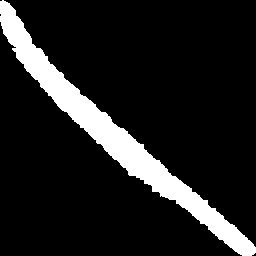
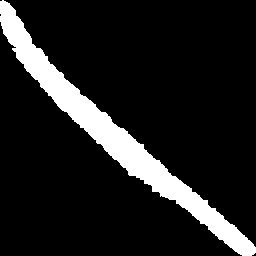
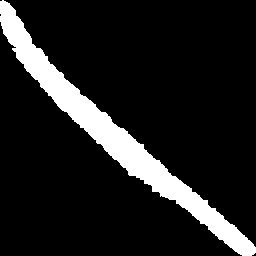
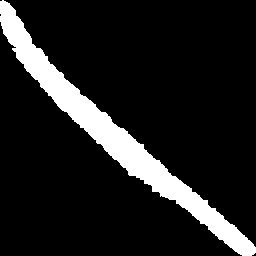
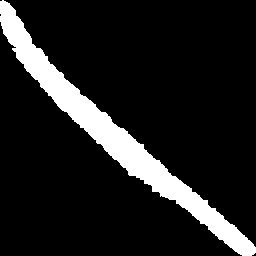
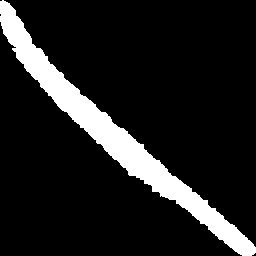
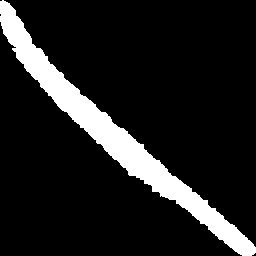
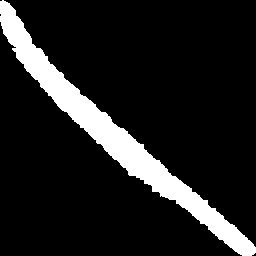
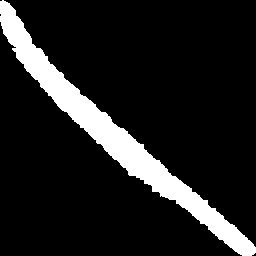
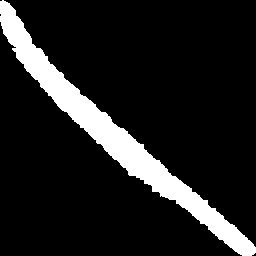
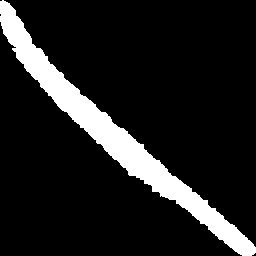
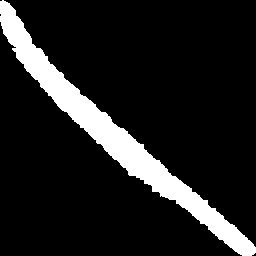
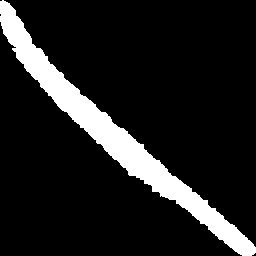
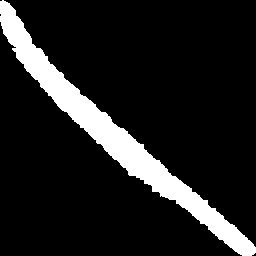
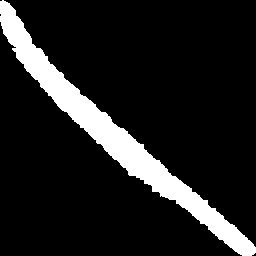
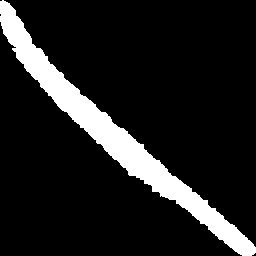
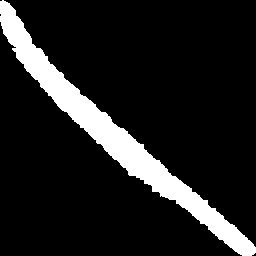
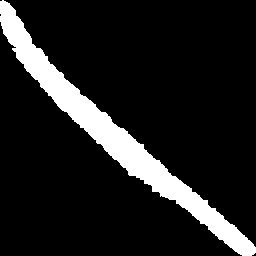
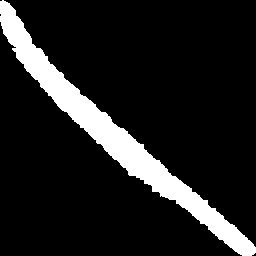
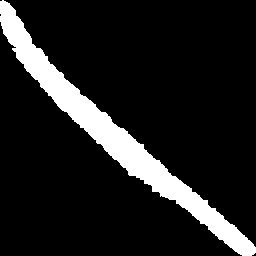
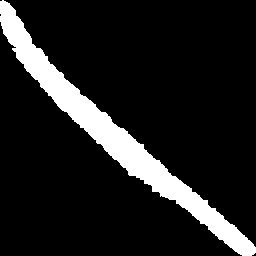
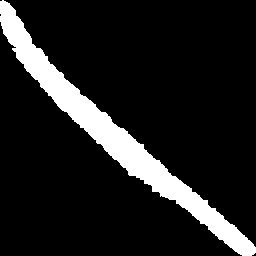
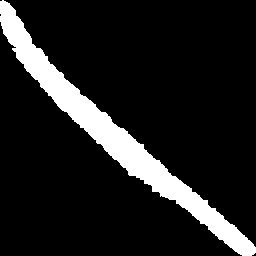
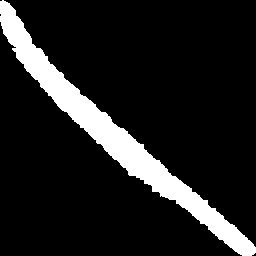
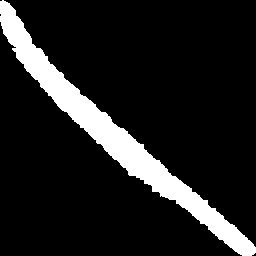
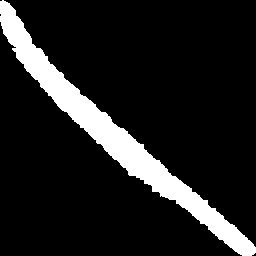
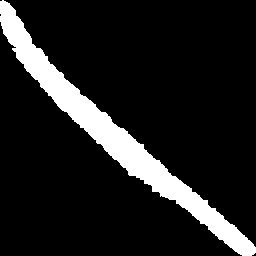
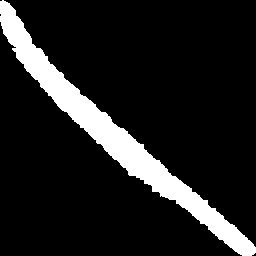
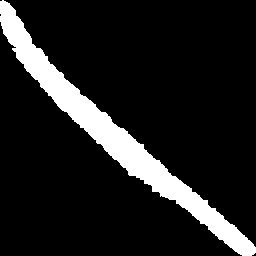
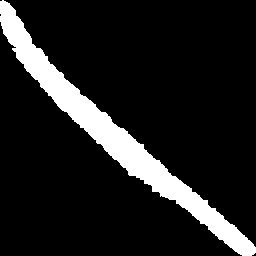
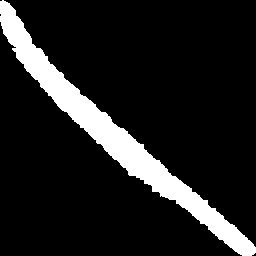
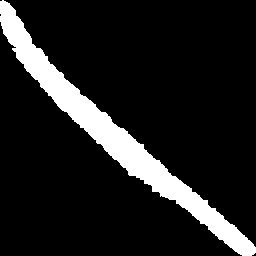
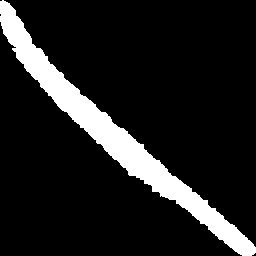
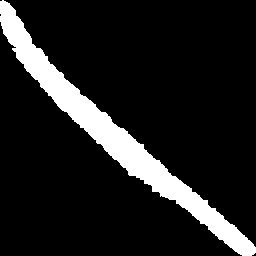
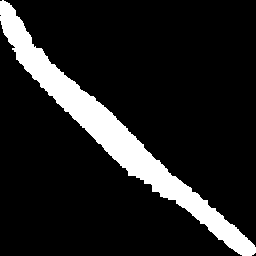
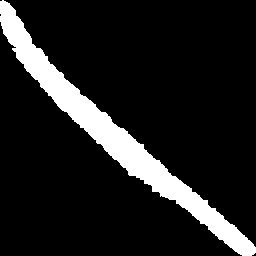
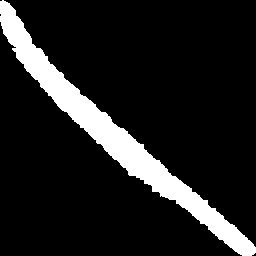
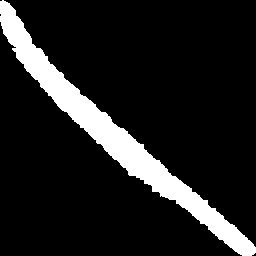
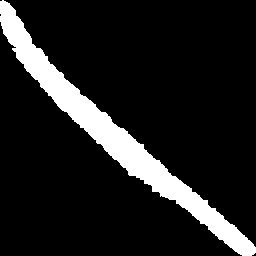
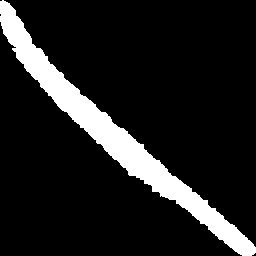
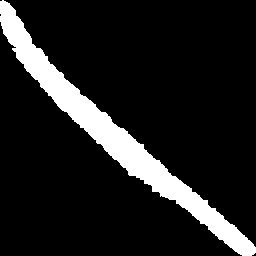
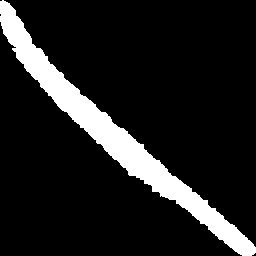
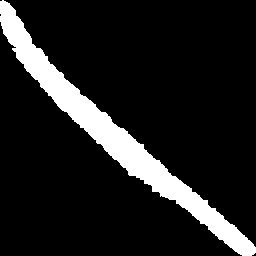
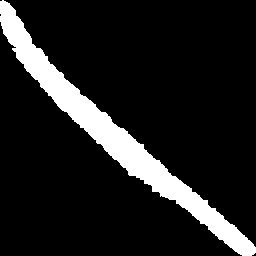
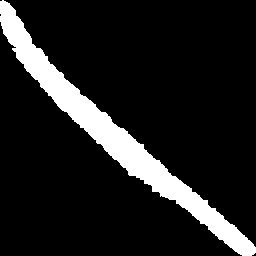
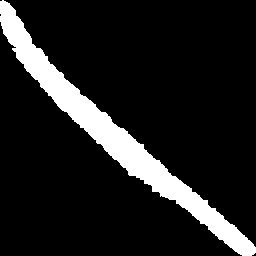
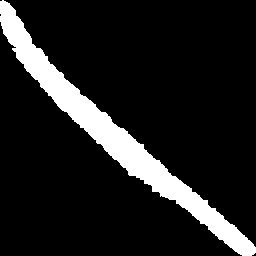
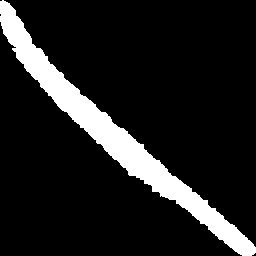
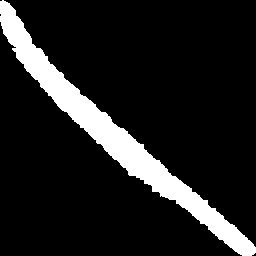
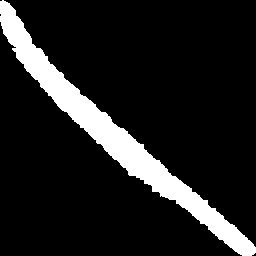
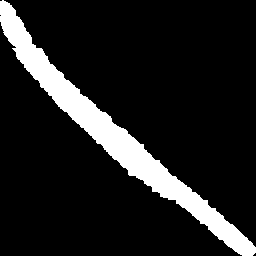
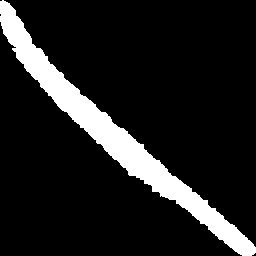
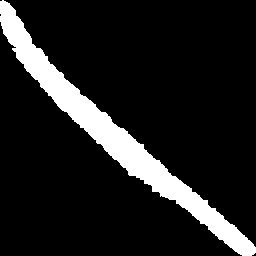
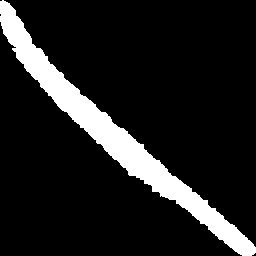
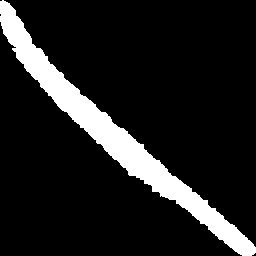
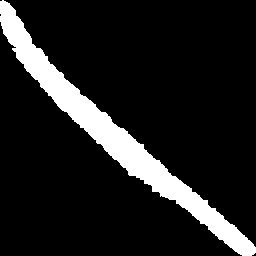
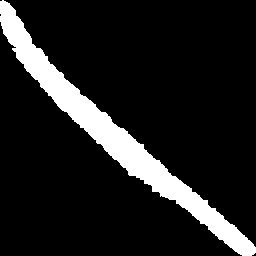
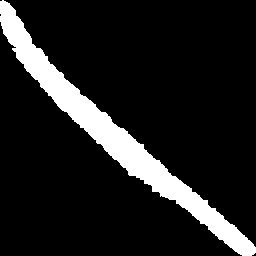
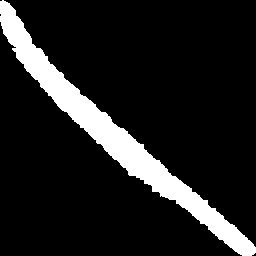
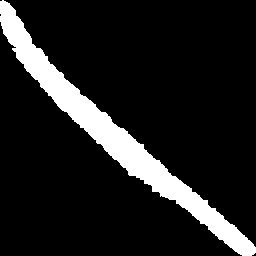
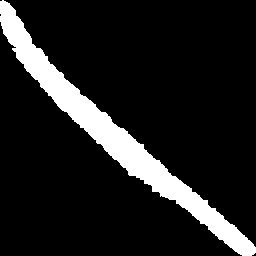
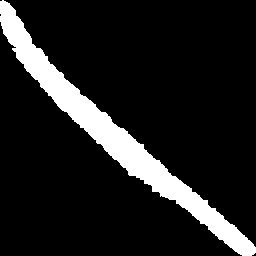
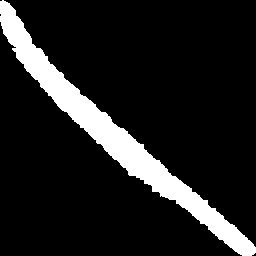
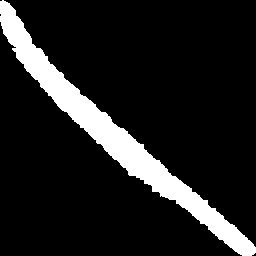
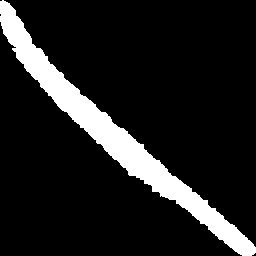
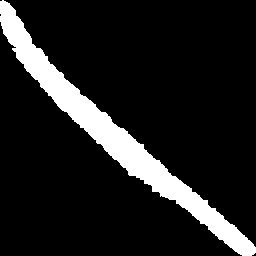
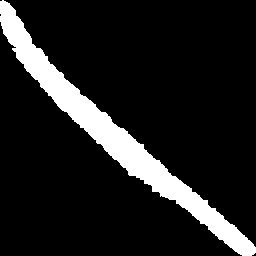
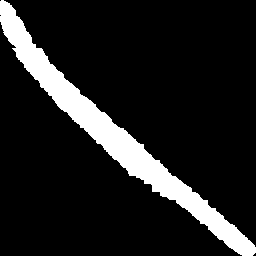
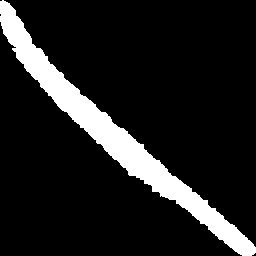
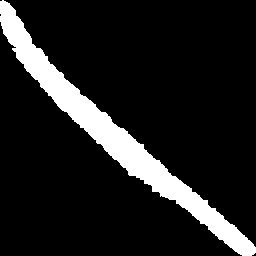
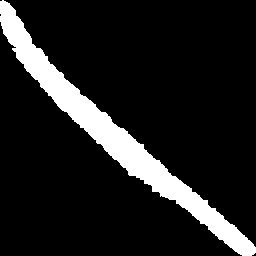
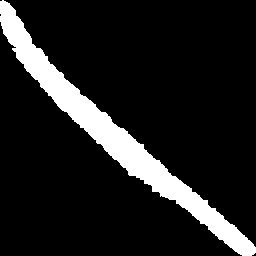
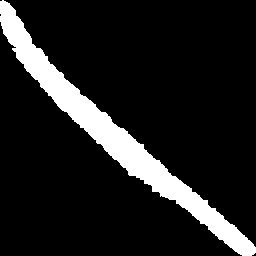
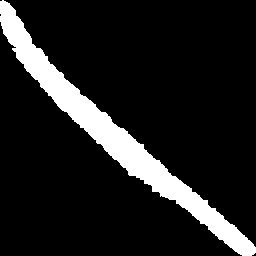
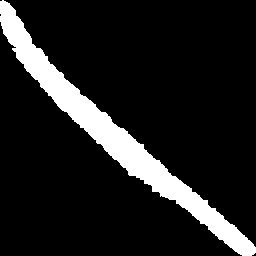
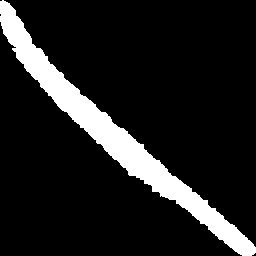
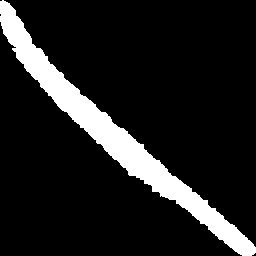
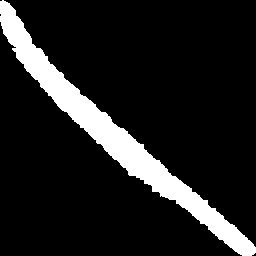
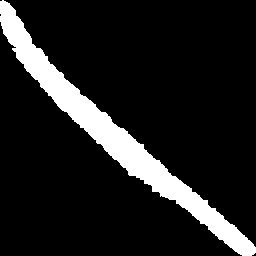
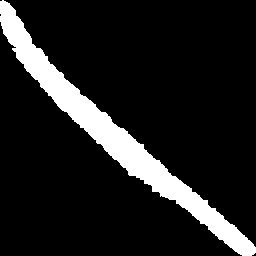
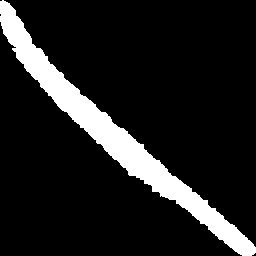
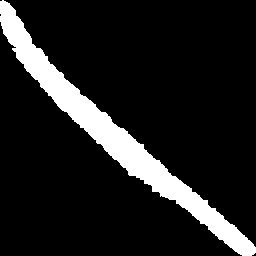
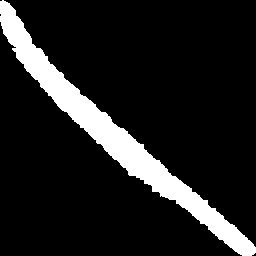
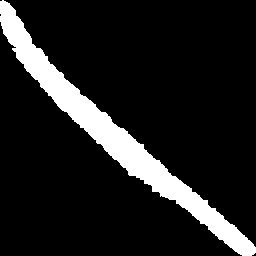
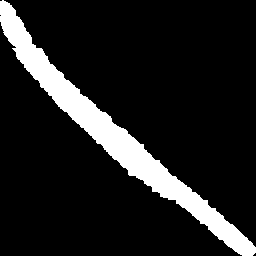
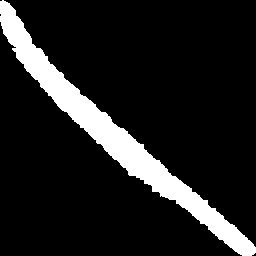
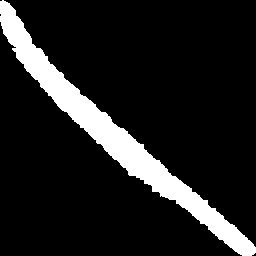
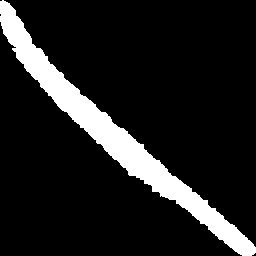
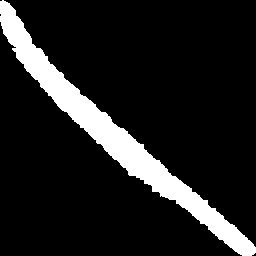
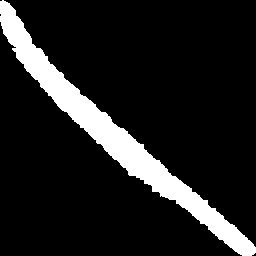
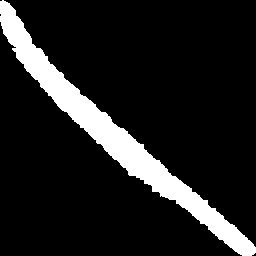
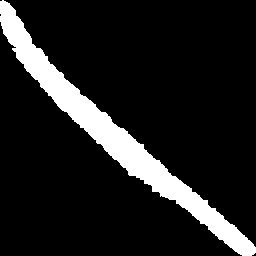
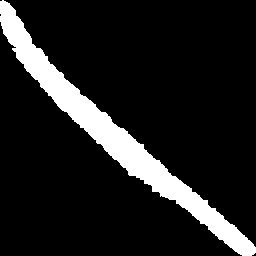
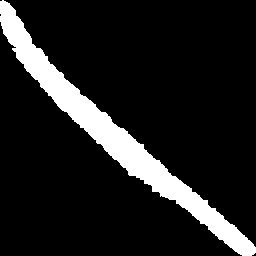
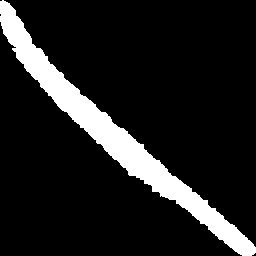
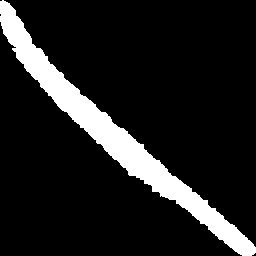
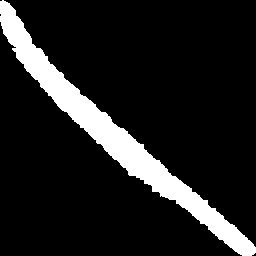
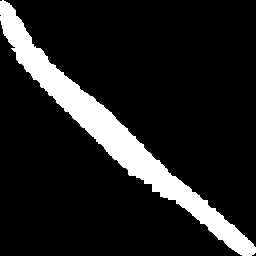
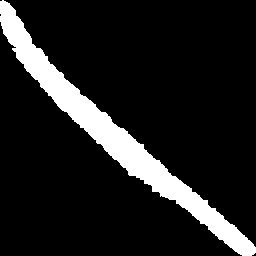
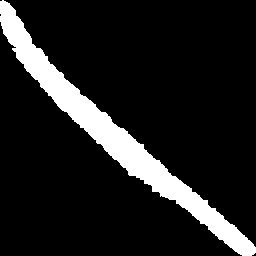
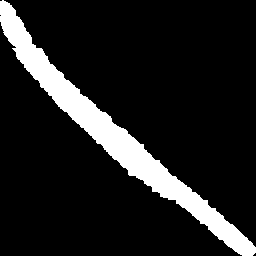
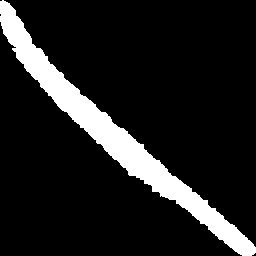
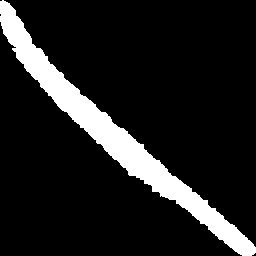
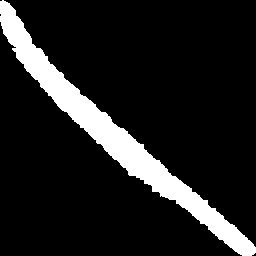
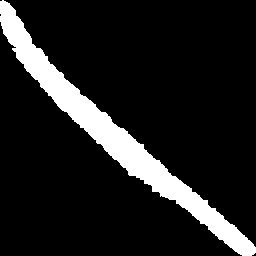
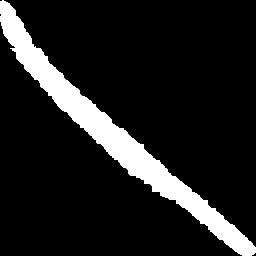
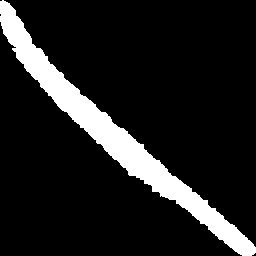
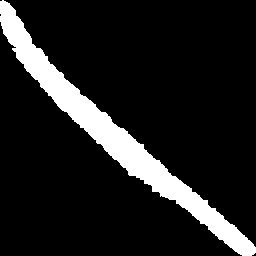
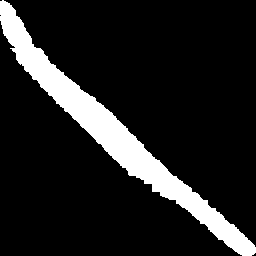
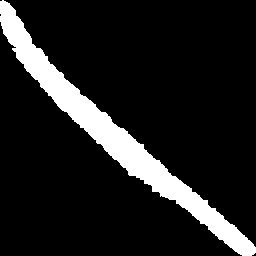
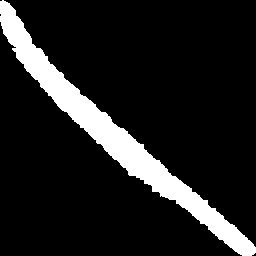
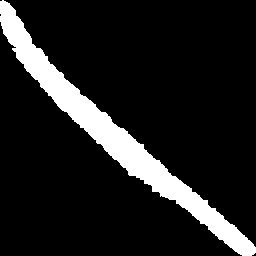
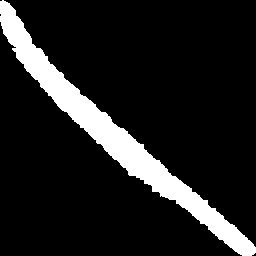
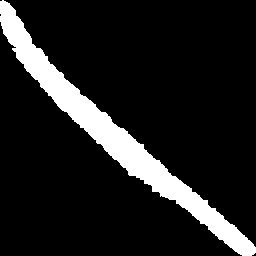
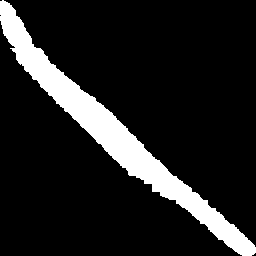
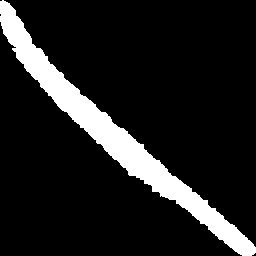
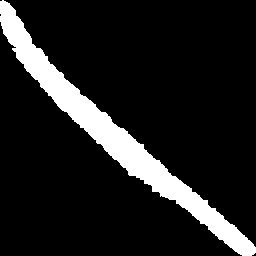
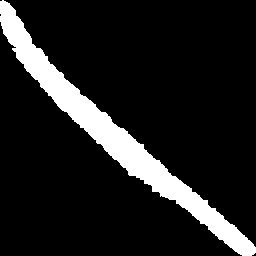
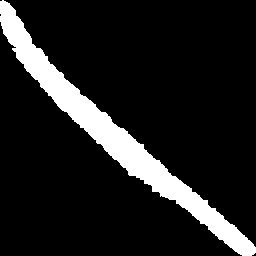
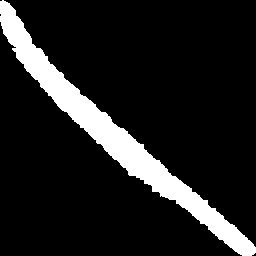
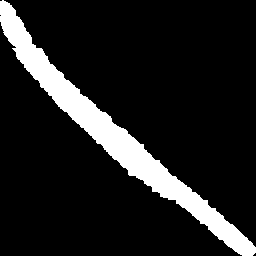
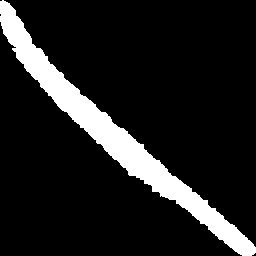
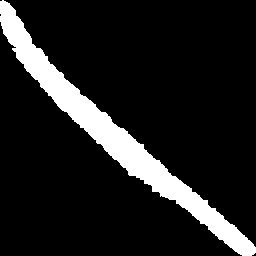
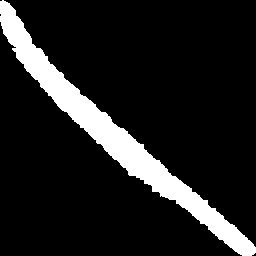
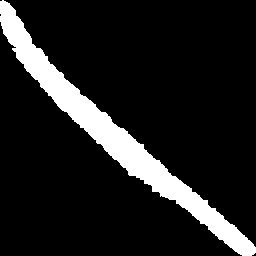
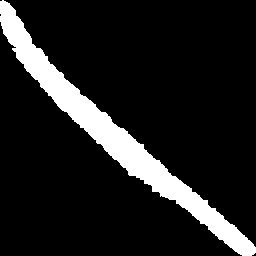
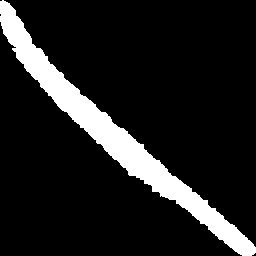
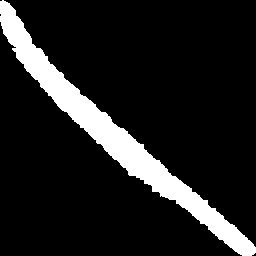
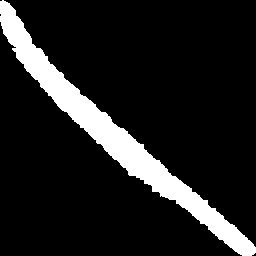
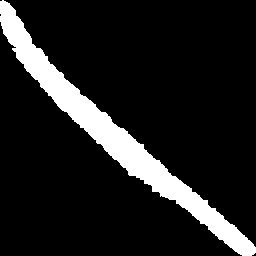
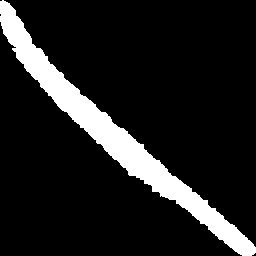
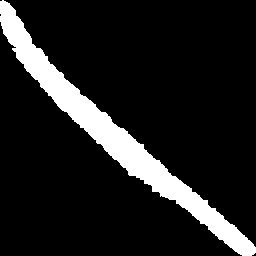
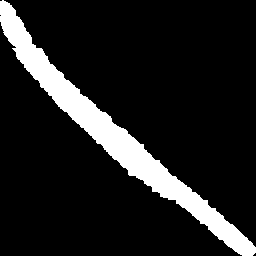
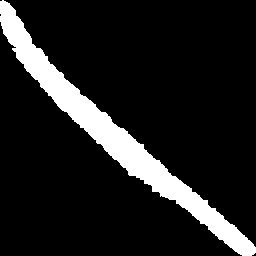
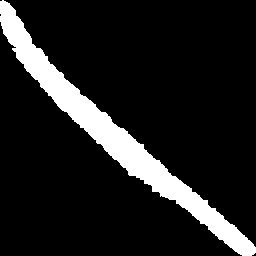
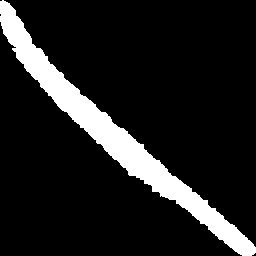
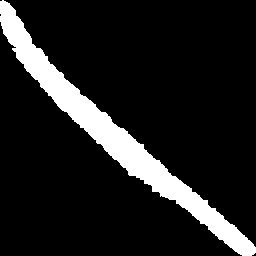
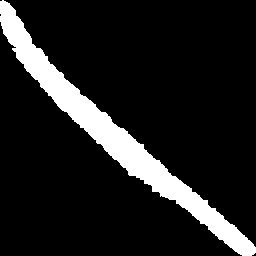
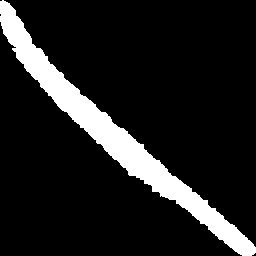
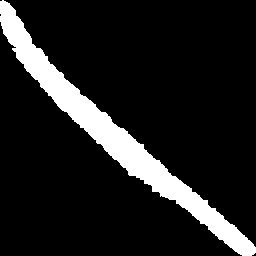
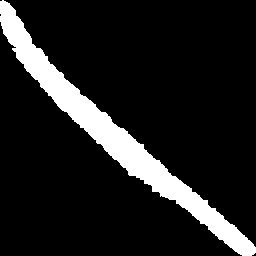
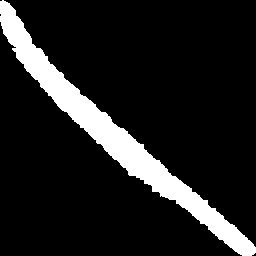
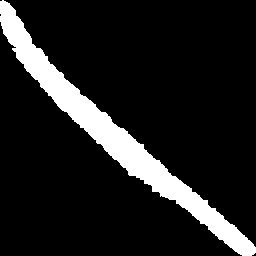
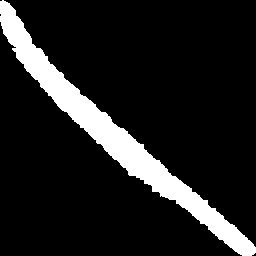
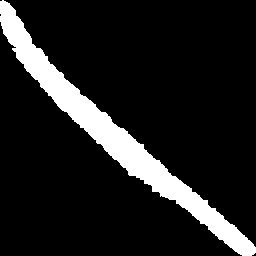
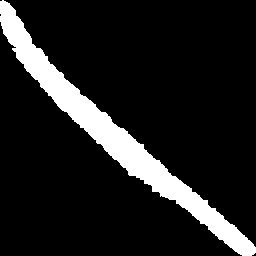
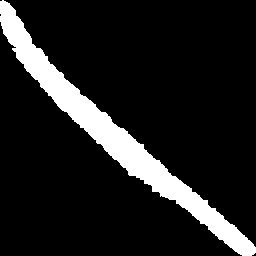
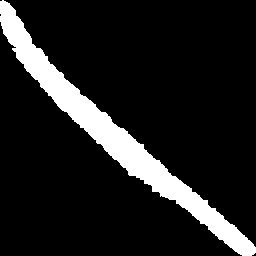
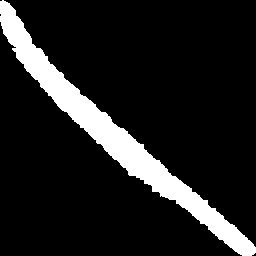
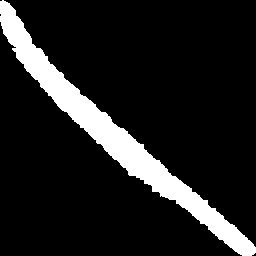
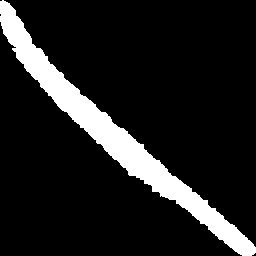
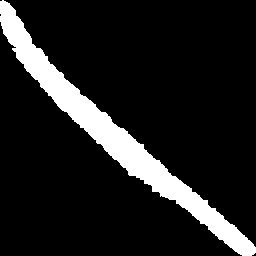
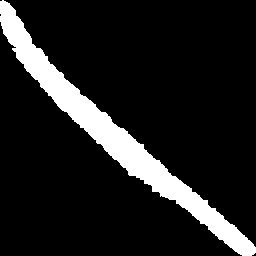
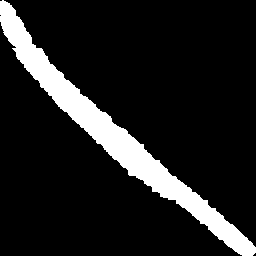
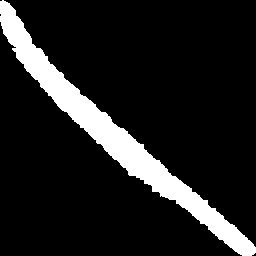
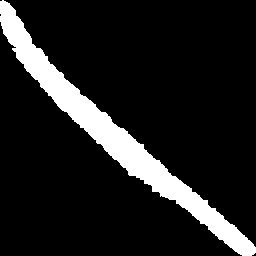
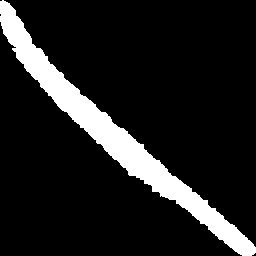
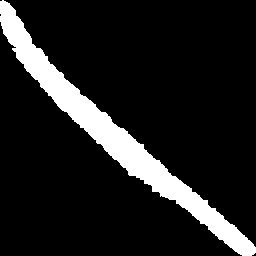
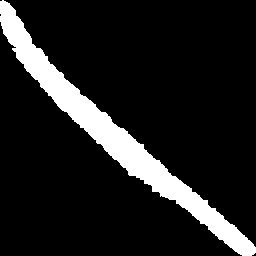
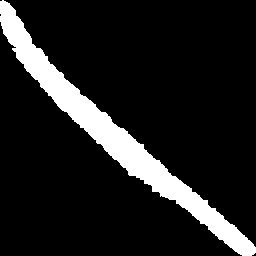
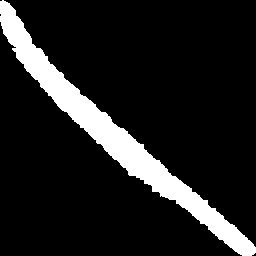
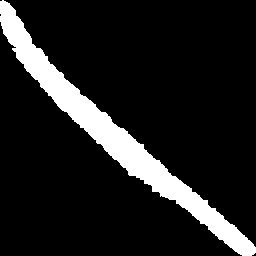
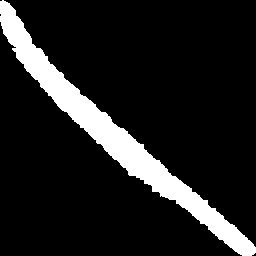
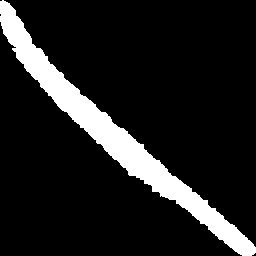
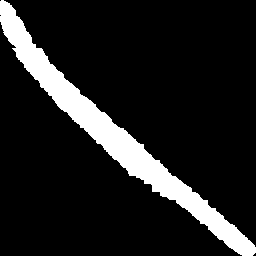
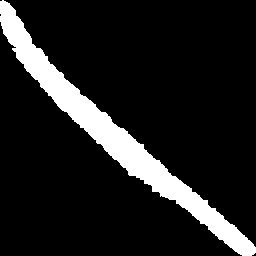
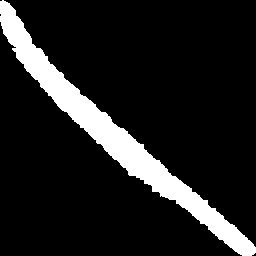
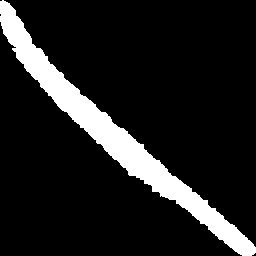
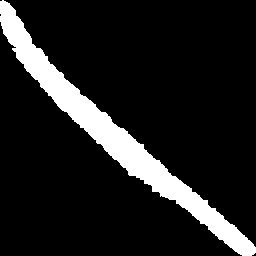
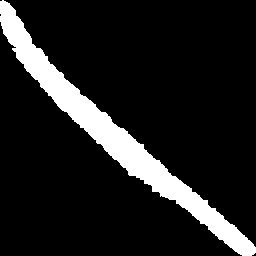
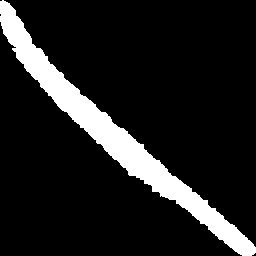
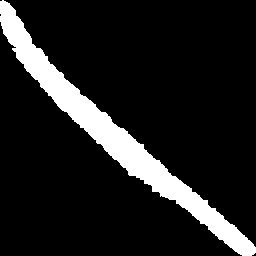
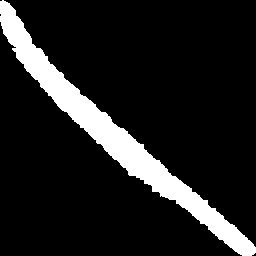
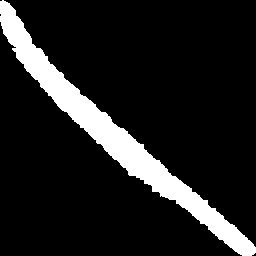
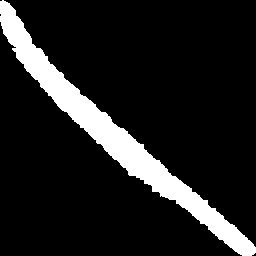
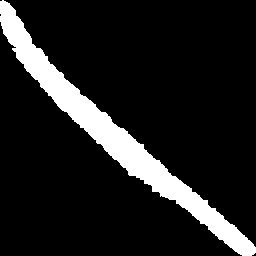
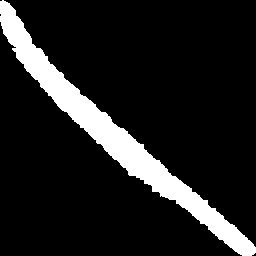
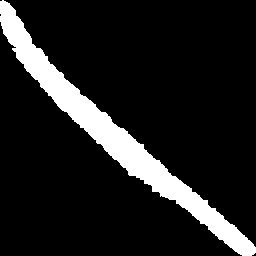
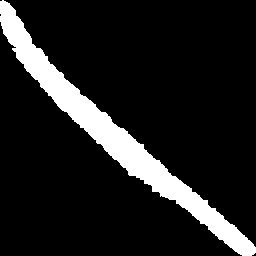
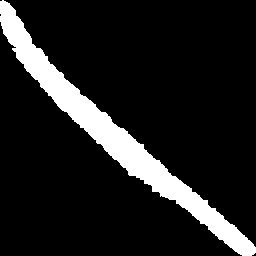
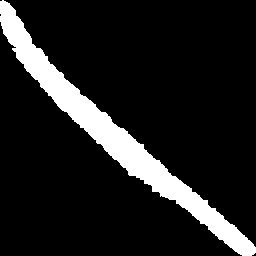
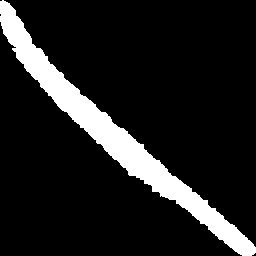
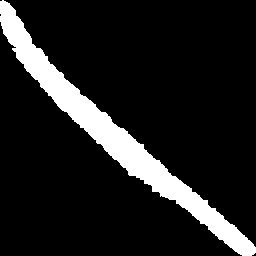
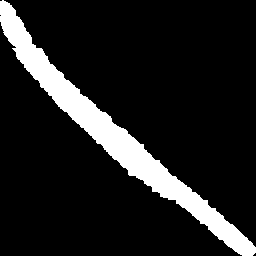
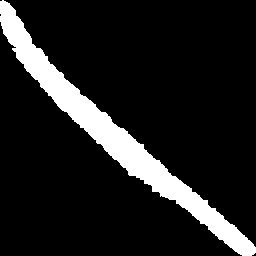
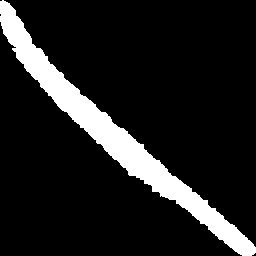
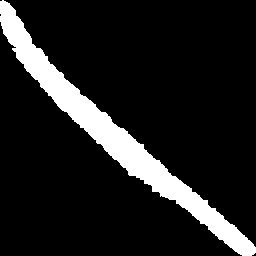
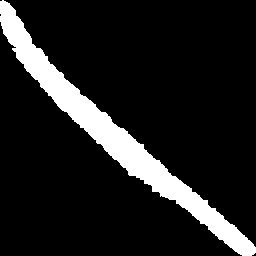
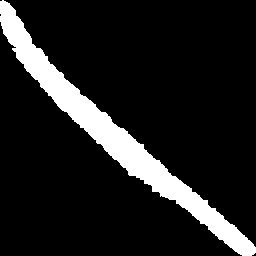
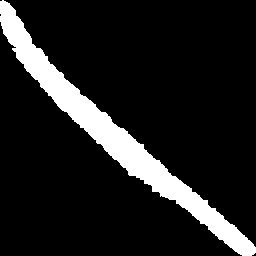
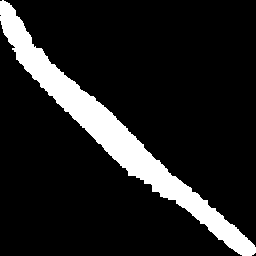
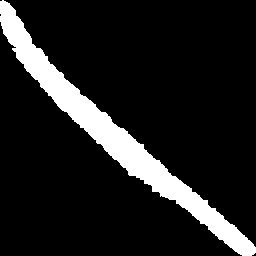
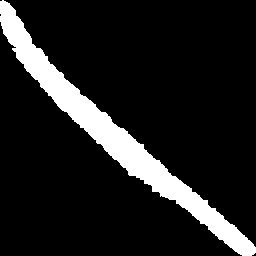
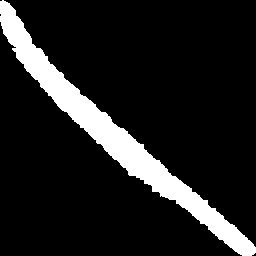
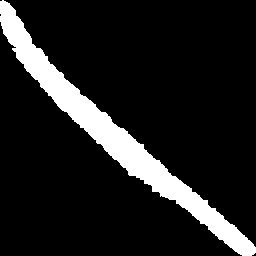
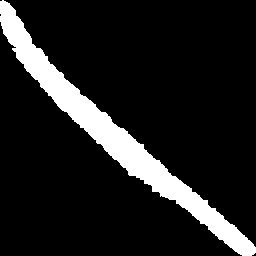
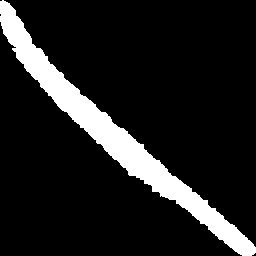
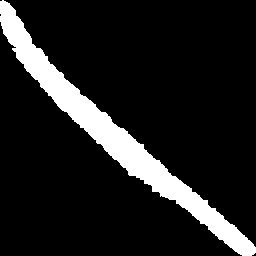
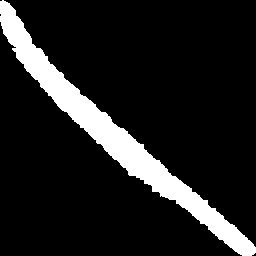
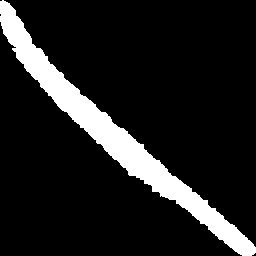
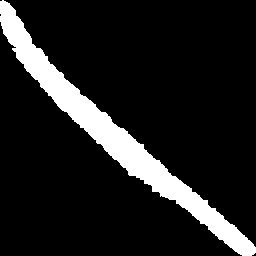
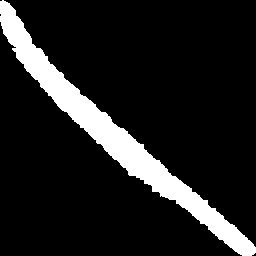
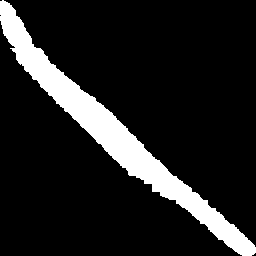
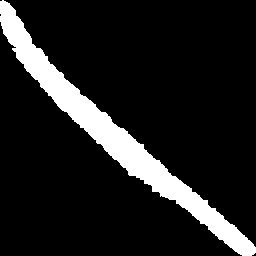
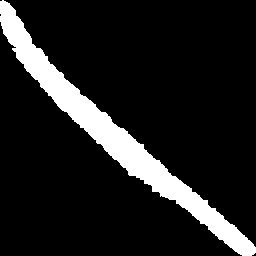
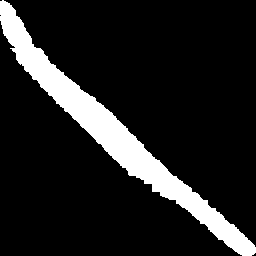
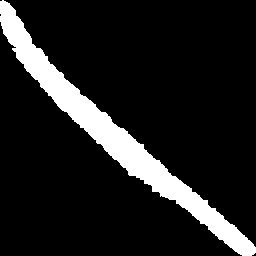
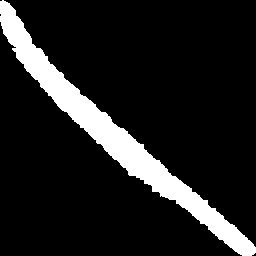
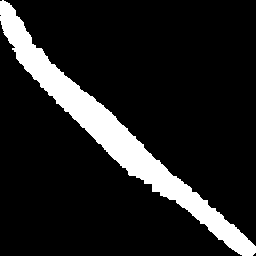
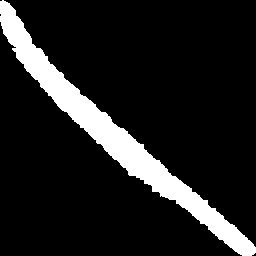
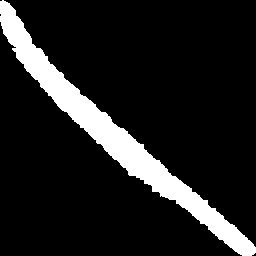
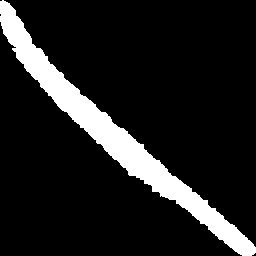
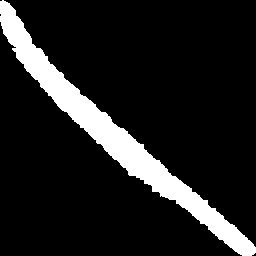
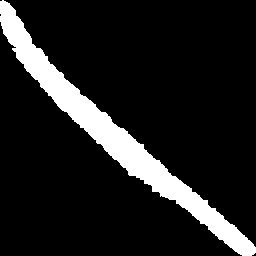
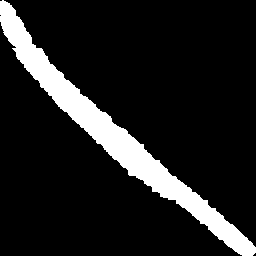
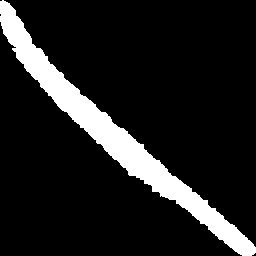
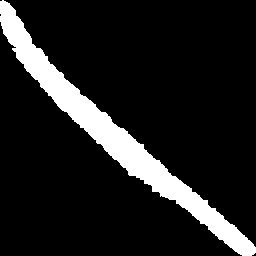
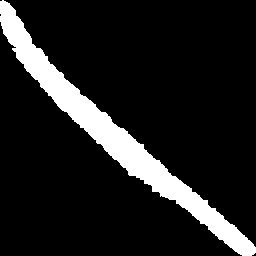
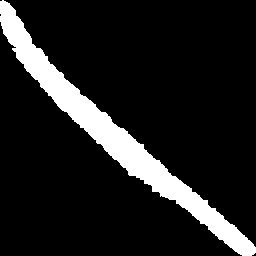
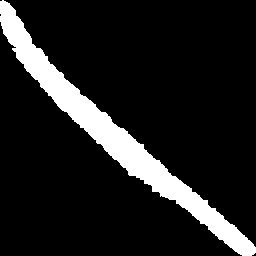
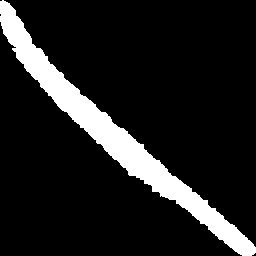
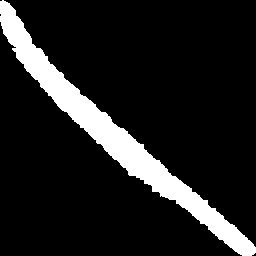
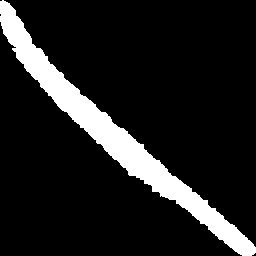
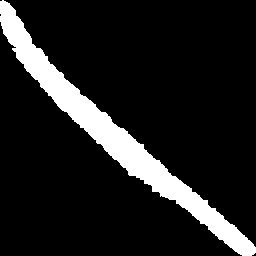
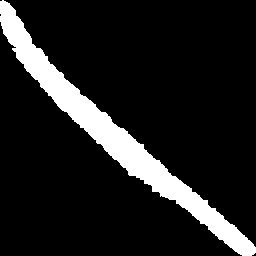
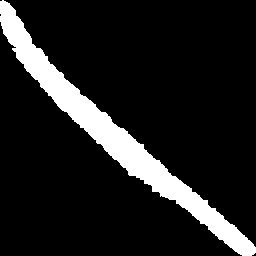
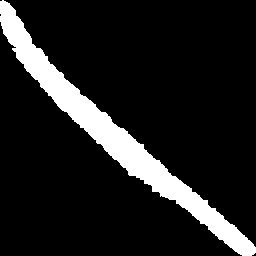
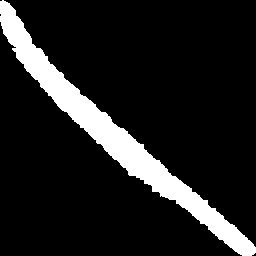
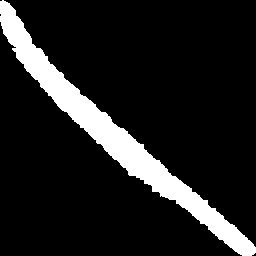
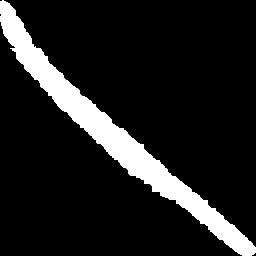
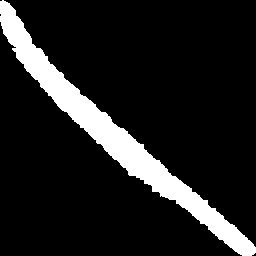
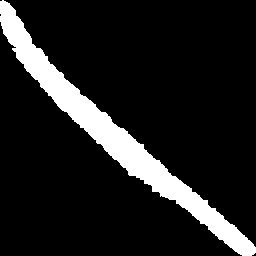
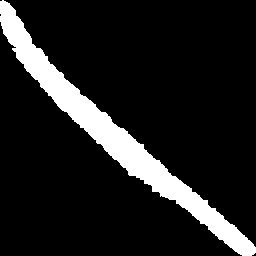
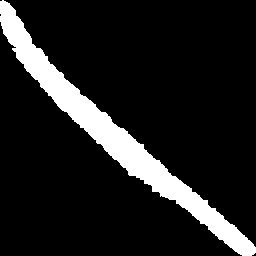
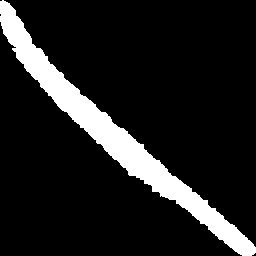
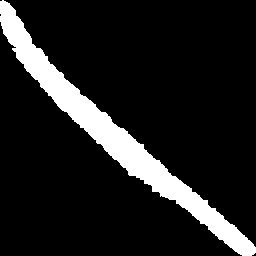
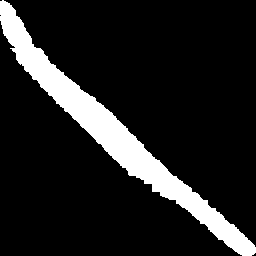
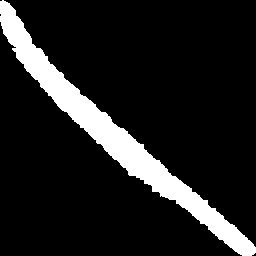
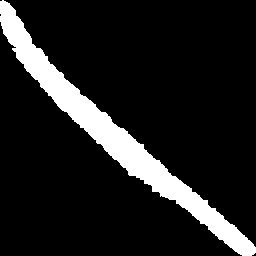
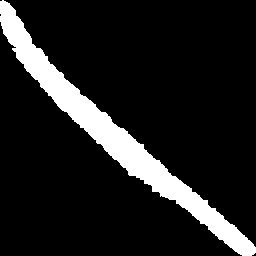
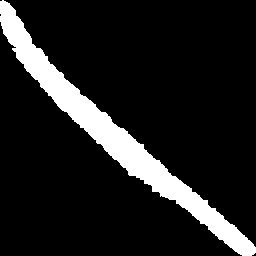
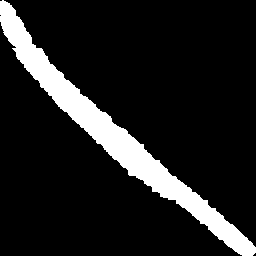
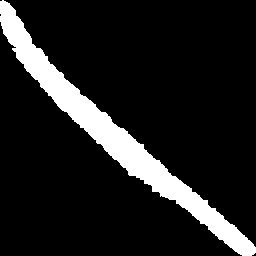
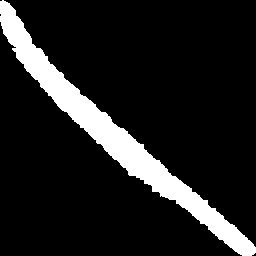
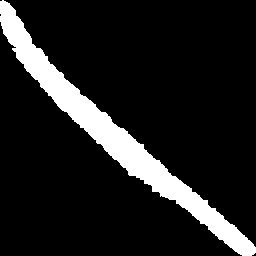
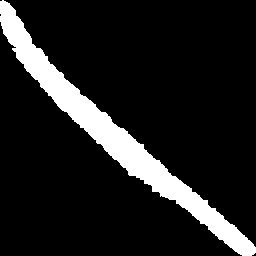
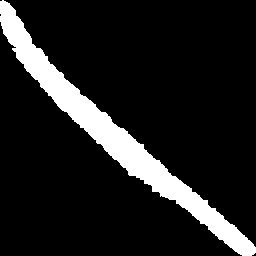
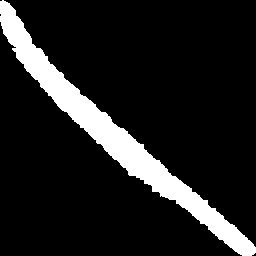
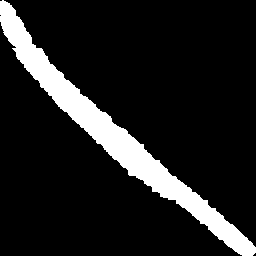
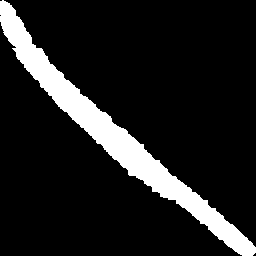
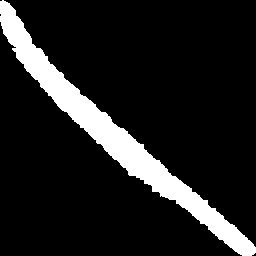
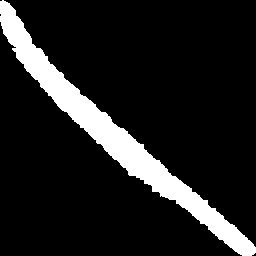
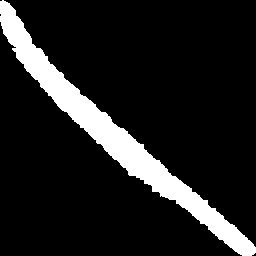
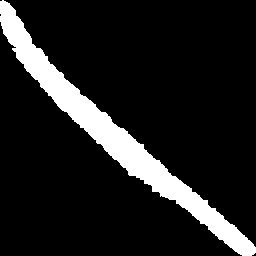
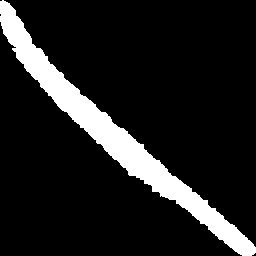
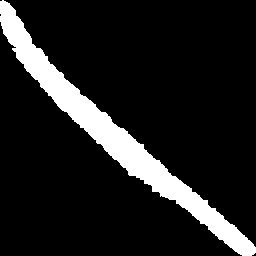
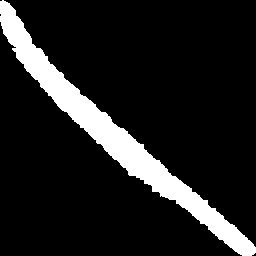
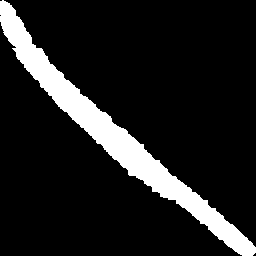
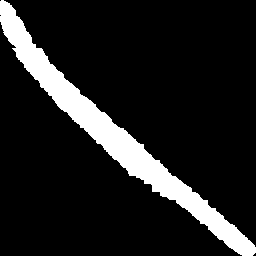
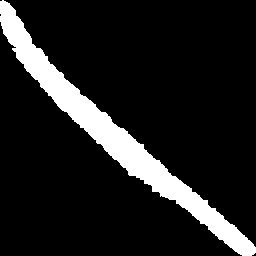
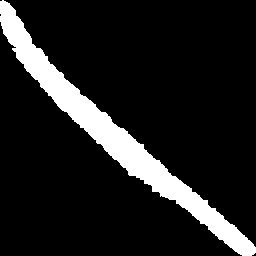
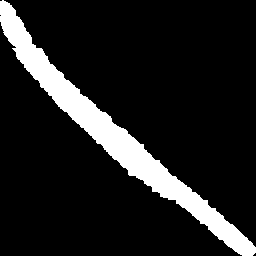
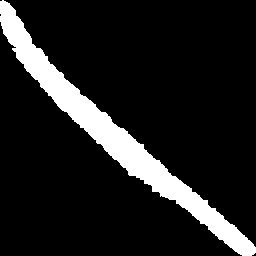
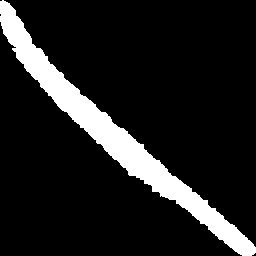
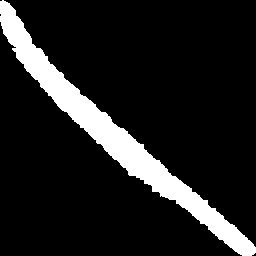
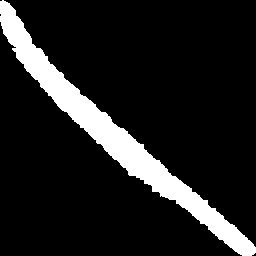
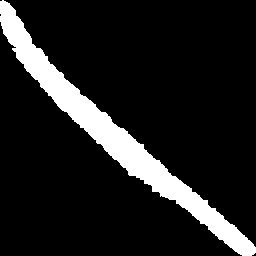
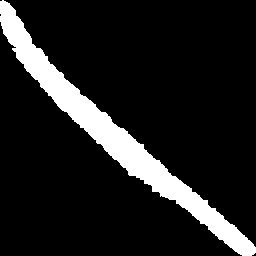
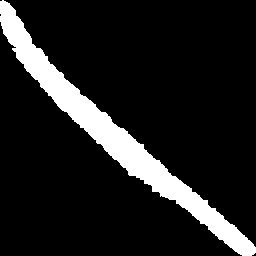
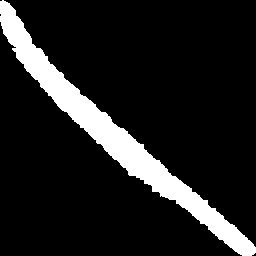
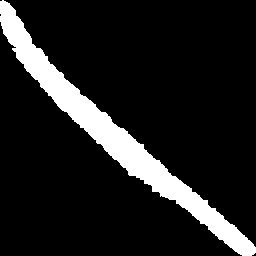
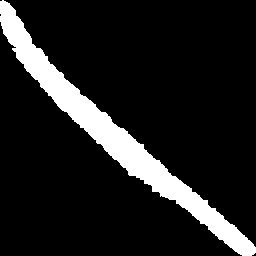
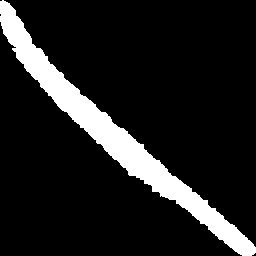
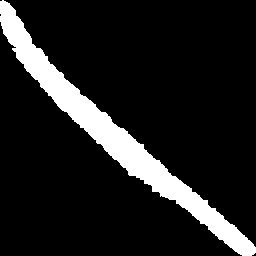
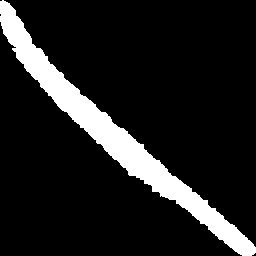
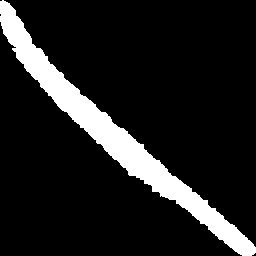
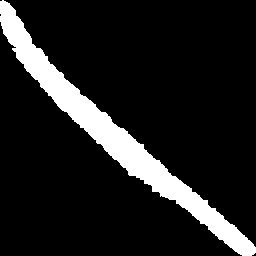
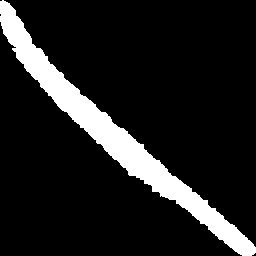
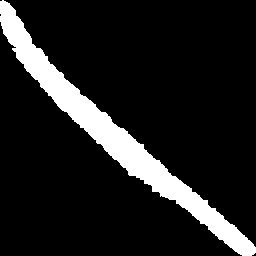
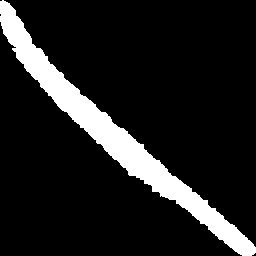
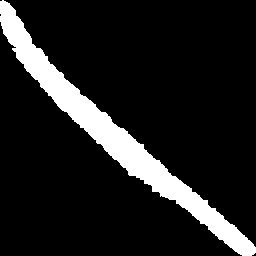
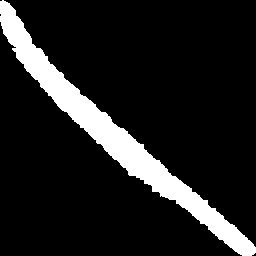
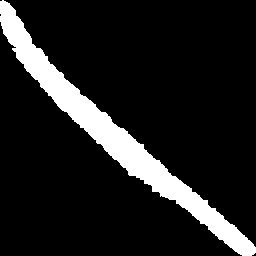
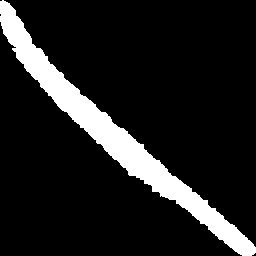
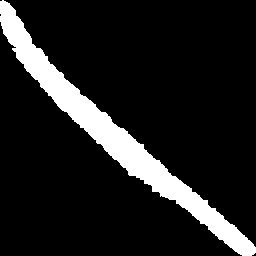
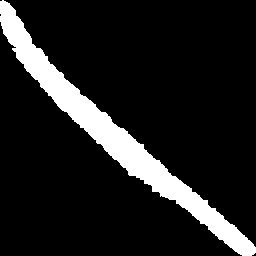
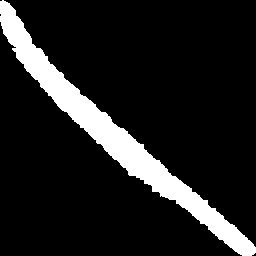
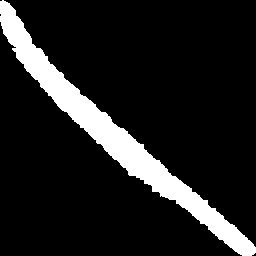
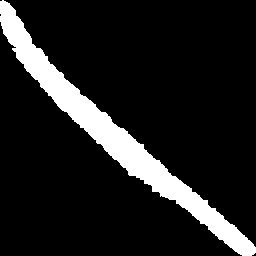
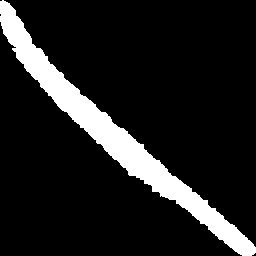
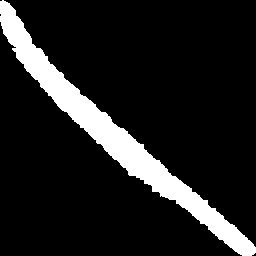
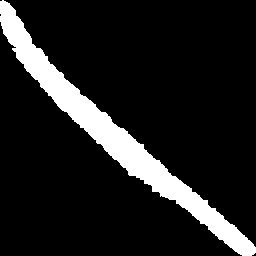
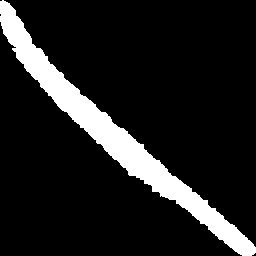
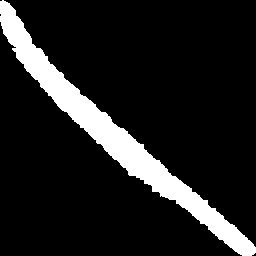
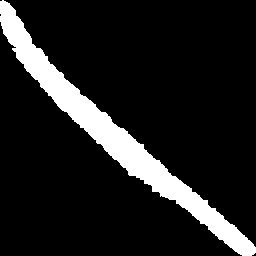
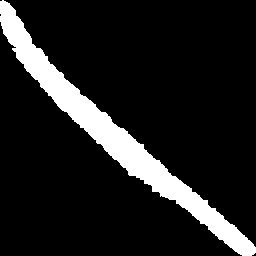
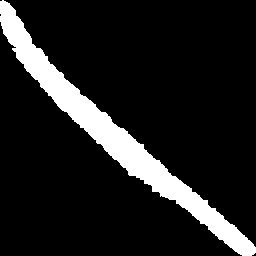
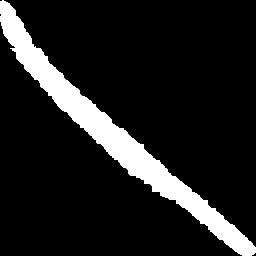
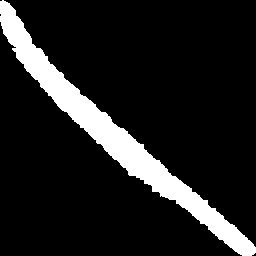
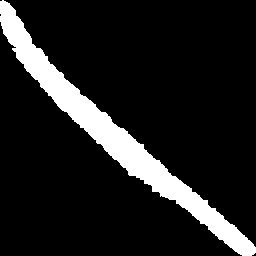
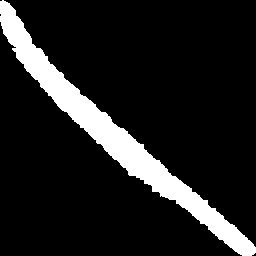
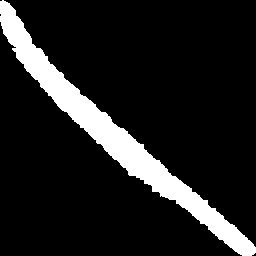
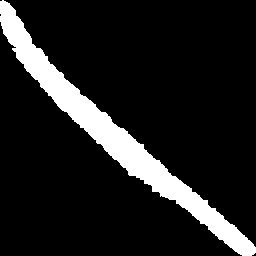
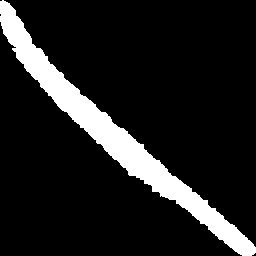
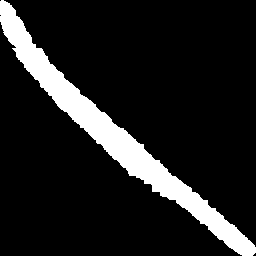
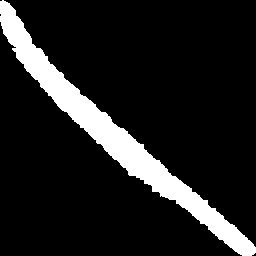
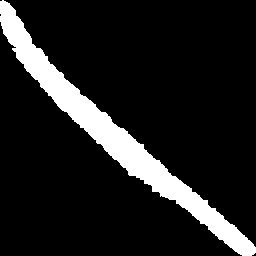
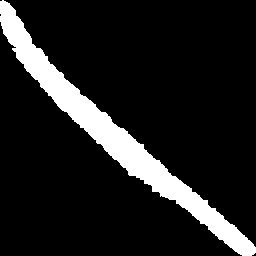
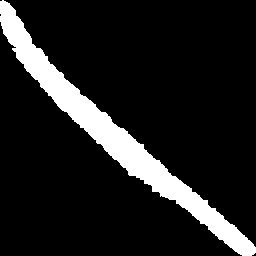
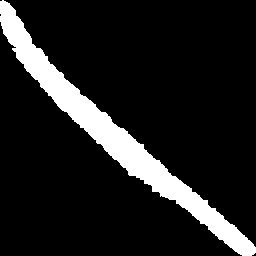
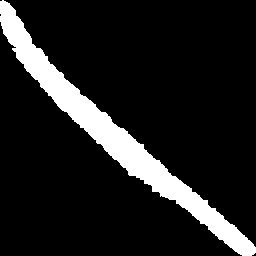
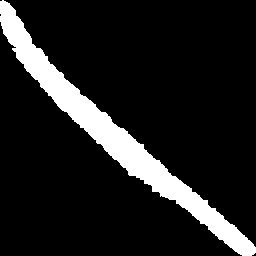
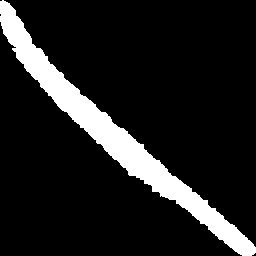
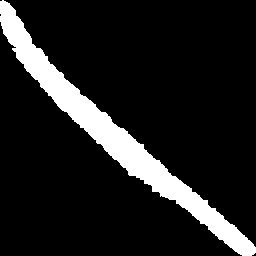
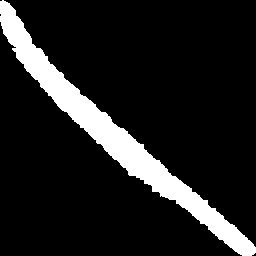
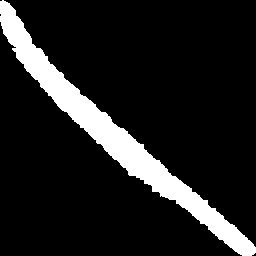
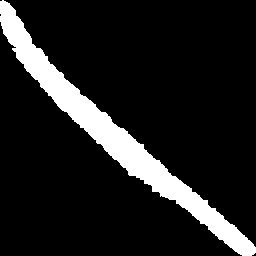
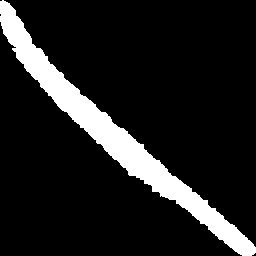
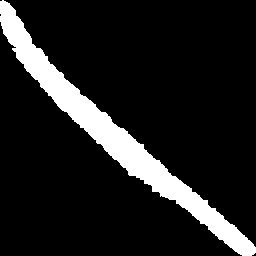
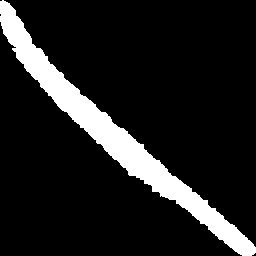
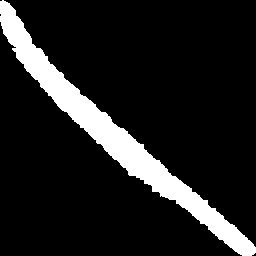
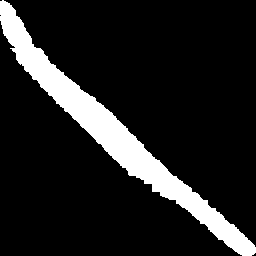
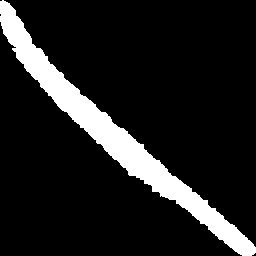
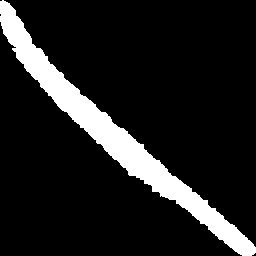
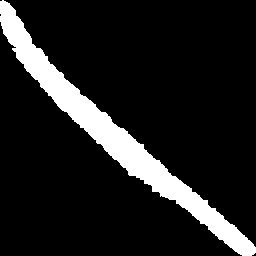
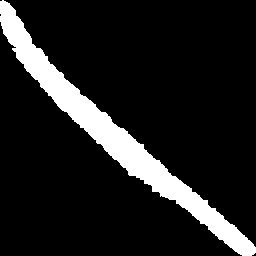
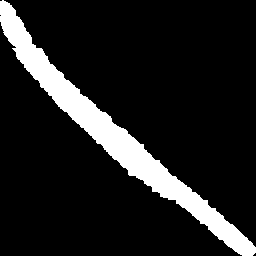
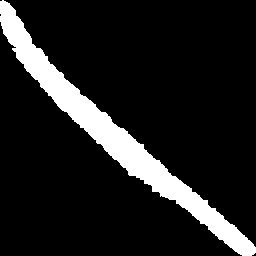
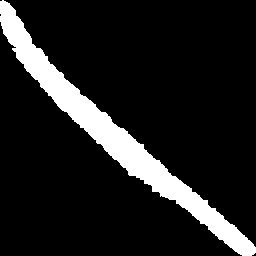
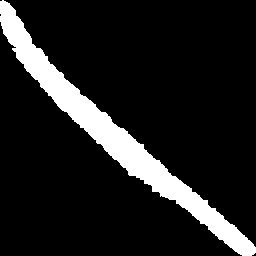
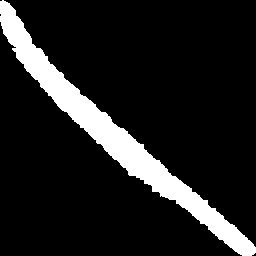
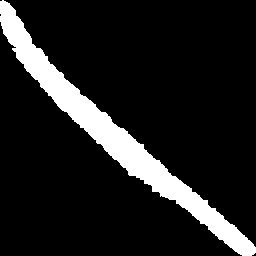
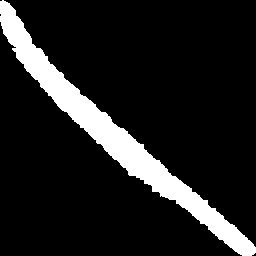
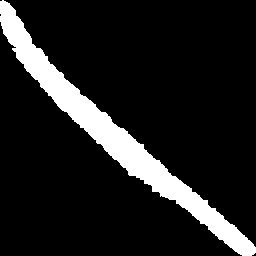
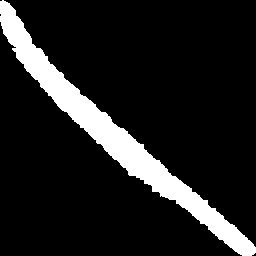
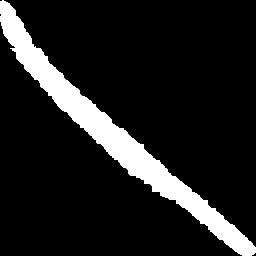
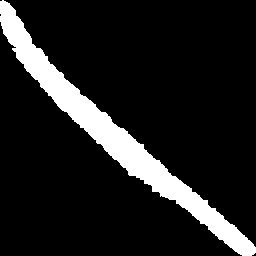
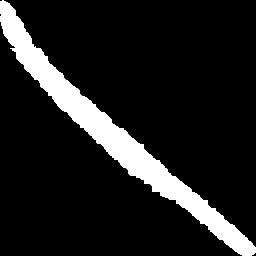
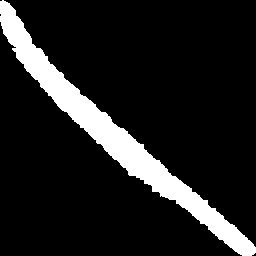
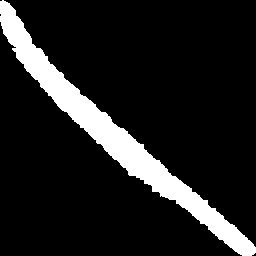
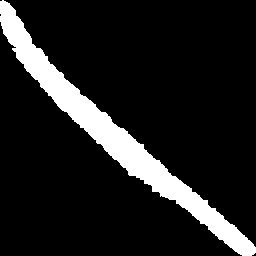
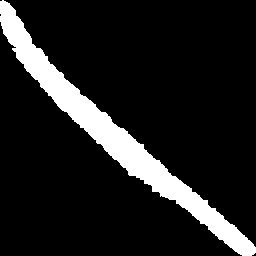
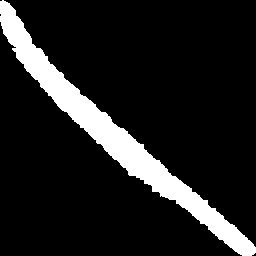
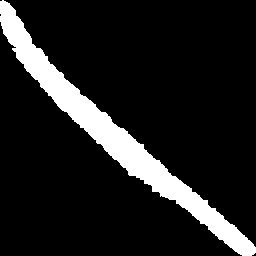
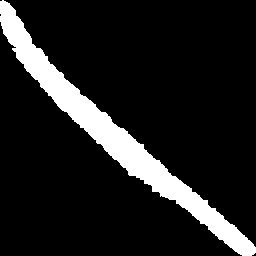
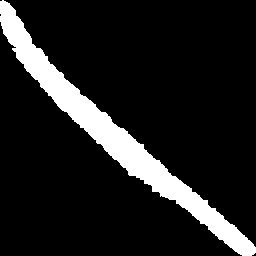
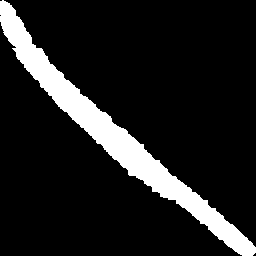
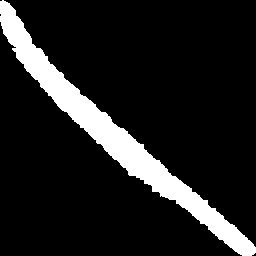
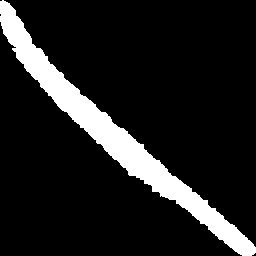
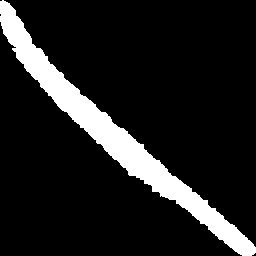
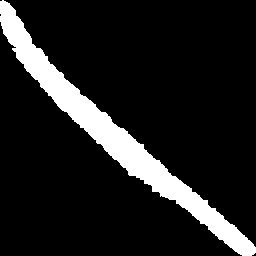
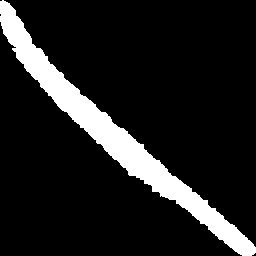
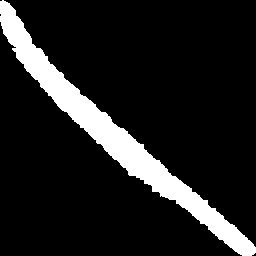
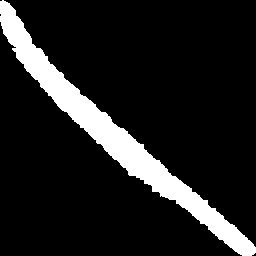
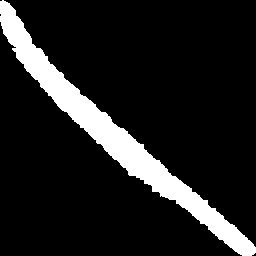
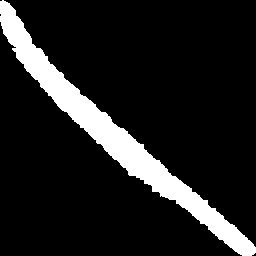
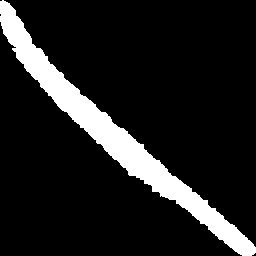
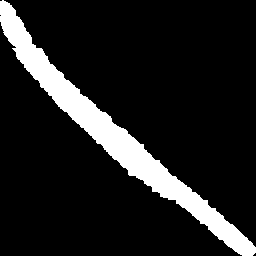
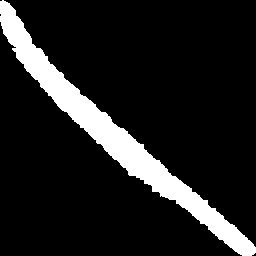
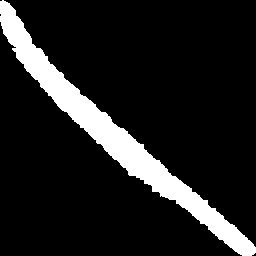
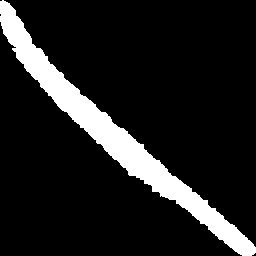
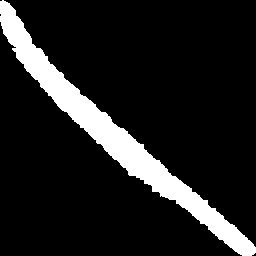
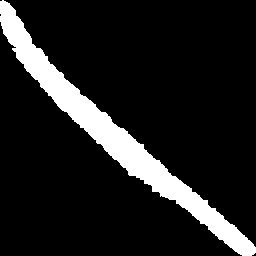
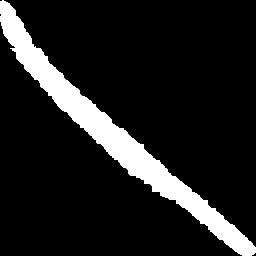
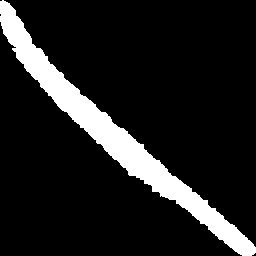
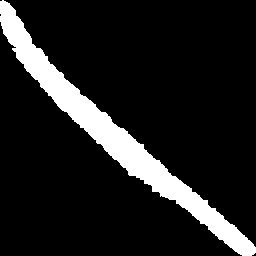
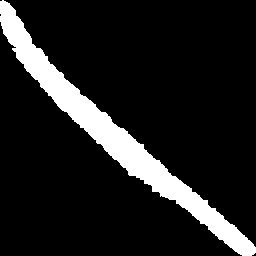
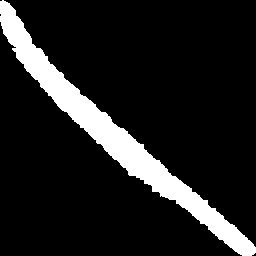
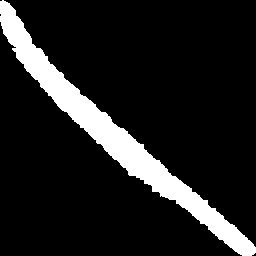
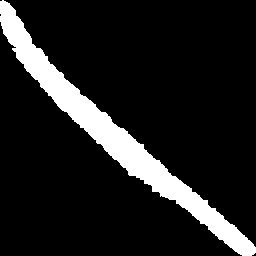
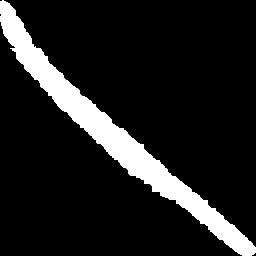
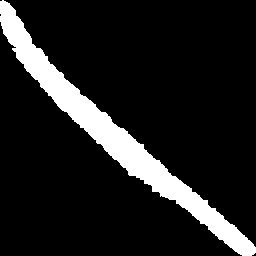
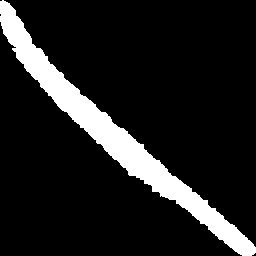
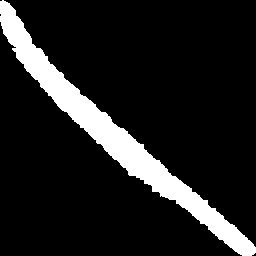
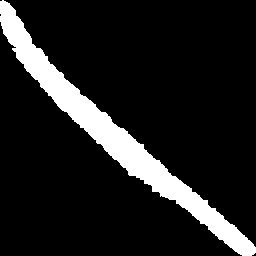
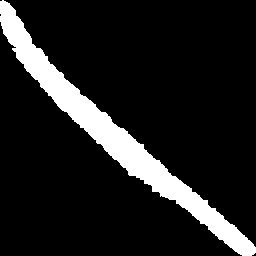
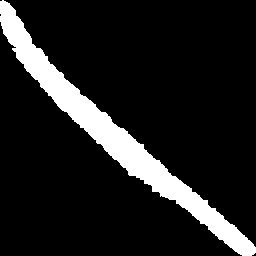
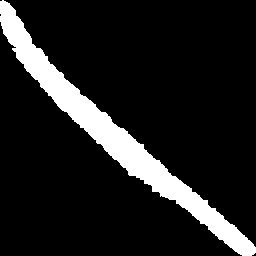
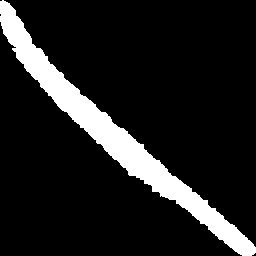
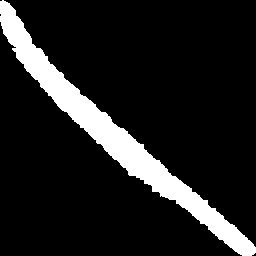
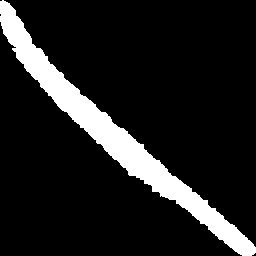
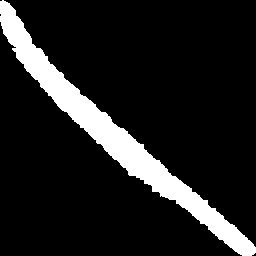
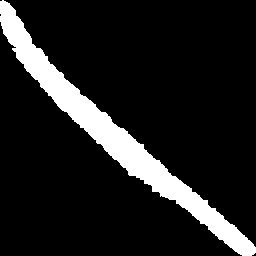
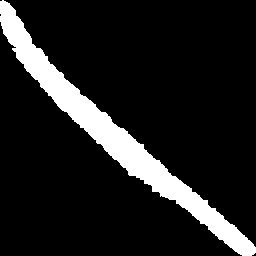
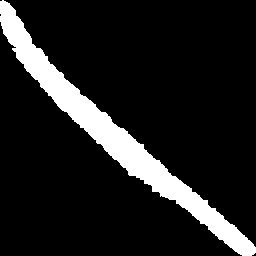
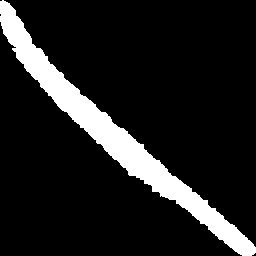
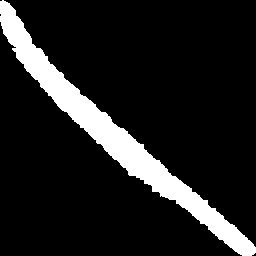
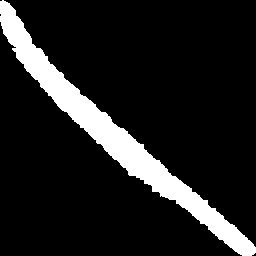
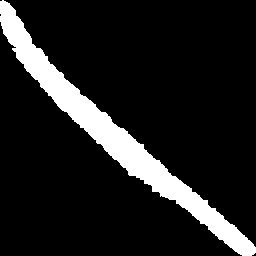
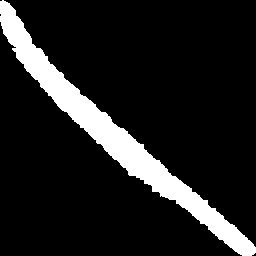
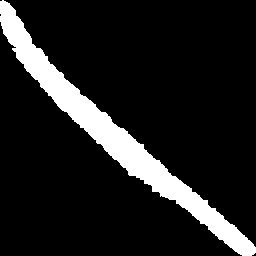
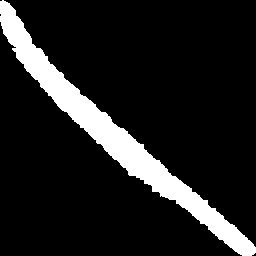
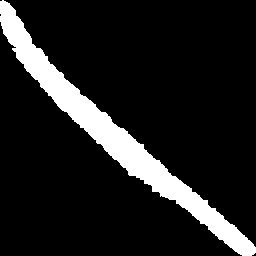
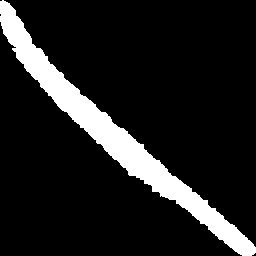
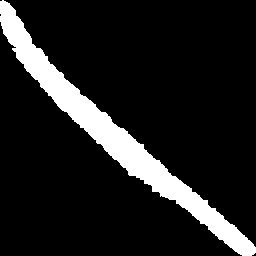
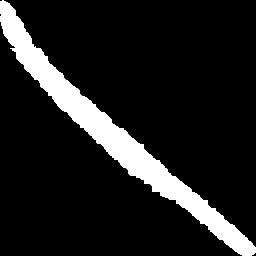
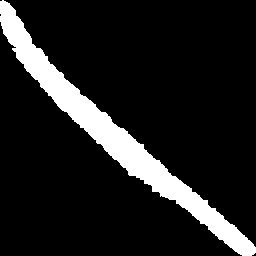
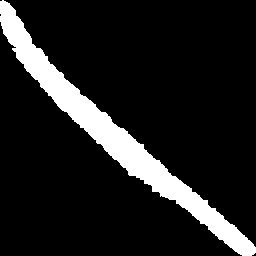
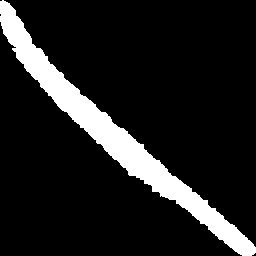
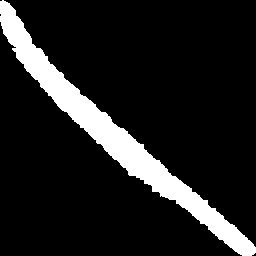
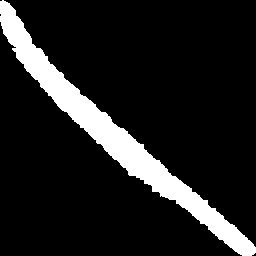
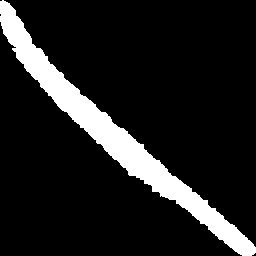
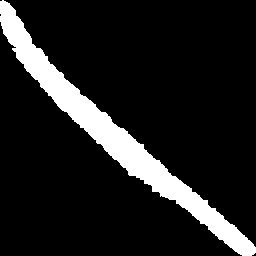
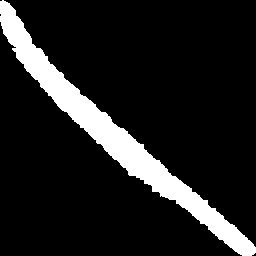
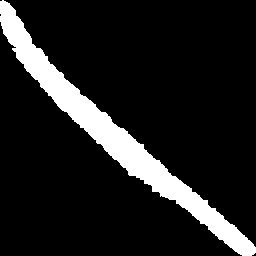
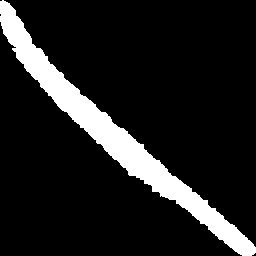
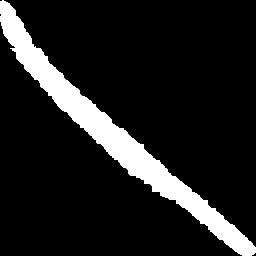
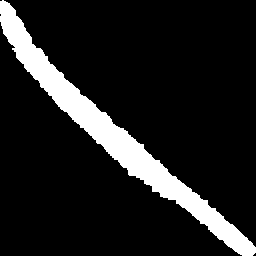
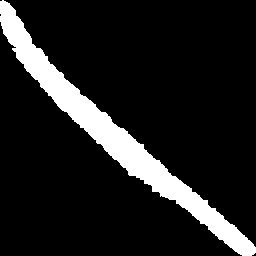
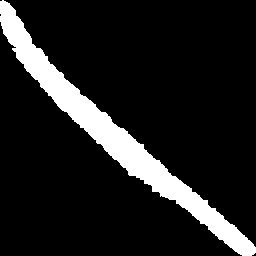
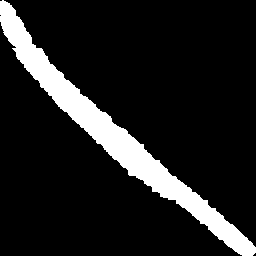
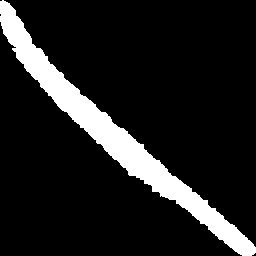
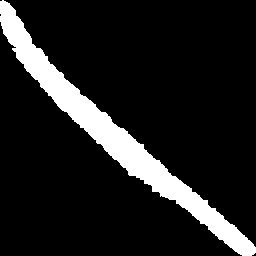
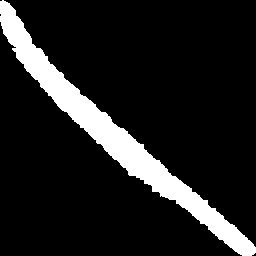
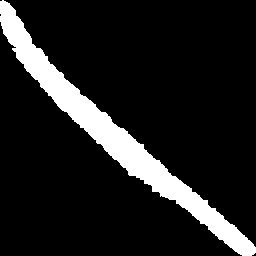
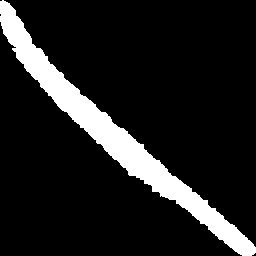
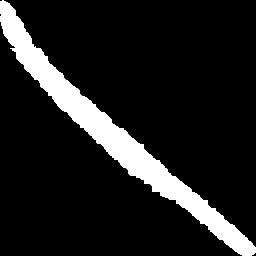
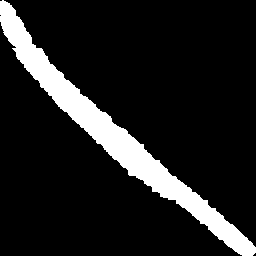
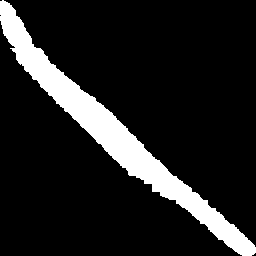
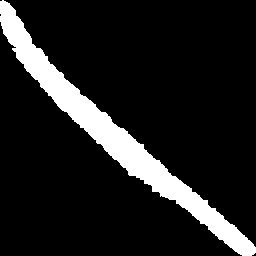
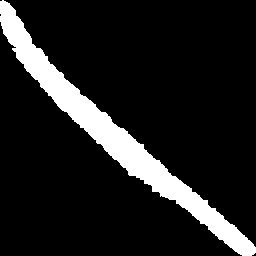
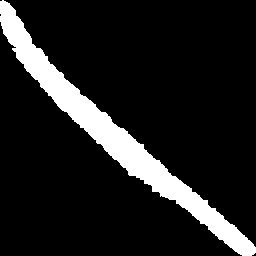
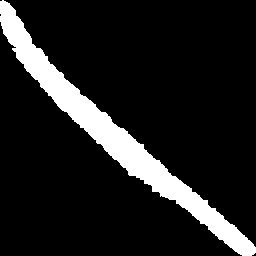
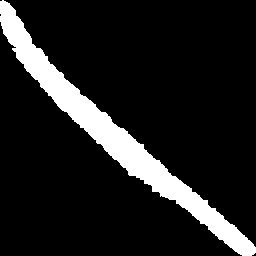
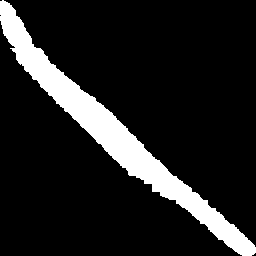
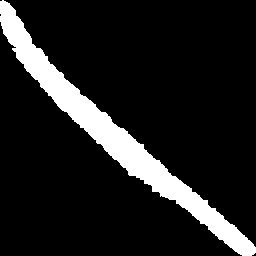
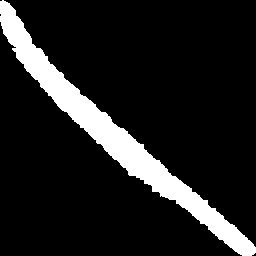
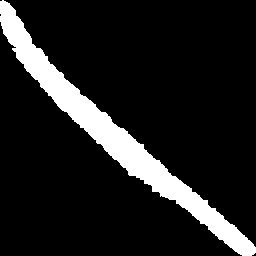
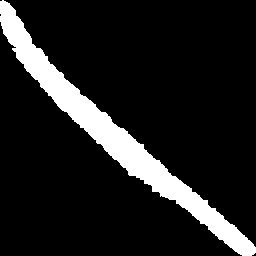
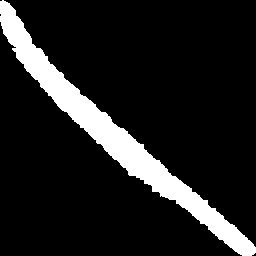
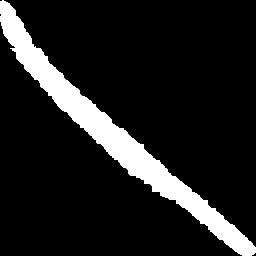
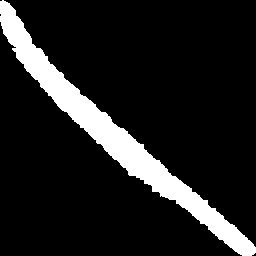
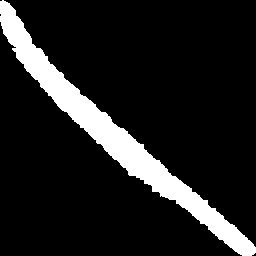
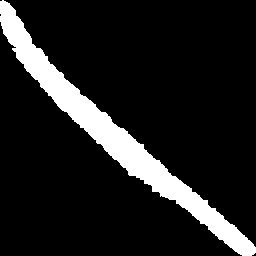
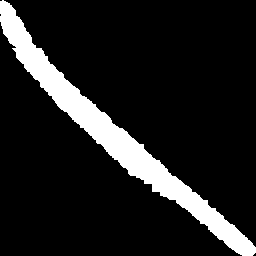
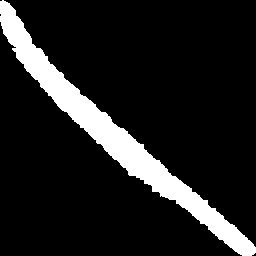
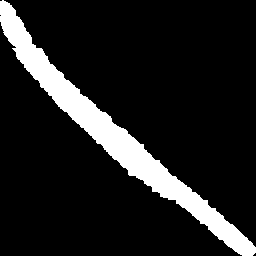
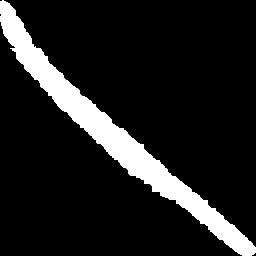
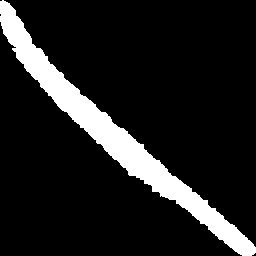
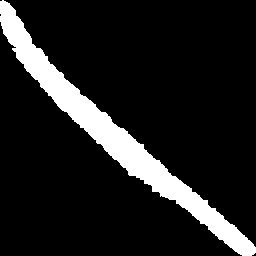
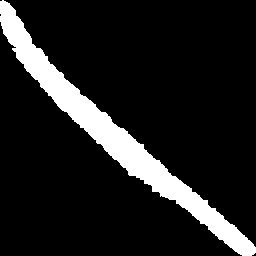
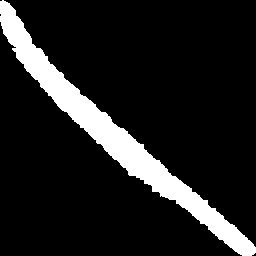
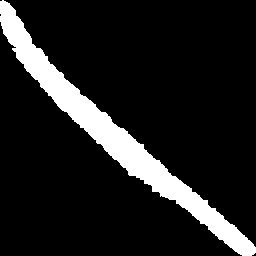
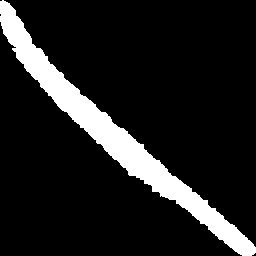
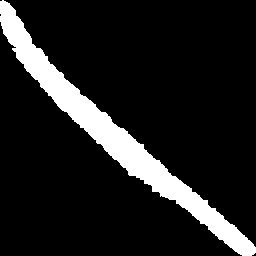
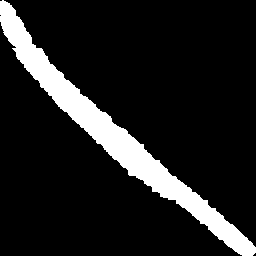
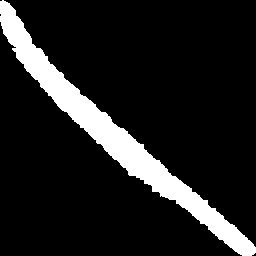
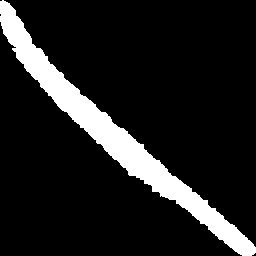
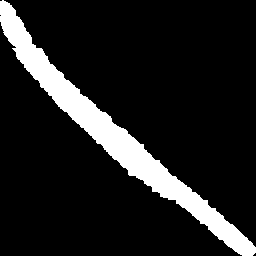
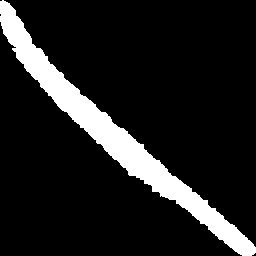
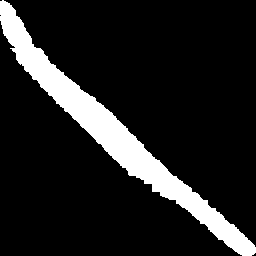
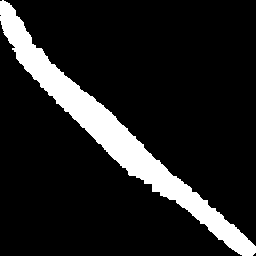
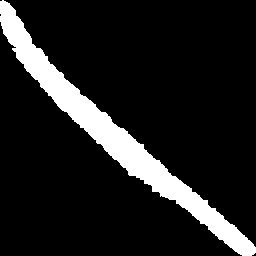
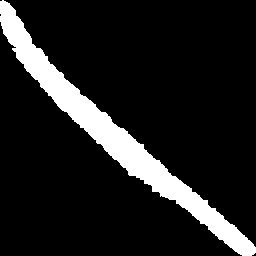
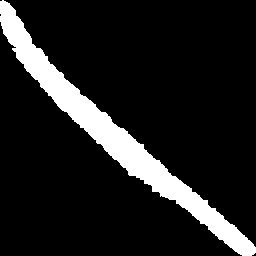
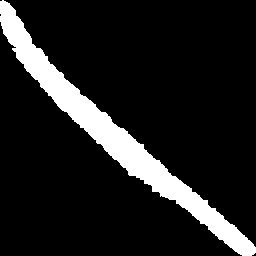
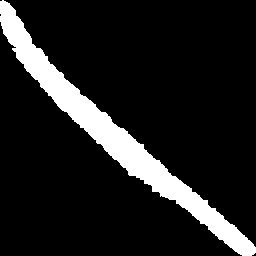
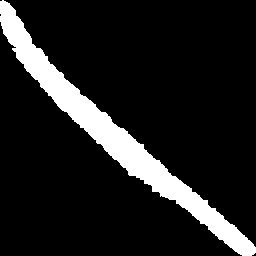
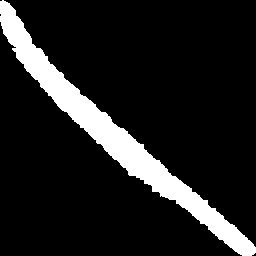
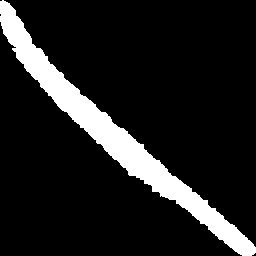
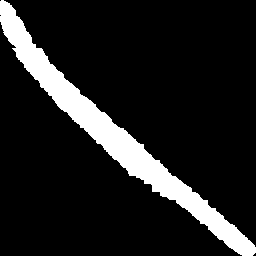
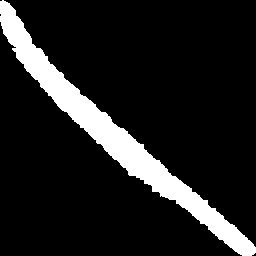
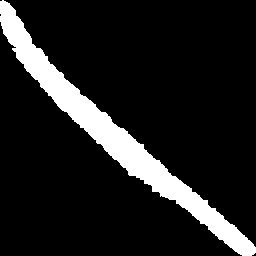
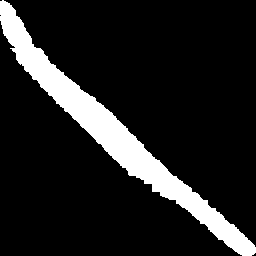
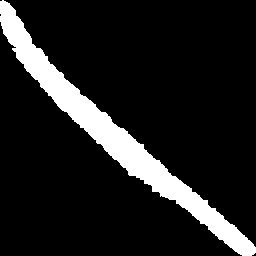
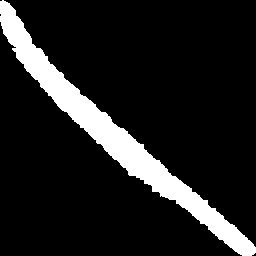
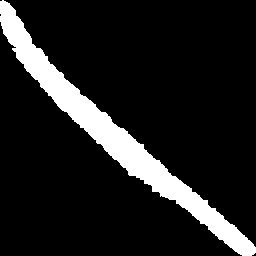
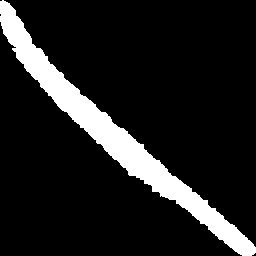
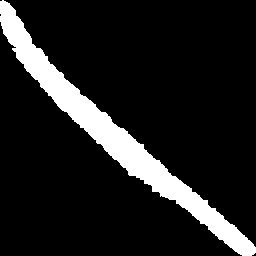
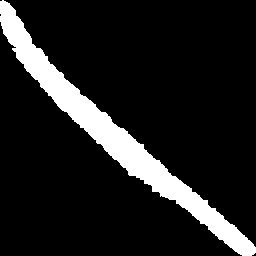
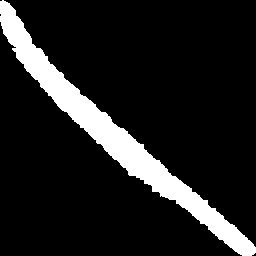
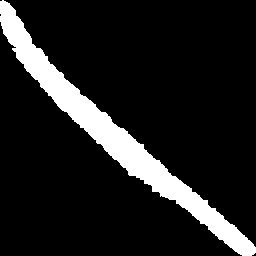
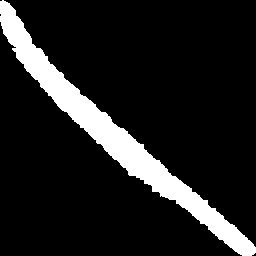
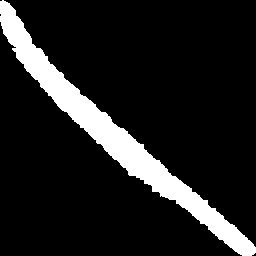
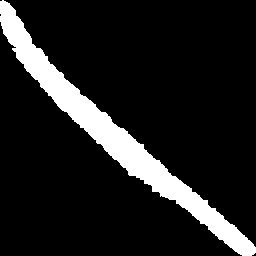
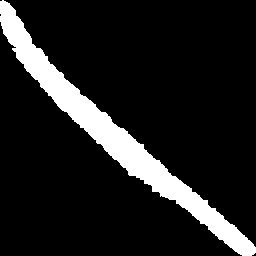
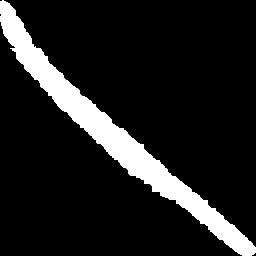
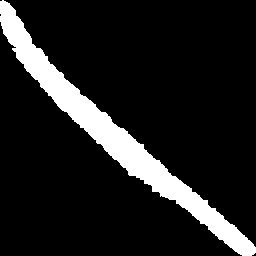
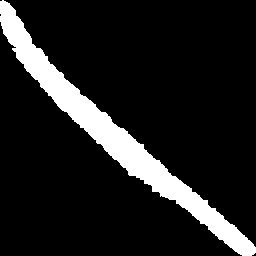
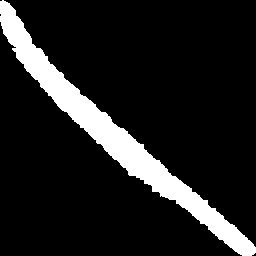
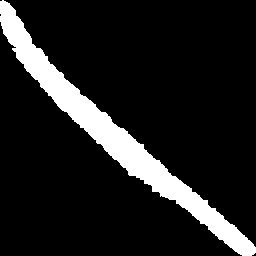
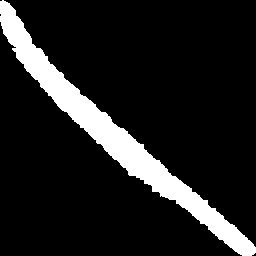
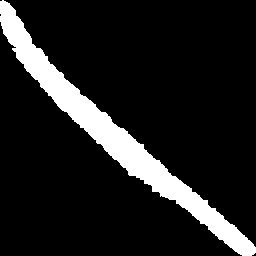
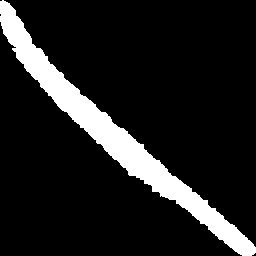
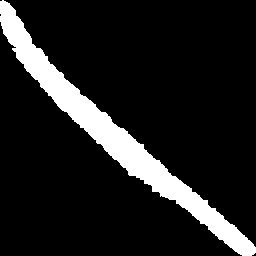
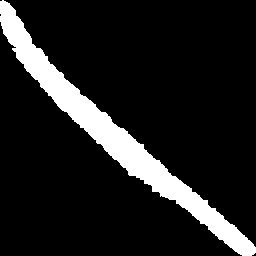
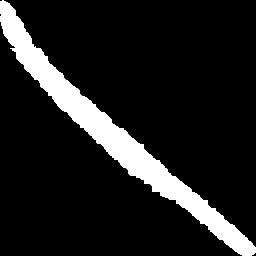
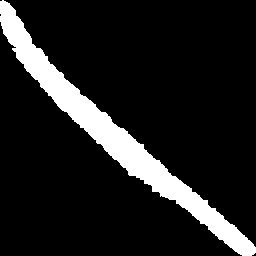
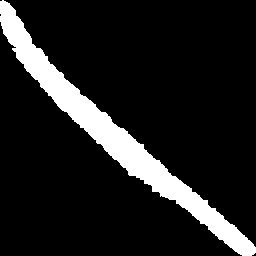
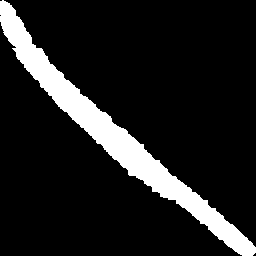
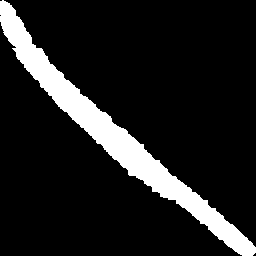
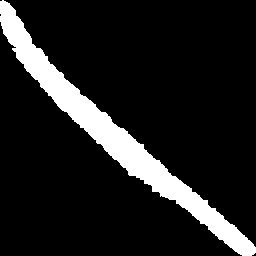
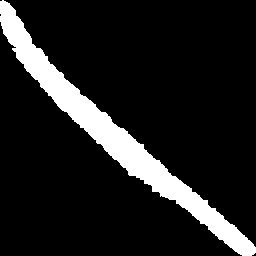
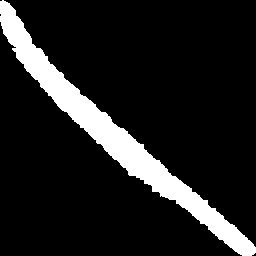
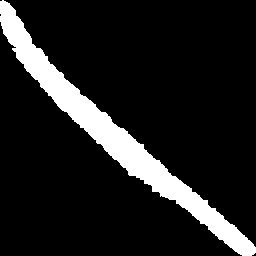
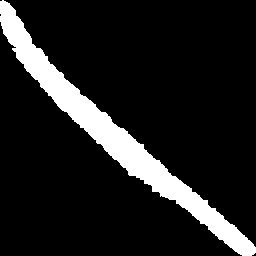
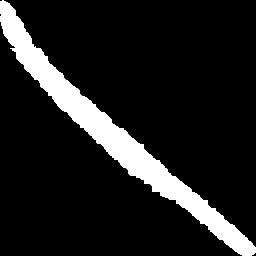
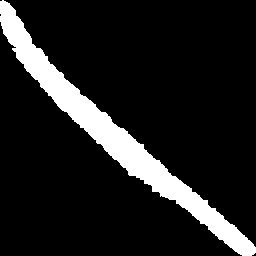
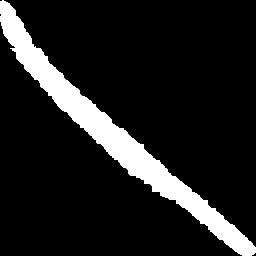
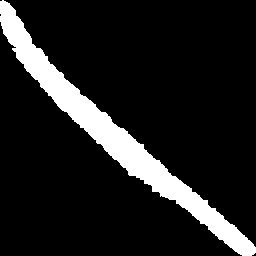
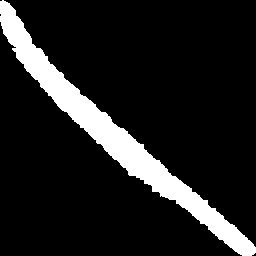
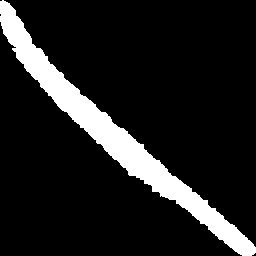
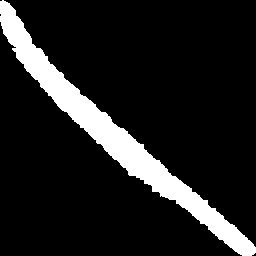
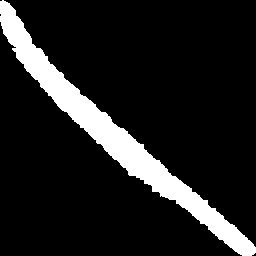
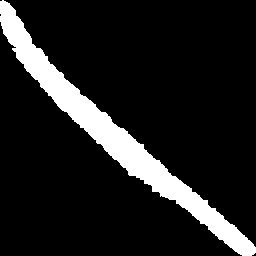
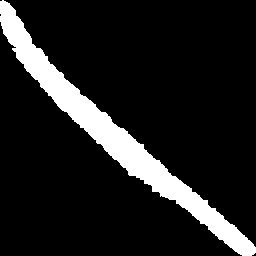
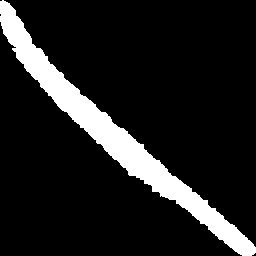
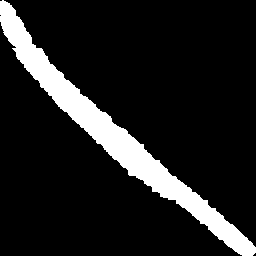
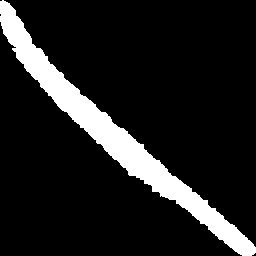
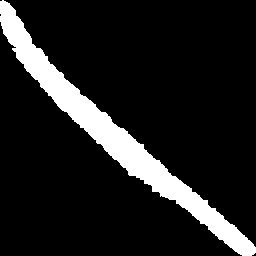
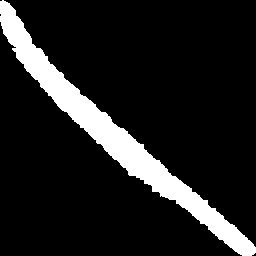
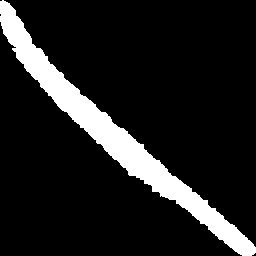
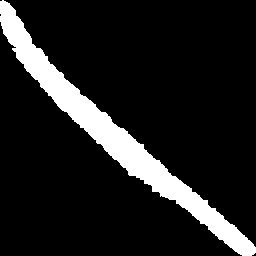
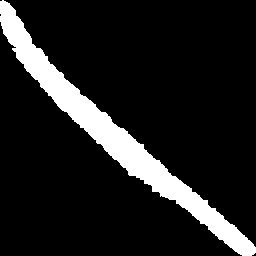
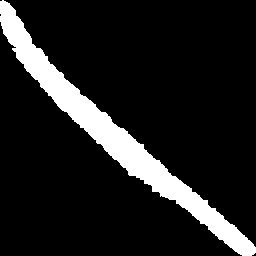
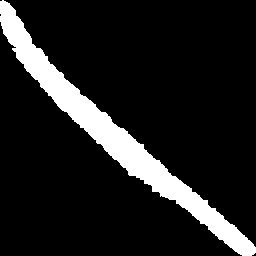
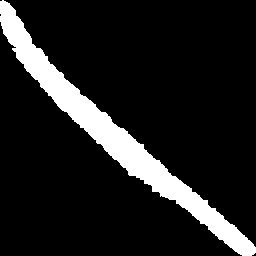
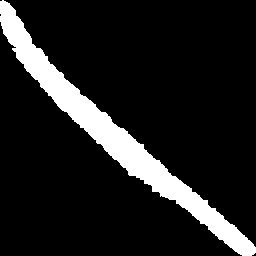
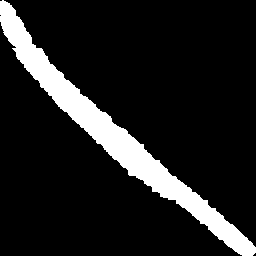
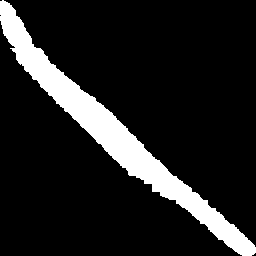
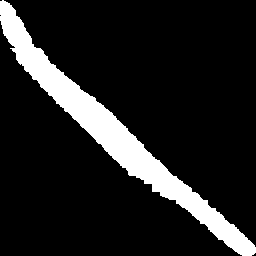
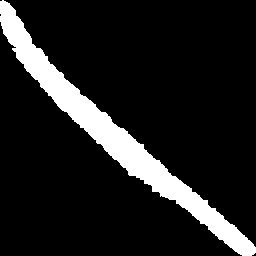
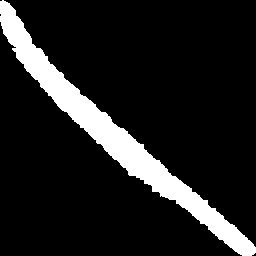
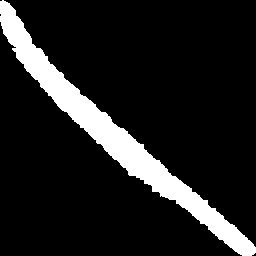
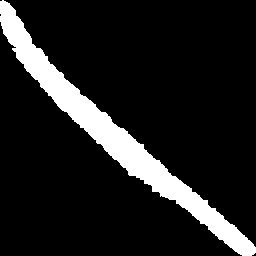
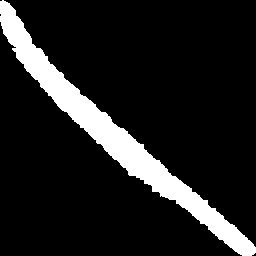
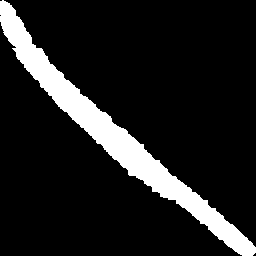
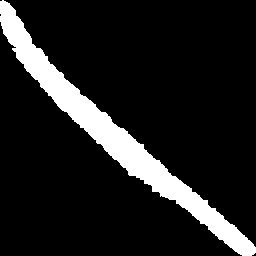
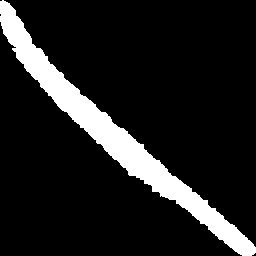
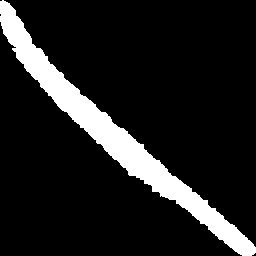
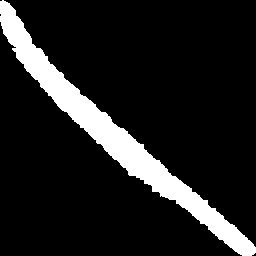
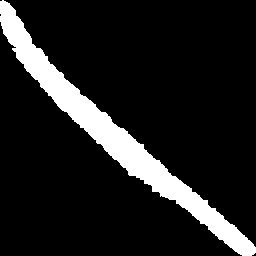
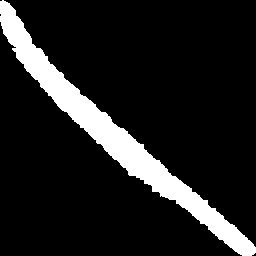
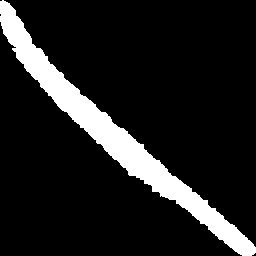
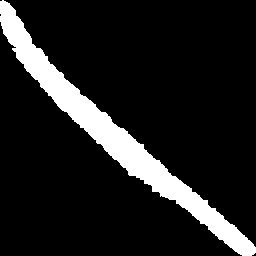
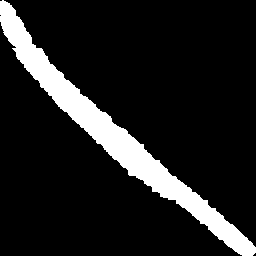
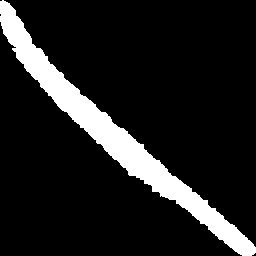
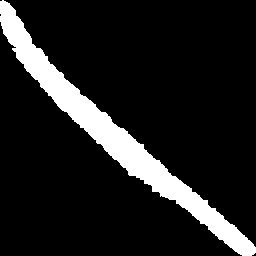
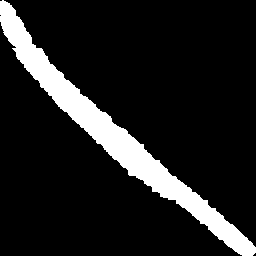
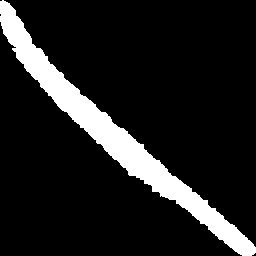
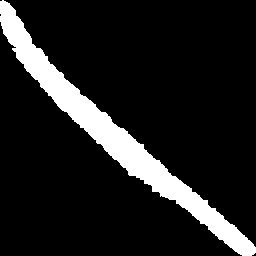
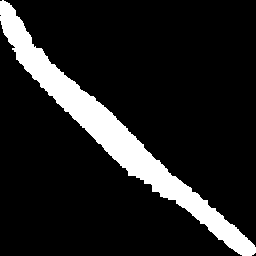
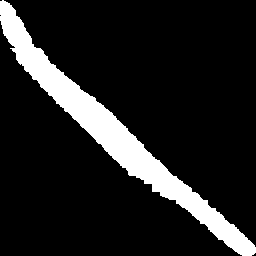
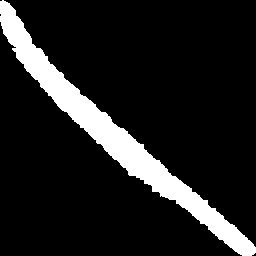
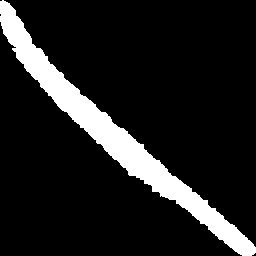
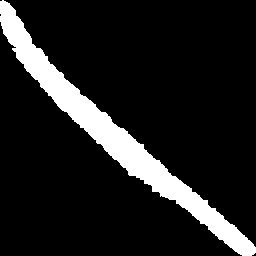
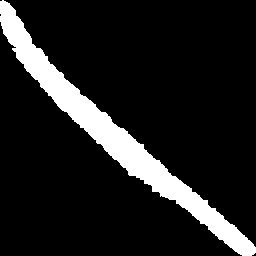
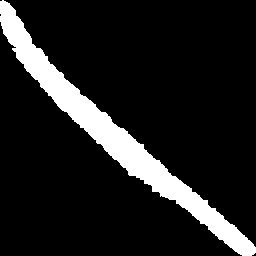
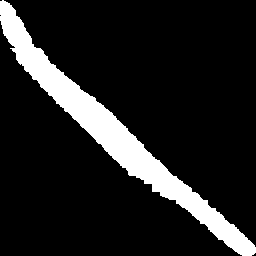
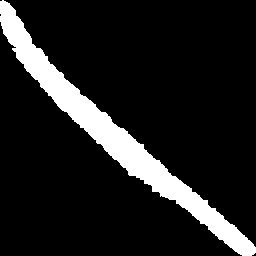
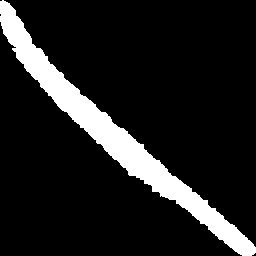
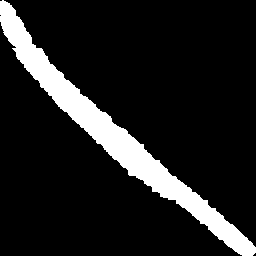
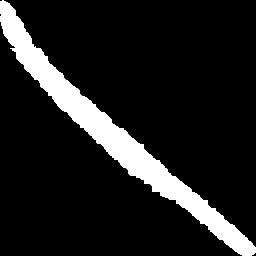
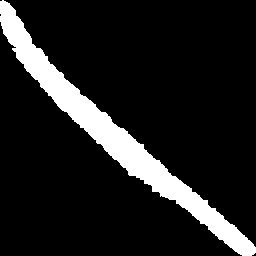
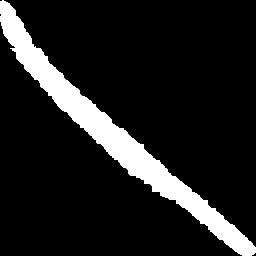
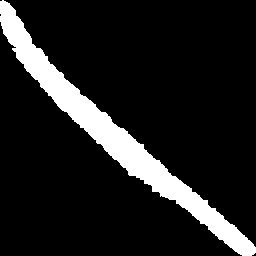
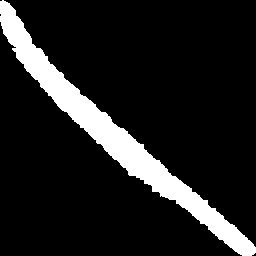
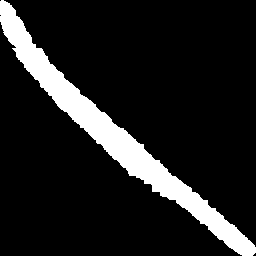
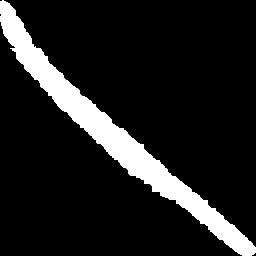
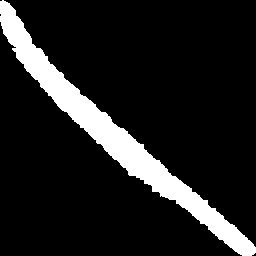
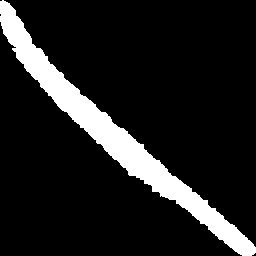
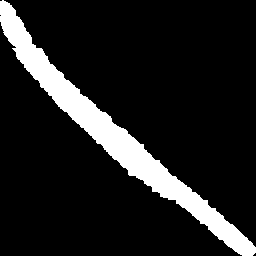
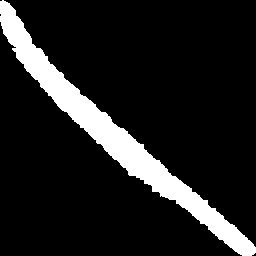
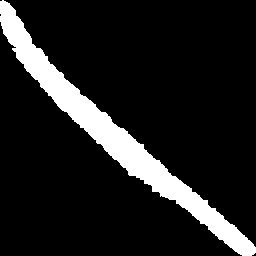
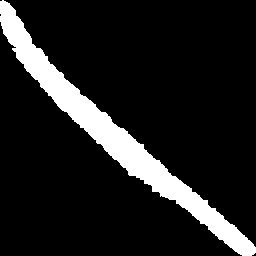
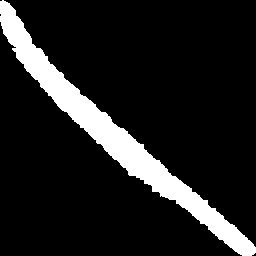
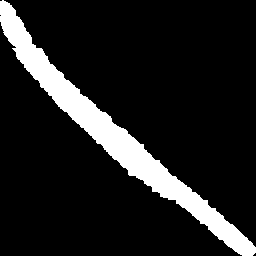
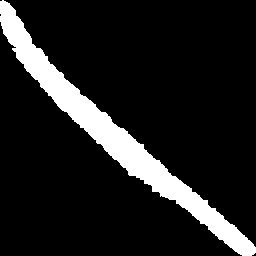
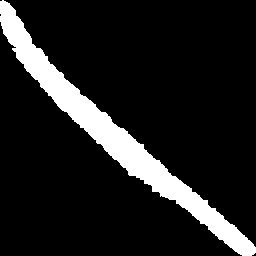
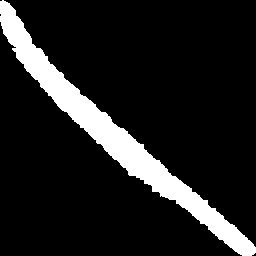
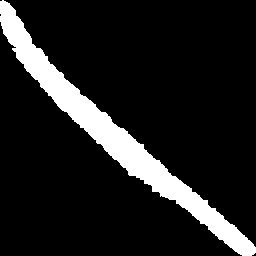
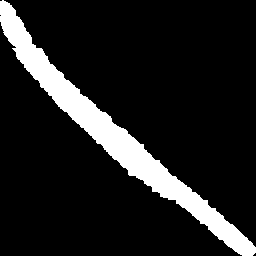
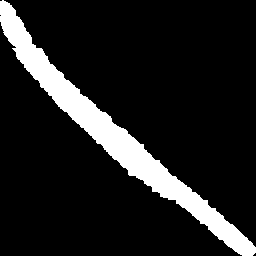
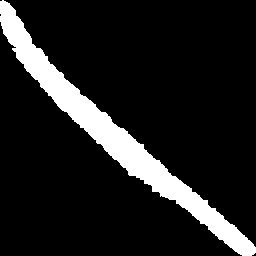
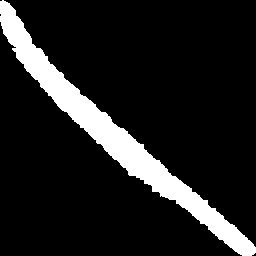
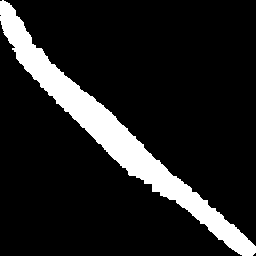
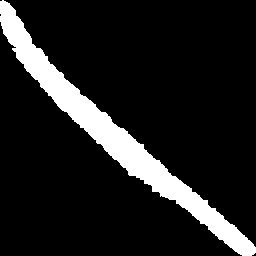
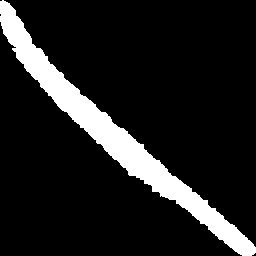
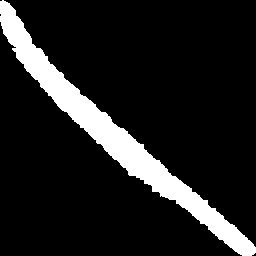
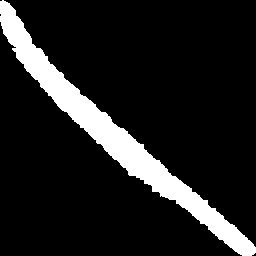
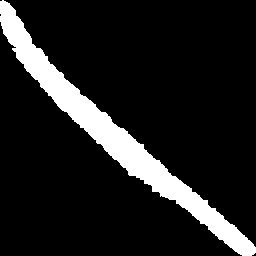
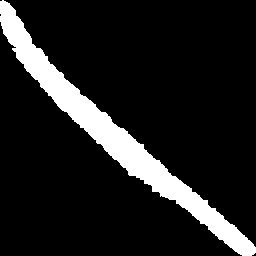
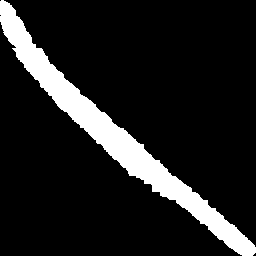
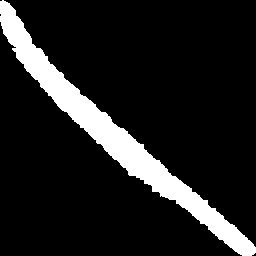
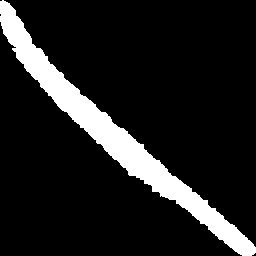
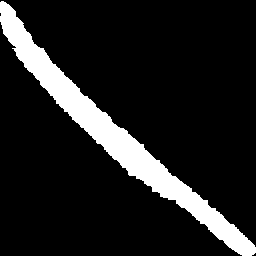
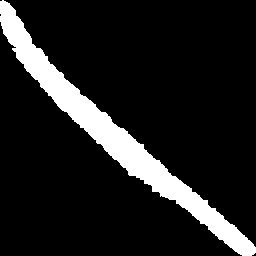
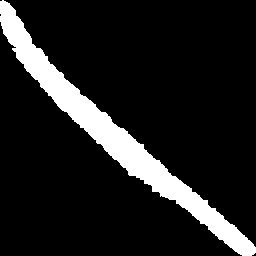
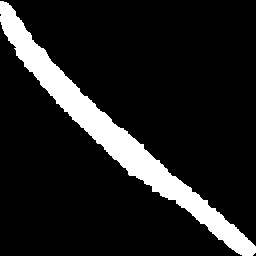
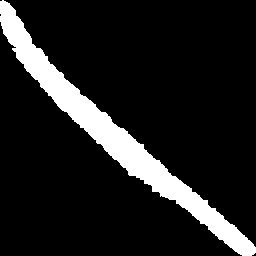
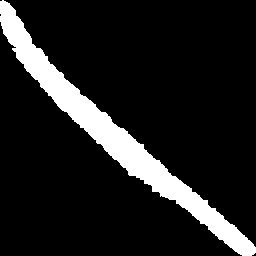
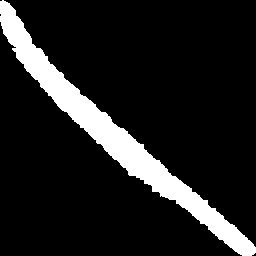
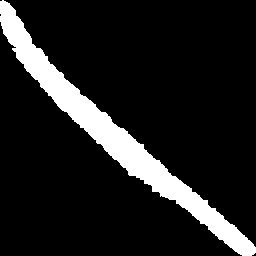
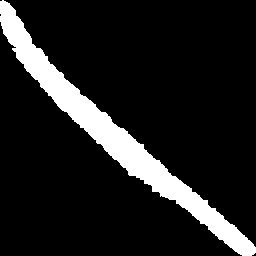
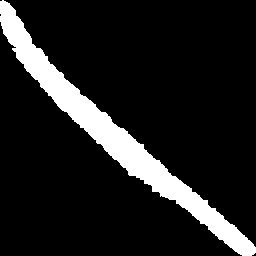
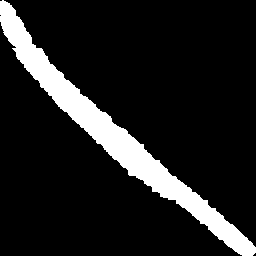
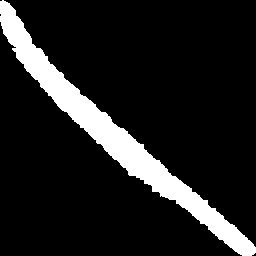
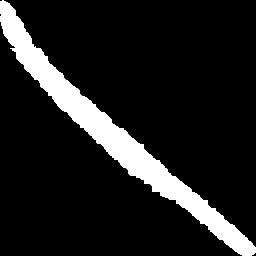
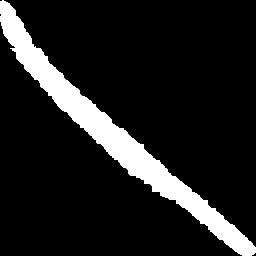
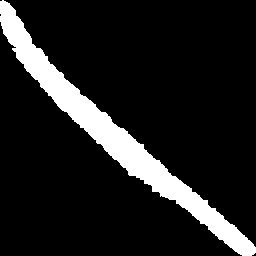
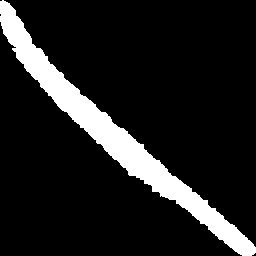
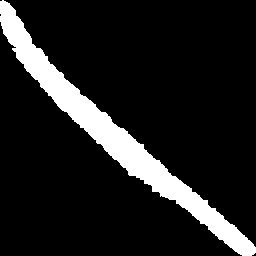
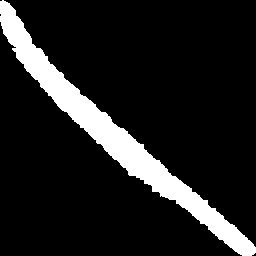
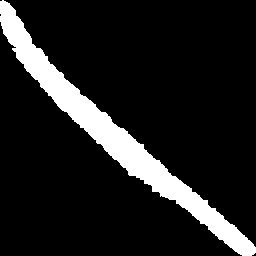
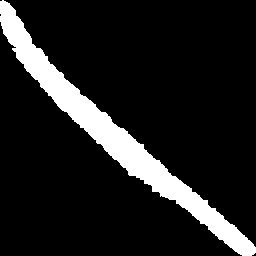
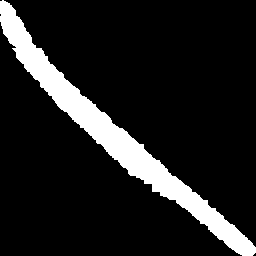
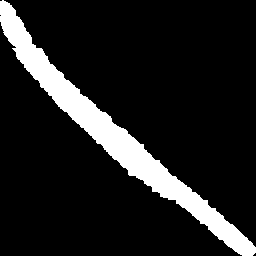
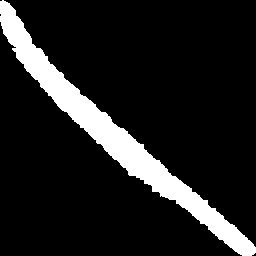
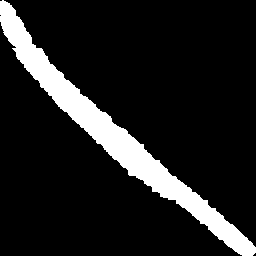
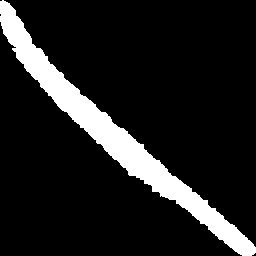
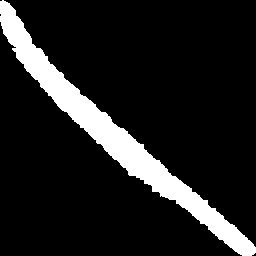
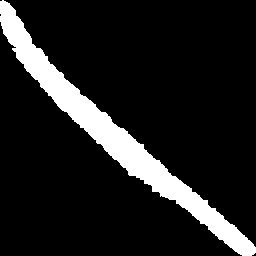
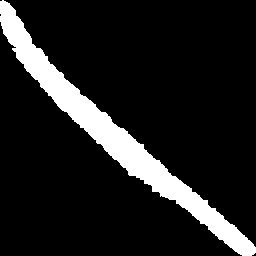
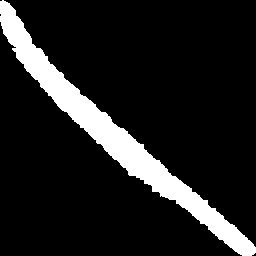
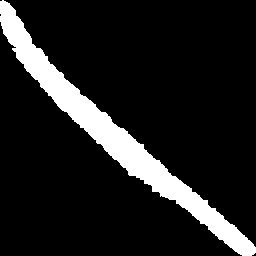
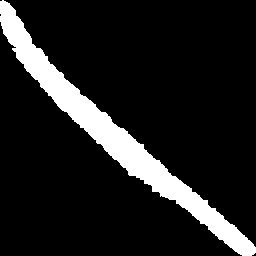
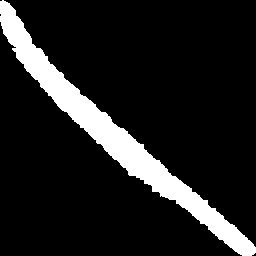
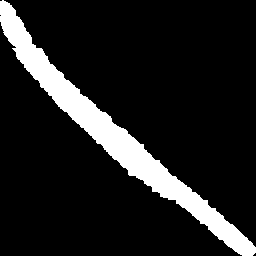
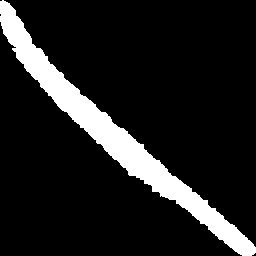
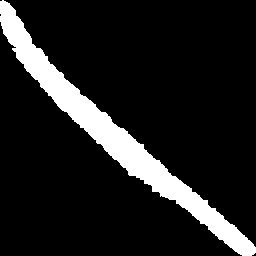
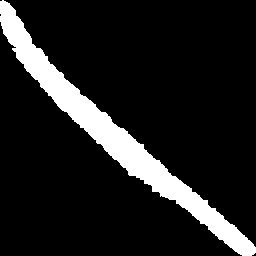
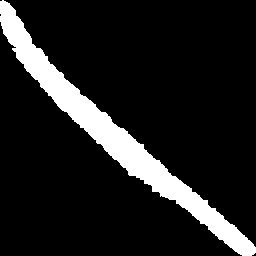
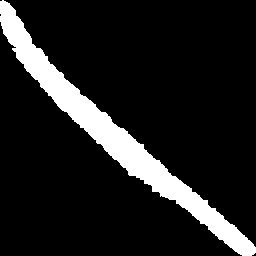
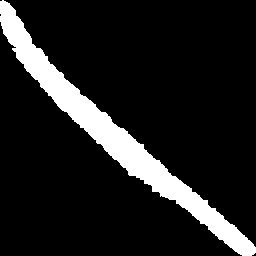
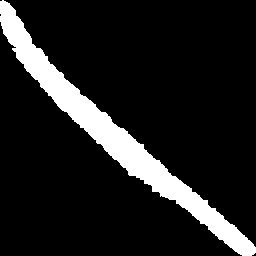
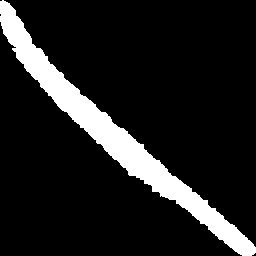
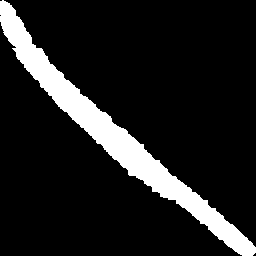
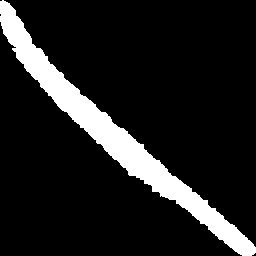
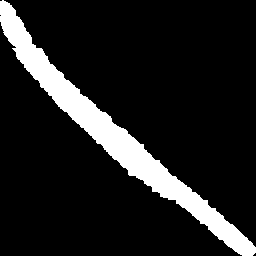
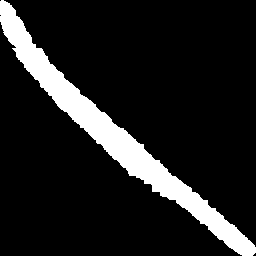
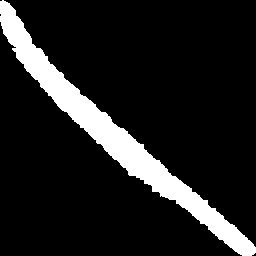
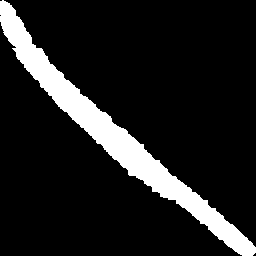
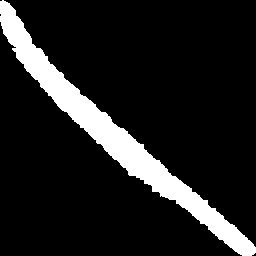
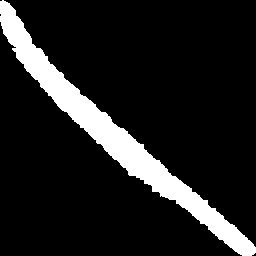
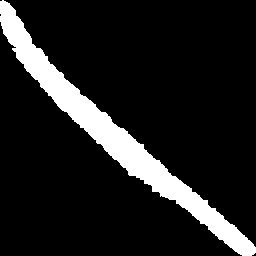
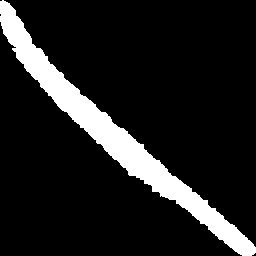
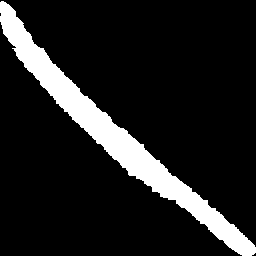
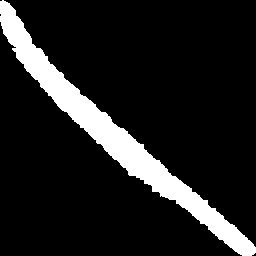
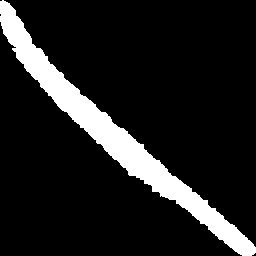
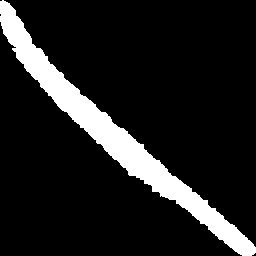
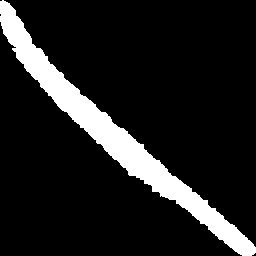
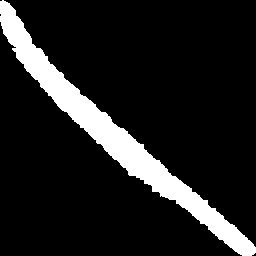
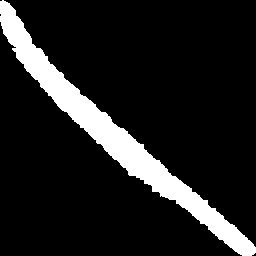
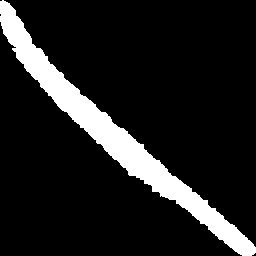
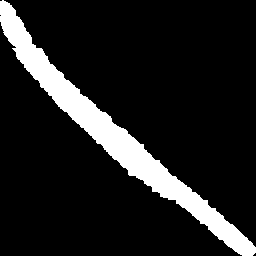
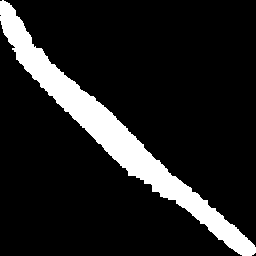

---------------------------------------------
           GenAI Segmentation Evaluation Report: gemini-2.5-flash on ISIC 2017
---------------------------------------------
Total Images Evaluated: 4074 (2750 successfully from cache)
IoU Threshold for Success: 0.5
Exclude Low IoU from Stats: True

--- Performance Metrics ---
Mean IoU (Lesion):    0.8021 (95% CI: 0.7984 - 0.8062) on 3155 images
Mean Dice (Lesion):   0.8856 (95% CI: 0.8830 - 0.8882)

--- Operational Metrics ---
Mean API Latency:     3.04s (95% CI: 2.04s - 4.17s) for 1298 API calls
JSON Parse Success:   99.0%

--- Failure Analysis (based on full dataset) ---
JSON Failures:            41 (1.0%)
False Negatives (Lesion): 93 (2.3%)
Low IoU (Lesion):         785 (19.3%)
---------------------------------------------


2025-08-04 02:08:33 — INFO — Saved high-resolution IoU plot to D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\iou_distribution_isic_gemini-2.5-flash.png


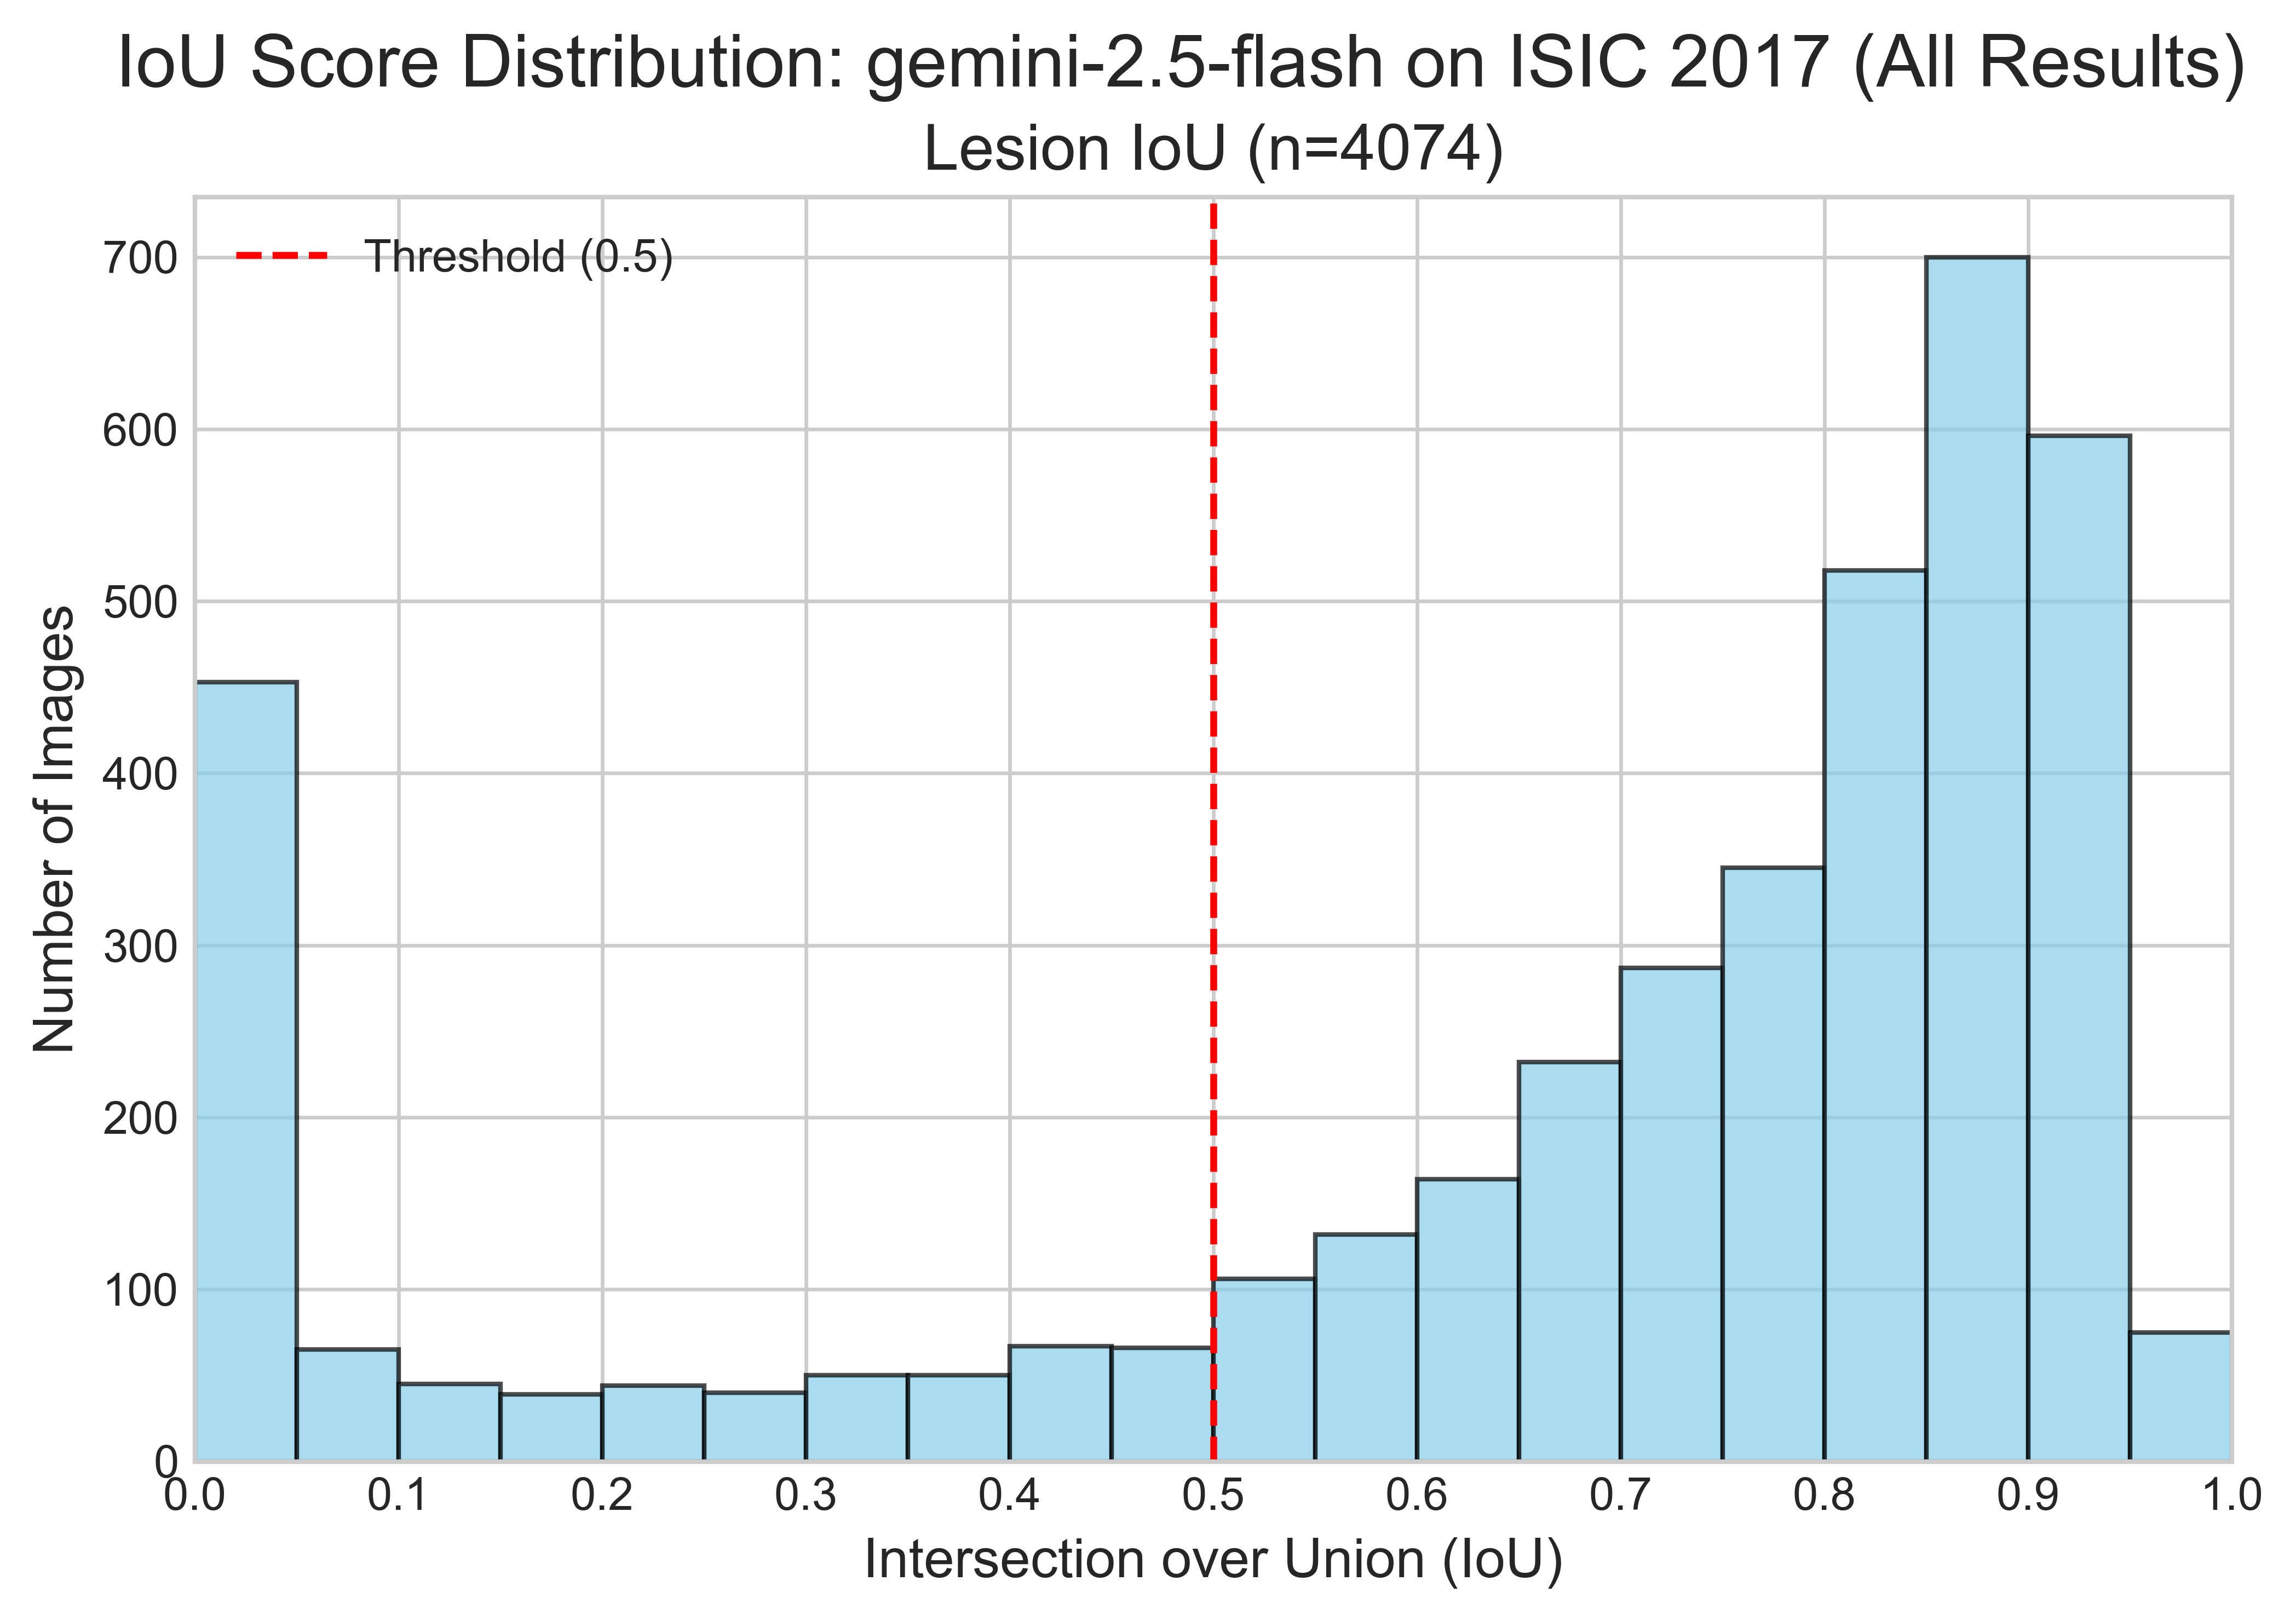

"\n✅ Evaluation complete. The report above summarizes the model's performance on the ISIC 2017 dataset.\n"

In [3]:
# %% [markdown]
"""
# 04 Model Evaluation · **ISIC 2017 Skin Lesion Segmentation**

*Last sync 04 Aug 2025*

This notebook evaluates the performance of the `gemini_seg` function for segmenting skin
lesions from the ISIC 2017 dataset. It systematically calculates and aggregates key
performance metrics by comparing the model's output against ground-truth data.

**Key Features (Adapted for ISIC 2017):**
- **Single-Class Evaluation:** Compares the predicted lesion mask against the single ground truth mask.
- **Core Performance Metrics:** Calculates Dice Score and Intersection over Union (IoU).
- **Configurable & Self-Contained:** Automatically generates the master image list and allows for easy configuration of model, test size, and other parameters.
- **Flexible Analysis:** A toggle (`EXCLUDE_LOW_IOU_FROM_STATS`) allows metrics and plots to be generated for either all images or only successful detections.
- **Robust Failure Analysis:** Categorizes and saves lists of failed images (JSON errors, false negatives, low IoU) for detailed review.
- **Bootstrapped Confidence Intervals:** An optional toggle (`ENABLE_BOOTSTRAPPING`) enables the calculation of 95% confidence intervals for all key metrics.
- **Publication-Ready Outputs:** Saves a detailed JSON summary and a high-resolution (600 DPI) plot of the IoU distribution.
- **Robust API Handling:** Includes rate limiting, client-side request timeouts, and prediction caching.

**NEW in this version:**
- **Multithreaded Evaluation:** Uses a `ThreadPoolExecutor` to process both API calls and cache loading concurrently, significantly speeding up the entire evaluation process.
- **Intelligent Prediction Caching:** A new `ENABLE_CACHING` toggle controls whether the script uses existing predictions. If a cached file is corrupt, the script automatically attempts a fresh API call for that image.
- **Pre-Run Dataset Validation:** The script now validates the master image list on every run, checking for duplicates and ensuring all image/mask pairs are valid and exist on disk.
"""

# %%
# ---------- Preamble & Setup ----------
import sys, logging, os, subprocess, importlib.util, json, io, random, base64, dataclasses, time
from datetime import datetime
from pathlib import Path
from typing import Tuple, List, Dict, Optional
from concurrent.futures import ThreadPoolExecutor, TimeoutError, as_completed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageColor, UnidentifiedImageError
from tqdm import tqdm
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Evaluation notebook start.")

# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow", "google-genai", "pandas"):
    _ensure(extra)

# %%
# ---------- GenAI Client & Dataset Paths ----------
load_dotenv(find_dotenv(), override=False)

from google import genai
from google.genai.types import GenerateContentConfig, Part, ThinkingConfig

if not os.getenv("GOOGLE_API_KEY"):
    raise ValueError("GOOGLE_API_KEY not found. Ensure it is in your .env file.")

client = genai.Client()
logging.info("GenAI client initialized.")


# MODIFIED: Point to the ISIC 2017 dataset directory.
dataset_dir = Path("data/ISIC_2017_Part1").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("ISIC 2017 dataset found at %s", dataset_dir)

# %% [markdown]
"""
### Core Functions (Adapted for Single-Class)

This section includes the necessary functions for segmentation and evaluation, adapted for the single-class skin lesion task.

**Key Modifications:**
- **`PROMPT`:** Updated to request segmentation of "the skin lesion."
- **`parse_ground_truth_mask`:** Rewritten to parse the simple binary PNG masks from the ISIC dataset.
- **`gemini_seg`:** Retains its robust error handling and timeout features.
- **`load_prediction_details`:** New function to load cached prediction files.
"""

# %%
# ---------- Core Segmentation & Parsing Logic ----------

@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def parse_json(json_output: str) -> str:
    """Cleans the model's JSON output by removing markdown fencing."""
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line.strip() == "```json":
            json_content = "\n".join(lines[i+1:])
            closing_fence_index = json_content.find("```")
            if closing_fence_index != -1:
                json_content = json_content[:closing_fence_index]
            return json_content.strip()
    return json_output.strip()

def parse_segmentation_masks(
    predicted_str: str, *, img_height: int, img_width: int
) -> Tuple[List[SegmentationMask], bool]:
    """
    Parses the model's JSON output into a list of SegmentationMask objects.
    Returns the list of masks and a boolean indicating if JSON parsing was successful.
    """
    cleaned_json = parse_json(predicted_str)
    if not cleaned_json:
        logging.warning("Parsing model output resulted in an empty string.")
        return [], True # Technically not a JSON error, but an empty response.

    try:
        items = json.loads(cleaned_json)
        parse_success = True
    except json.JSONDecodeError as e:
        logging.error(f"Failed to decode JSON: {e}")
        logging.error(f"Problematic string after cleaning: {cleaned_json}")
        return [], False

    masks = []
    for item in items:
        try:
            abs_y0 = int(item["box_2d"][0] / 1000 * img_height)
            abs_x0 = int(item["box_2d"][1] / 1000 * img_width)
            abs_y1 = int(item["box_2d"][2] / 1000 * img_height)
            abs_x1 = int(item["box_2d"][3] / 1000 * img_width)

            if abs_y0 >= abs_y1 or abs_x0 >= abs_x1:
                continue

            label = item["label"].lower() # Standardize label to lowercase
            png_b64_str = item["mask"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            partial_mask_img = Image.open(io.BytesIO(png_bytes))

            bbox_height = abs_y1 - abs_y0
            bbox_width = abs_x1 - abs_x0
            resized_mask = partial_mask_img.resize((bbox_width, bbox_height), resample=Image.Resampling.BILINEAR)
            full_mask_np = np.zeros((img_height, img_width), dtype=np.uint8)
            full_mask_np[abs_y0:abs_y1, abs_x0:abs_x1] = np.array(resized_mask)

            masks.append(SegmentationMask(abs_y0, abs_x0, abs_y1, abs_x1, full_mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in JSON response: {item}. Error: {e}")
            continue
    return masks, parse_success

def parse_ground_truth_mask(mask_path: Path) -> list[SegmentationMask]:
    """
    Parses an ISIC 2017 ground truth PNG file into a single SegmentationMask for the lesion.
    The mask is a single-channel binary image (0 for background, 255 for lesion).
    """
    try:
        mask_img = Image.open(mask_path).convert("L") # Ensure single channel grayscale
        mask_data = np.array(mask_img)
    except (FileNotFoundError, UnidentifiedImageError) as e:
        logging.error("Could not read ground truth mask file %s: %s", mask_path, e)
        return []

    binary_mask_data = mask_data > 127 # Create a boolean mask

    if not np.any(binary_mask_data):
        return []

    rows, cols = np.where(binary_mask_data)
    y0, y1 = rows.min(), rows.max()
    x0, x1 = cols.min(), cols.max()
    full_mask_np = binary_mask_data.astype(np.uint8) * 255
    # The label is consistently "lesion" for this single-class task.
    return [SegmentationMask(y0, x0, y1, x1, full_mask_np, "lesion")]


# MODIFIED: Prompt updated for skin lesion segmentation.
PROMPT = (
    'Give the segmentation masks for all skin lesions. '
    'Output a JSON list of segmentation masks where each entry contains the 2D bounding box in the key "box_2d", '
    'the segmentation mask in key "mask", and the text label in the key "label". '
)

def gemini_seg(image_obj: Image.Image, model_name: str, thinking_budget: int) -> Tuple[List[SegmentationMask], float, bool]:
    """
    Sends a PIL Image object to Gemini and returns segmentation masks, with a client-side timeout.
    """
    original_width, original_height = image_obj.size
    
    img_for_api = image_obj.copy()
    max_dim = 1024
    if img_for_api.height > max_dim or img_for_api.width > max_dim:
        img_for_api.thumbnail((max_dim, max_dim))

    with io.BytesIO() as img_byte_arr:
        img_for_api.save(img_byte_arr, format='JPEG')
        img_bytes = img_byte_arr.getvalue()

    gen_config = GenerateContentConfig(
        thinking_config=ThinkingConfig(thinking_budget=thinking_budget),
        temperature=0.5
    )
    image_part = Part.from_bytes(data=img_bytes, mime_type='image/jpeg')
    text_part = Part(text=PROMPT)
    
    def do_api_call():
        return client.models.generate_content(
            model=model_name, contents=[image_part, text_part], config=gen_config
        )

    start_time = datetime.now()
    try:
        if ENABLE_REQUEST_TIMEOUT:
            with ThreadPoolExecutor(max_workers=1) as executor:
                future = executor.submit(do_api_call)
                response = future.result(timeout=REQUEST_TIMEOUT_SEC)
        else:
            response = do_api_call()
        
        latency = (datetime.now() - start_time).total_seconds()
        masks, parse_success = parse_segmentation_masks(
            response.text, img_height=original_height, img_width=original_width
        )
        return masks, latency, parse_success

    except TimeoutError:
        logging.error(f"API call timed out after {REQUEST_TIMEOUT_SEC} seconds.")
        return [], 0.0, False
    except Exception as e:
        logging.error(f"An error occurred during the gemini_seg function.", exc_info=True)
        return [], 0.0, False

def save_prediction_details(masks: List[SegmentationMask], output_path: Path):
    """Saves the detailed contents of SegmentationMask objects to a JSON file."""
    if not masks:
        output_path.write_text(json.dumps([]))
        return

    results_to_save = []
    for mask_obj in masks:
        pil_img = Image.fromarray(mask_obj.mask)
        with io.BytesIO() as buffer:
            pil_img.save(buffer, format="PNG")
            png_bytes = buffer.getvalue()
        b64_string = base64.b64encode(png_bytes).decode('utf-8')
        results_to_save.append({
            "label": mask_obj.label,
            "box_2d_absolute": [mask_obj.y0, mask_obj.x0, mask_obj.y1, mask_obj.x1],
            "mask_b64": f"data:image/png;base64,{b64_string}"
        })
    with open(output_path, 'w') as f:
        json.dump(results_to_save, f, indent=2)

def load_prediction_details(prediction_path: Path, img_height: int, img_width: int) -> Tuple[List[SegmentationMask], bool]:
    """Loads and parses a cached prediction JSON file."""
    try:
        with open(prediction_path, 'r') as f:
            items = json.load(f)
        
        masks = []
        for item in items:
            y0, x0, y1, x1 = item["box_2d_absolute"]
            b64_string = item["mask_b64"].removeprefix("data:image/png;base64,")
            png_bytes = base64.b64decode(b64_string)
            mask_img = Image.open(io.BytesIO(png_bytes))
            full_mask_np = np.array(mask_img)
            
            # Ensure mask is the correct size, pad if necessary
            if full_mask_np.shape != (img_height, img_width):
                 padded_mask = np.zeros((img_height, img_width), dtype=np.uint8)
                 h, w = full_mask_np.shape
                 padded_mask[y0:y0+h, x0:x0+w] = full_mask_np
                 full_mask_np = padded_mask

            masks.append(SegmentationMask(y0, x0, y1, x1, full_mask_np, item["label"]))
        return masks, True # Return masks and parse_success=True
    except (Exception) as e:
        logging.error(f"Failed to load or parse cached prediction {prediction_path}: {e}")
        return [], False


# %% [markdown]
"""
### Metric Calculation Utilities

These functions implement the formulas for Intersection over Union (IoU), the Dice Coefficient, and bootstrapping for confidence intervals. The clinical vCDR metric has been removed as it is not applicable to this task.
"""

# %%
# ---------- Metric Calculation Functions ----------

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 1.0
    return np.sum(intersection) / np.sum(union)

def calculate_dice(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates the Dice Coefficient for boolean masks."""
    intersection = np.sum(np.logical_and(y_true, y_pred))
    denominator = np.sum(y_true) + np.sum(y_pred)
    if denominator == 0: return 1.0
    return (2. * intersection) / (denominator + 1e-7)

def calculate_bootstrap_ci(data: List[float], n_resamples: int = 1000) -> Tuple[float, float]:
    """Calculates the 95% confidence interval for a list of numbers using bootstrapping."""
    if not data or len(data) < 2: return 0.0, 0.0
    bootstrapped_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_resamples)]
    return np.percentile(bootstrapped_means, 2.5), np.percentile(bootstrapped_means, 97.5)

# %% [markdown]
"""
### Evaluation Execution

This is the main execution block. It will:
1.  **Validate Dataset:** Check the master list for duplicates and ensure all image/mask pairs exist.
2.  **Check Cache:** If enabled, identify images that already have a saved prediction and separate them from images that need API calls.
3.  **Process Images:** Use a `ThreadPoolExecutor` to run both API calls and cache loading concurrently. If a cached result fails to load, it will be re-processed via the API.
4.  **Aggregate Results:** Collect all results and failures for the final report.
"""

# %%
# ---------- Main Evaluation Block ----------

# <<< --- PARAMETERS TO CONTROL THE EVALUATION --- >>>
MODEL_NAME = "gemini-2.5-flash"
THINKING_BUDGET = 0
NUM_IMAGES_TO_TEST = 0 # Set to None or 0 to test all images
MAX_WORKERS = 10 # Number of concurrent threads for evaluation
SAVE_PREDICTIONS = True
ENABLE_CACHING = True # Set to False to ignore existing predictions and re-run all API calls.
ENABLE_BOOTSTRAPPING = True
ENABLE_RATE_LIMITING = False
RATE_LIMIT_DELAY_SEC = 9
ENABLE_REQUEST_TIMEOUT = True
REQUEST_TIMEOUT_SEC = 300
LOW_IOU_THRESHOLD = 0.5
EXCLUDE_LOW_IOU_FROM_STATS = True # If True, stats only use runs with IoU >= threshold. If False, all runs are used. Plots always plot all runs.

model_name_safe = MODEL_NAME.replace("/", "_")
logging.info(f"Starting evaluation run for model: {MODEL_NAME} on ISIC 2017 dataset.")

# --- Define direct paths to subdirectories ---
image_dir = dataset_dir / "image"
mask_dir = dataset_dir / "mask"

# --- Generate Master Image List if it Doesn't Exist ---
master_list_path = dataset_dir / "master_imagelist_isic.txt"
if not master_list_path.exists():
    logging.info(f"Master image list not found. Generating it now at: {master_list_path}")
    image_paths = sorted(image_dir.glob("*.jpg"))
    valid_pairs = []
    seen_stems = set()
    for img_path in image_paths:
        if img_path.stem in seen_stems:
            logging.warning(f"Duplicate image stem found and skipped: {img_path.stem}")
            continue
        mask_path = mask_dir / f"{img_path.stem}_Segmentation.png"
        if mask_path.exists():
            valid_pairs.append(img_path)
            seen_stems.add(img_path.stem)
    
    if not valid_pairs:
        raise RuntimeError("No valid image-mask pairs found in the dataset directories.")
    master_list_path.write_text("\n".join(str(p) for p in valid_pairs))
    logging.info(f"Successfully generated master list with {len(valid_pairs)} images.")

# --- Create Model-Specific Predictions Directory ---
if SAVE_PREDICTIONS:
    predictions_dir = dataset_dir / f"predictions_{model_name_safe}"
    predictions_dir.mkdir(exist_ok=True)
    logging.info(f"Detailed predictions will be saved to: {predictions_dir}")
else:
    predictions_dir = None

# --- Pre-Run Validation Step ---
logging.info("--- Starting Pre-Run Validation ---")
with open(master_list_path, 'r') as f:
    all_paths_from_file = [line.strip() for line in f.readlines() if line.strip()]
initial_count = len(all_paths_from_file)
unique_paths_str = sorted(list(set(all_paths_from_file)))
unique_count = len(unique_paths_str)
if initial_count != unique_count:
    logging.warning(f"Removed {initial_count - unique_count} duplicate entries from master list.")

validated_image_paths = []
for p_str in unique_paths_str:
    img_path = Path(p_str)
    mask_path = mask_dir / f"{img_path.stem}_Segmentation.png"
    if img_path.exists() and mask_path.exists():
        validated_image_paths.append(img_path)
    else:
        logging.warning(f"Invalid pair, skipping: Img: {img_path.exists()}, Mask: {mask_path.exists()} for {img_path.name}")
logging.info(f"Validation complete. Found {len(validated_image_paths)} unique, valid image-mask pairs.")


# --- Load and Prepare Evaluation Set ---
random.seed(42)
random.shuffle(validated_image_paths)

if NUM_IMAGES_TO_TEST is None or NUM_IMAGES_TO_TEST <= 0:
    images_to_evaluate = validated_image_paths
else:
    images_to_evaluate = validated_image_paths[:min(NUM_IMAGES_TO_TEST, len(validated_image_paths))]
logging.info(f"Full evaluation sample size is {len(images_to_evaluate)} images.")

# --- Pre-check for Cached Predictions ---
images_for_api = []
images_from_cache = []
if ENABLE_CACHING and predictions_dir:
    cached_stems = {f.stem for f in predictions_dir.glob("*.json")}
    for img_path in images_to_evaluate:
        if img_path.stem in cached_stems:
            images_from_cache.append(img_path)
        else:
            images_for_api.append(img_path)
    logging.info(f"Found {len(images_from_cache)} existing predictions in cache.")
    logging.info(f"{len(images_for_api)} new images will be processed via API.")
else:
    images_for_api = images_to_evaluate
    if not ENABLE_CACHING:
        logging.info("Caching is disabled. All images will be processed via API.")
    else:
        logging.info("SAVE_PREDICTIONS is False, all images will be processed via API.")
logging.info("---" * 10)


# --- Worker Functions ---
def process_image_via_api(img_path: Path) -> Dict:
    """Worker function to process a single image by calling the API."""
    try:
        original_image = Image.open(img_path)
        img_h, img_w = original_image.height, original_image.width
        
        predicted_masks, latency, parse_success = gemini_seg(original_image, MODEL_NAME, THINKING_BUDGET)
        if SAVE_PREDICTIONS and predictions_dir:
            prediction_output_path = predictions_dir / f"{img_path.stem}.json"
            save_prediction_details(predicted_masks, prediction_output_path)
        
        if ENABLE_RATE_LIMITING:
            time.sleep(RATE_LIMIT_DELAY_SEC)

        mask_path = mask_dir / f"{img_path.stem}_Segmentation.png"
        gt_masks = parse_ground_truth_mask(mask_path)
        
        gt_mask_np = gt_masks[0].mask if gt_masks else np.zeros((img_h, img_w), dtype=np.uint8)
        pred_mask_np = predicted_masks[0].mask if predicted_masks else np.zeros_like(gt_mask_np)

        iou_lesion = calculate_iou(gt_mask_np > 127, pred_mask_np > 127)
        dice_lesion = calculate_dice(gt_mask_np > 127, pred_mask_np > 127)

        return {
            "image_path": img_path.name, "latency_sec": latency, "parse_success": parse_success,
            "iou_lesion": iou_lesion, "dice_lesion": dice_lesion, "is_cached": False,
            "has_prediction": bool(predicted_masks)
        }
    except Exception as e:
        logging.error(f"An unexpected error occurred in API worker for {img_path.name}", exc_info=True)
        return {
            "image_path": img_path.name, "latency_sec": 0, "parse_success": False,
            "iou_lesion": 0, "dice_lesion": 0, "is_cached": False, "has_prediction": False
        }

def process_image_from_cache(img_path: Path) -> Dict:
    """Worker function to process a single image from a cached JSON file."""
    try:
        original_image = Image.open(img_path)
        img_h, img_w = original_image.height, original_image.width
        prediction_path = predictions_dir / f"{img_path.stem}.json"
        
        predicted_masks, parse_success = load_prediction_details(prediction_path, img_h, img_w)
        
        if not parse_success:
            logging.warning(f"Cached file for {img_path.name} is corrupt. Attempting API fallback.")
            return process_image_via_api(img_path)

        mask_path = mask_dir / f"{img_path.stem}_Segmentation.png"
        gt_masks = parse_ground_truth_mask(mask_path)
        
        gt_mask_np = gt_masks[0].mask if gt_masks else np.zeros((img_h, img_w), dtype=np.uint8)
        pred_mask_np = predicted_masks[0].mask if predicted_masks else np.zeros_like(gt_mask_np)

        iou_lesion = calculate_iou(gt_mask_np > 127, pred_mask_np > 127)
        dice_lesion = calculate_dice(gt_mask_np > 127, pred_mask_np > 127)

        return {
            "image_path": img_path.name, "latency_sec": 0, "parse_success": parse_success,
            "iou_lesion": iou_lesion, "dice_lesion": dice_lesion, "is_cached": True,
            "has_prediction": bool(predicted_masks)
        }
    except Exception as e:
        logging.error(f"Failed to process cached file for {img_path.name}, attempting API fallback.", exc_info=True)
        return process_image_via_api(img_path)


# --- Initialize storage ---
evaluation_results = []

# --- Multithreaded Evaluation for API calls ---
if images_for_api:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        future_to_img = {executor.submit(process_image_via_api, img_path): img_path for img_path in images_for_api}
        for future in tqdm(as_completed(future_to_img), total=len(images_for_api), desc=f"Processing via API"):
            result = future.result()
            if result:
                evaluation_results.append(result)
else:
    logging.info("No new images to process via API.")

# --- [REVISED] Multithreaded Evaluation for Cached images ---
if images_from_cache:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        future_to_img = {executor.submit(process_image_from_cache, img_path): img_path for img_path in images_from_cache}
        for future in tqdm(as_completed(future_to_img), total=len(images_from_cache), desc="Loading from cache"):
            result = future.result()
            if result:
                evaluation_results.append(result)
else:
    logging.info("No images to load from cache.")

logging.info("Evaluation processing complete.")

# --- Categorize failures from all results ---
json_failures, fn_lesion_failures, low_iou_lesion_failures = [], [], []
for result in evaluation_results:
    if not result['parse_success']:
        json_failures.append(result['image_path'])
    elif not result['has_prediction']:
        fn_lesion_failures.append(result['image_path'])
    elif result['iou_lesion'] < LOW_IOU_THRESHOLD:
        low_iou_lesion_failures.append(result['image_path'])

# %% [markdown]
"""
### Failure Analysis & Reporting

This section saves the lists of failed images to model-specific text files for easier manual review. Failures are categorized by type (JSON error, false negative, low IoU).
"""

# %%
# ---------- Save Failure Lists to Files ----------
def save_failure_list(failure_list: List[str], failure_type: str, model_name: str):
    """Saves a list of failed image names to a text file."""
    if failure_list:
        failure_path = dataset_dir / f"failures_{failure_type}_{model_name}.txt"
        logging.info(f"Saving {len(failure_list)} {failure_type} failures to {failure_path}")
        failure_path.write_text("\n".join(failure_list))

save_failure_list(json_failures, "json", model_name_safe)
save_failure_list(fn_lesion_failures, "fn_lesion", model_name_safe)
save_failure_list(low_iou_lesion_failures, "low_iou_lesion", model_name_safe)

# %% [markdown]
"""
### Results Summary

The following report aggregates the results from the evaluation run and saves a copy to a model-specific `evaluation_summary_isic_<model_name>.json` file.
"""

# %%
# ---------- Aggregate, Display, and Save Results ----------

if evaluation_results:
    df = pd.DataFrame(evaluation_results)
    # is_cached can be False for items that were originally in the cache list but failed and fell back to the API
    df['was_originally_cached'] = df['image_path'].isin([p.name for p in images_from_cache])
    cached_count = df[df['is_cached'] & df['was_originally_cached']].shape[0]


    # --- Determine which data to use for stats based on the toggle ---
    if EXCLUDE_LOW_IOU_FROM_STATS:
        logging.info(f"Excluding cases with IoU < {LOW_IOU_THRESHOLD} from stats.")
        runs_for_stats = df[df['iou_lesion'] >= LOW_IOU_THRESHOLD]
    else:
        logging.info("Including all cases (even IoU=0) in stats.")
        runs_for_stats = df

    # --- Performance Metrics ---
    mean_iou_lesion = runs_for_stats['iou_lesion'].mean()
    mean_dice_lesion = runs_for_stats['dice_lesion'].mean()

    # --- Operational Metrics ---
    # Only calculate latency for non-cached, successful API calls
    valid_latencies = df[(df['latency_sec'] > 0) & (df['is_cached'] == False)]['latency_sec']
    mean_latency = valid_latencies.mean() if not valid_latencies.empty else 0
    total_runs = len(df)
    parse_success_rate = df['parse_success'].mean() * 100

    # --- Confidence Intervals (calculated on the selected data) ---
    iou_lesion_ci, dice_lesion_ci, latency_ci = [(0,0)]*3
    if ENABLE_BOOTSTRAPPING and total_runs > 0:
        logging.info("Calculating 95%% CIs with 1000-fold bootstrapping...")
        iou_lesion_ci = calculate_bootstrap_ci(runs_for_stats['iou_lesion'].tolist())
        dice_lesion_ci = calculate_bootstrap_ci(runs_for_stats['dice_lesion'].tolist())
        latency_ci = calculate_bootstrap_ci(valid_latencies.tolist())
        logging.info("CI calculation complete.")

    print("---" * 15)
    print(f"           GenAI Segmentation Evaluation Report: {MODEL_NAME} on ISIC 2017")
    print("---" * 15)
    print(f"Total Images Evaluated: {total_runs} ({cached_count} successfully from cache)")
    print(f"IoU Threshold for Success: {LOW_IOU_THRESHOLD}")
    print(f"Exclude Low IoU from Stats: {EXCLUDE_LOW_IOU_FROM_STATS}")
    
    print("\n--- Performance Metrics ---")
    print(f"Mean IoU (Lesion):    {mean_iou_lesion:.4f} (95% CI: {iou_lesion_ci[0]:.4f} - {iou_lesion_ci[1]:.4f}) on {len(runs_for_stats)} images")
    print(f"Mean Dice (Lesion):   {mean_dice_lesion:.4f} (95% CI: {dice_lesion_ci[0]:.4f} - {dice_lesion_ci[1]:.4f})")
    
    print("\n--- Operational Metrics ---")
    print(f"Mean API Latency:     {mean_latency:.2f}s (95% CI: {latency_ci[0]:.2f}s - {latency_ci[1]:.2f}s) for {len(valid_latencies)} API calls")
    print(f"JSON Parse Success:   {parse_success_rate:.1f}%")

    print("\n--- Failure Analysis (based on full dataset) ---")
    print(f"JSON Failures:            {len(json_failures)} ({len(json_failures)/total_runs:.1%})")
    print(f"False Negatives (Lesion): {len(fn_lesion_failures)} ({len(fn_lesion_failures)/total_runs:.1%})")
    print(f"Low IoU (Lesion):         {len(low_iou_lesion_failures)} ({len(low_iou_lesion_failures)/total_runs:.1%})")
    print("---" * 15)

    # --- Save Summary JSON ---
    summary_data = {
        "run_timestamp": datetime.now().isoformat(),
        "total_images_evaluated": total_runs,
        "cached_from_previous_run": int(cached_count),
        "settings": { 
            "model_name": MODEL_NAME, 
            "thinking_budget": THINKING_BUDGET, 
            "low_iou_threshold": LOW_IOU_THRESHOLD,
            "exclude_low_iou_from_stats": EXCLUDE_LOW_IOU_FROM_STATS,
        },
        "performance_metrics": {
            "mean_iou_lesion": mean_iou_lesion, "mean_iou_lesion_95_ci": iou_lesion_ci,
            "mean_dice_lesion": mean_dice_lesion, "mean_dice_lesion_95_ci": dice_lesion_ci,
        },
        "operational_metrics": {
            "mean_latency_sec": mean_latency, "mean_latency_95_ci": latency_ci,
            "json_parse_success_rate_percent": parse_success_rate,
        },
        "failure_counts": {
            "json_parsing": len(json_failures),
            "false_negative_lesion": len(fn_lesion_failures),
            "low_iou_lesion": len(low_iou_lesion_failures),
        }
    }
    summary_path = dataset_dir / f"evaluation_summary_isic_{model_name_safe}.json"
    with open(summary_path, 'w') as f:
        json.dump(summary_data, f, indent=4)
    logging.info(f"Saved evaluation summary to {summary_path}")

    # --- Visualize and save the distribution of IoU scores ---
    # NOTE: The plot below always shows the distribution for ALL evaluated images,
    # regardless of the EXCLUDE_LOW_IOU_FROM_STATS setting.
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(1, 1, figsize=(8, 5), dpi=600)
    fig.suptitle(f'IoU Score Distribution: {MODEL_NAME} on ISIC 2017 (All Results)', fontsize=16)

    # Always plot the full dataframe `df`, not the potentially filtered `runs_for_stats`.
    ax.hist(df['iou_lesion'], bins=20, range=(0,1), edgecolor='black', alpha=0.7, color='skyblue')
    ax.set_title(f'Lesion IoU (n={len(df)})', fontsize=14)
    ax.set_xlabel('Intersection over Union (IoU)', fontsize=12)
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.axvline(LOW_IOU_THRESHOLD, color='r', linestyle='--', label=f'Threshold ({LOW_IOU_THRESHOLD})')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

    plot_path = dataset_dir / f"iou_distribution_isic_{model_name_safe}.png"
    plt.savefig(plot_path, bbox_inches='tight')
    logging.info(f"Saved high-resolution IoU plot to {plot_path}")
    plt.show()
else:
    print("No evaluation results were generated.")

# %% [markdown]
"""
✅ Evaluation complete. The report above summarizes the model's performance on the ISIC 2017 dataset.
"""


# Case Plotting

In [ ]:
# %% [markdown]
"""
# 05 Qualitative Analysis (ISIC 2017)

*Last sync 02 Aug 2025*

This notebook provides tools to perform a qualitative check on the model's output from a previous evaluation run on the ISIC 2017 dataset. It loads a cached prediction from the model-specific `predictions_<model_name>/` directory and displays a three-panel comparison for any given image. This version uses multithreading to accelerate the search for matching cases.

**Instructions:**
- Ensure you have run the `04_Model_Evaluation_ISIC_2017` notebook first with `SAVE_PREDICTIONS = True`.
- Set the `MODEL_TO_VISUALIZE` variable in the last cell.
- To find the single best-performing case, set `FIND_BEST_IOU_CASE` to `True`.
- If `FIND_BEST_IOU_CASE` is `False`, set `FIND_HIGH_IOU_CASES` to `True` for cases with an IoU > 0.5, or `False` for cases with an IoU < 0.5.
- To visualize a specific image, set `IMAGE_TO_VISUALIZE` to a filename (e.g., `ISIC_0000000.jpg`). Otherwise, a case will be found based on the criteria above.
"""

# %%
# ---------- Preamble & Setup ----------
import os, json, base64, dataclasses, logging, io, random
from pathlib import Path
from typing import List, Tuple, Dict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, UnidentifiedImageError
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

# %%
# ---------- Dataset Path & Helper Functions ----------
dataset_dir = Path("data/ISIC_2017_Part1").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("ISIC 2017 dataset found at %s", dataset_dir)


@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0:
        return 1.0
    iou_score = np.sum(intersection) / np.sum(union)
    return iou_score

def load_prediction_from_cache(prediction_path: Path) -> List[SegmentationMask]:
    """Loads and parses a cached prediction JSON file into SegmentationMask objects."""
    if not prediction_path.exists():
        return []
    
    with open(prediction_path, 'r') as f:
        try:
            items = json.load(f)
        except json.JSONDecodeError:
            logging.error(f"Could not decode JSON from cached file: {prediction_path}")
            return []

    masks = []
    for item in items:
        try:
            y0, x0, y1, x1 = item["box_2d_absolute"]
            label = item["label"]
            
            png_b64_str = item["mask_b64"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            mask_img = Image.open(io.BytesIO(png_bytes))
            mask_np = np.array(mask_img)

            masks.append(SegmentationMask(y0, x0, y1, x1, mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in cached prediction: {item}. Error: {e}")
            continue
    return masks

def _process_prediction_file(pred_file: Path, images_dir: Path, masks_dir: Path) -> Tuple[str, float] | None:
    """Worker function to process a single ISIC prediction file and return its IoU score."""
    stem = pred_file.stem
    image_path = images_dir / f"{stem}.jpg"
    gt_mask_path = masks_dir / f"{stem}_Segmentation.png"
    
    if not (image_path.exists() and gt_mask_path.exists()):
        return None

    try:
        with Image.open(gt_mask_path) as gt_img:
            gt_mask_np = np.array(gt_img.convert("L")) > 127

        predicted_masks = load_prediction_from_cache(pred_file)
        
        combined_pred_mask_np = np.zeros_like(gt_mask_np, dtype=bool)
        if predicted_masks:
            for seg_mask in predicted_masks:
                pred_mask_binary = seg_mask.mask > 127
                combined_pred_mask_np = np.logical_or(combined_pred_mask_np, pred_mask_binary)
        
        iou_val = calculate_iou(gt_mask_np, combined_pred_mask_np)
        return (image_path.name, iou_val)

    except Exception as e:
        logging.warning(f"Skipping case {stem} due to an error during processing: {e}")
    return None

def find_matching_case(model_name: str, high_iou: bool, find_best: bool) -> str | None:
    """
    Scans predictions in parallel. Finds either the single best case or a random
    case matching the high/low IoU criteria for the ISIC 2017 dataset.
    """
    model_name_safe = model_name.replace("/", "_")
    predictions_dir = dataset_dir / f"predictions_{model_name_safe}"
    images_dir = dataset_dir / "image"
    masks_dir = dataset_dir / "mask"
    
    if not predictions_dir.exists():
        logging.error(f"Predictions directory not found for model '{model_name}': {predictions_dir}")
        return None

    prediction_files = list(predictions_dir.glob("*.json"))
    all_results = []
    
    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(_process_prediction_file, pred_file, images_dir, masks_dir) for pred_file in prediction_files]
        for future in futures:
            result = future.result()
            if result:
                all_results.append(result)
            
    if not all_results:
        return None
    
    if find_best:
        best_case = max(all_results, key=lambda item: item[1])
        return best_case[0]
    else:
        # For low IoU, we are interested in poor predictions, not complete misses (IoU=0)
        iou_filter = (lambda iou: iou > 0.5) if high_iou else (lambda iou: 0 < iou < 0.5)
        valid_cases = [case for case in all_results if iou_filter(case[1])]
        
        if not valid_cases:
            return None
        
        return random.choice(valid_cases)[0]

def visualize_single_case(image_name: str, model_name: str):
    """
    Generates and displays a 3-panel plot for the ISIC 2017 dataset.
    """
    model_name_safe = model_name.replace("/", "_")
    image_path = dataset_dir / "image" / image_name
    gt_mask_name = f"{Path(image_name).stem}_Segmentation.png"
    gt_mask_path = dataset_dir / "mask" / gt_mask_name
    prediction_path = dataset_dir / f"predictions_{model_name_safe}" / f"{Path(image_name).stem}.json"
    
    if not all([image_path.exists(), gt_mask_path.exists(), prediction_path.exists()]):
        logging.error(f"Missing file. Image: {image_path.exists()}, GT: {gt_mask_path.exists()}, Pred: {prediction_path.exists()}")
        return

    original_image = Image.open(image_path).convert("RGBA")
    gt_mask_img = Image.open(gt_mask_path).convert("L")
    gt_mask_np = np.array(gt_mask_img) > 127
    predicted_masks = load_prediction_from_cache(prediction_path)

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    plt.style.use('default')

    axes[0].imshow(Image.open(image_path))
    axes[0].set_title(f"Original Image\n({image_name})", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(gt_mask_img, cmap='gray')
    axes[1].set_title("Ground Truth Mask", fontsize=14)
    axes[1].axis('off')

    overlay_image = original_image.copy()
    title = f"Prediction: {model_name}"
    if not predicted_masks:
        title = f"Prediction: {model_name}\n(No Mask Found)"
    else:
        combined_pred_mask_np = np.zeros_like(gt_mask_np, dtype=bool)
        for seg_mask in predicted_masks:
            pred_mask_binary = seg_mask.mask > 127
            combined_pred_mask_np = np.logical_or(combined_pred_mask_np, pred_mask_binary)
        
        iou_val = calculate_iou(gt_mask_np, combined_pred_mask_np)
        title = f"Prediction: {model_name}\n({len(predicted_masks)} masks) IoU: {iou_val:.3f}"

        mask_color = (255, 0, 0, 90)
        box_color = (0, 255, 0)
        
        for mask_obj in predicted_masks:
            mask_img_pil = Image.fromarray(mask_obj.mask).convert("L")
            colored_mask = Image.new("RGBA", original_image.size)
            colored_mask.paste(mask_color, mask=mask_img_pil)
            overlay_image = Image.alpha_composite(overlay_image, colored_mask)
            draw = ImageDraw.Draw(overlay_image)
            draw.rectangle([mask_obj.x0, mask_obj.y0, mask_obj.x1, mask_obj.y1], outline=box_color, width=3)

    axes[2].imshow(overlay_image)
    axes[2].set_title(title, fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# %% [markdown]
"""
### Visualize a Specific Image

To use this notebook, modify the variables below.
"""

# %%
# ---------- Specify Model and Image, then Run Visualization ----------

# <<< --- REQUIRED: Set the model name you want to visualize --- >>>
MODEL_TO_VISUALIZE = "gemini-2.5-flash"

# <<< --- OPTIONAL: Set to True to find the single best IoU case --- >>>
FIND_BEST_IOU_CASE = True

# <<< --- OPTIONAL: Set to True for high IoU (>0.5), False for low IoU (<0.5) --- >>>
# This is ignored if FIND_BEST_IOU_CASE is True.
FIND_HIGH_IOU_CASES = True

# <<< --- OPTIONAL: Set a specific filename to visualize --- >>>
IMAGE_TO_VISUALIZE = None # e.g., "ISIC_0000000.jpg"

# --- Find and Visualize a Case ---
if not MODEL_TO_VISUALIZE:
    logging.error("MODEL_TO_VISUALIZE is not set. Please specify a model name.")
else:
    if not IMAGE_TO_VISUALIZE:
        if FIND_BEST_IOU_CASE:
            logging.info(f"Searching for the single best IoU case for model '{MODEL_TO_VISUALIZE}'...")
        else:
            iou_search_term = "high" if FIND_HIGH_IOU_CASES else "low"
            logging.info(f"Searching for a random '{iou_search_term} IoU' case for model '{MODEL_TO_VISUALIZE}'...")
        
        IMAGE_TO_VISUALIZE = find_matching_case(MODEL_TO_VISUALIZE, FIND_HIGH_IOU_CASES, FIND_BEST_IOU_CASE)
        
        if IMAGE_TO_VISUALIZE:
            logging.info(f"Found matching case: '{IMAGE_TO_VISUALIZE}'. Visualizing...")
        else:
            search_type = "best" if FIND_BEST_IOU_CASE else ("high" if FIND_HIGH_IOU_CASES else "low")
            logging.error(f"Could not find any '{search_type} IoU' case for model '{MODEL_TO_VISUALIZE}'.")
            logging.error("Please ensure you have run the `04_Model_Evaluation_ISIC_2017` notebook for this model.")

    if IMAGE_TO_VISUALIZE:
        if not (dataset_dir / "image" / IMAGE_TO_VISUALIZE).exists():
            logging.error(f"The specified or found image '{IMAGE_TO_VISUALIZE}' does not exist in the images directory.")
        else:
            visualize_single_case(IMAGE_TO_VISUALIZE, MODEL_TO_VISUALIZE)


2025-08-03 14:50:26 — INFO — ISIC 2017 dataset found at D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1
2025-08-03 14:50:26 — INFO — Searching for the single best IoU case for model 'gemini-2.5-flash'...


# Performance Metrics Re-Evaluation

TODO: Not confirmed to be working yet

2025-08-01 15:04:37 — INFO — Re-analysis notebook start.
2025-08-01 15:04:37 — INFO — Installing python-dotenv (missing)
2025-08-01 15:04:38 — INFO — Installing Pillow (missing)
2025-08-01 15:04:39 — INFO — REFUGE2 dataset found at D:\Projects\gemini_image_segmentation\data\REFUGE2
2025-08-01 15:04:39 — INFO — Found 1200 cached predictions for model 'gemini-2.5-flash-lite'.
2025-08-01 15:04:39 — INFO — Starting re-analysis with up to 12 threads.


Re-analyzing gemini-2.5-flash-lite:   0%|          | 0/1200 [00:00<?, ?it/s]

2025-08-01 15:05:57 — INFO — Excluding cases with IoU < 0.5 from stats calculations.
2025-08-01 15:05:57 — INFO — Saved re-analysis summary to D:\Projects\gemini_image_segmentation\data\REFUGE2\reanalysis_summary_gemini-2.5-flash-lite_thresh_0.5.json


---------------------------------------------
       Re-Analysis Report: gemini-2.5-flash-lite on REFUGE2
---------------------------------------------
Total Cached Predictions Analyzed: 1200
New IoU Threshold for Success:     0.5
Excluding Low IoU from Stats:    True

--- Performance Metrics ---
Mean IoU (Disc):      0.6694 (95% CI: 0.6587 - 0.6798) on 342 images
Mean IoU (Cup):       0.6178 (95% CI: 0.5998 - 0.6388) on 77 images
Mean Dice (Disc):     0.7974 (95% CI: 0.7895 - 0.8055)
Mean Dice (Cup):      0.7605 (95% CI: 0.7466 - 0.7751)

--- Clinical Metric ---
vCDR MAE:             0.2259 (95% CI: 0.2172 - 0.2341)

--- Failure Analysis (New Threshold) ---
False Negatives (Disc / Cup): 11 (0.9%) / 444 (37.0%)
Low IoU Failures (Disc / Cup): 847 (70.6%) / 679 (56.6%)
---------------------------------------------


2025-08-01 15:05:59 — INFO — Saved re-analysis IoU plot to D:\Projects\gemini_image_segmentation\data\REFUGE2\reanalysis_iou_dist_gemini-2.5-flash-lite_thresh_0.5.png


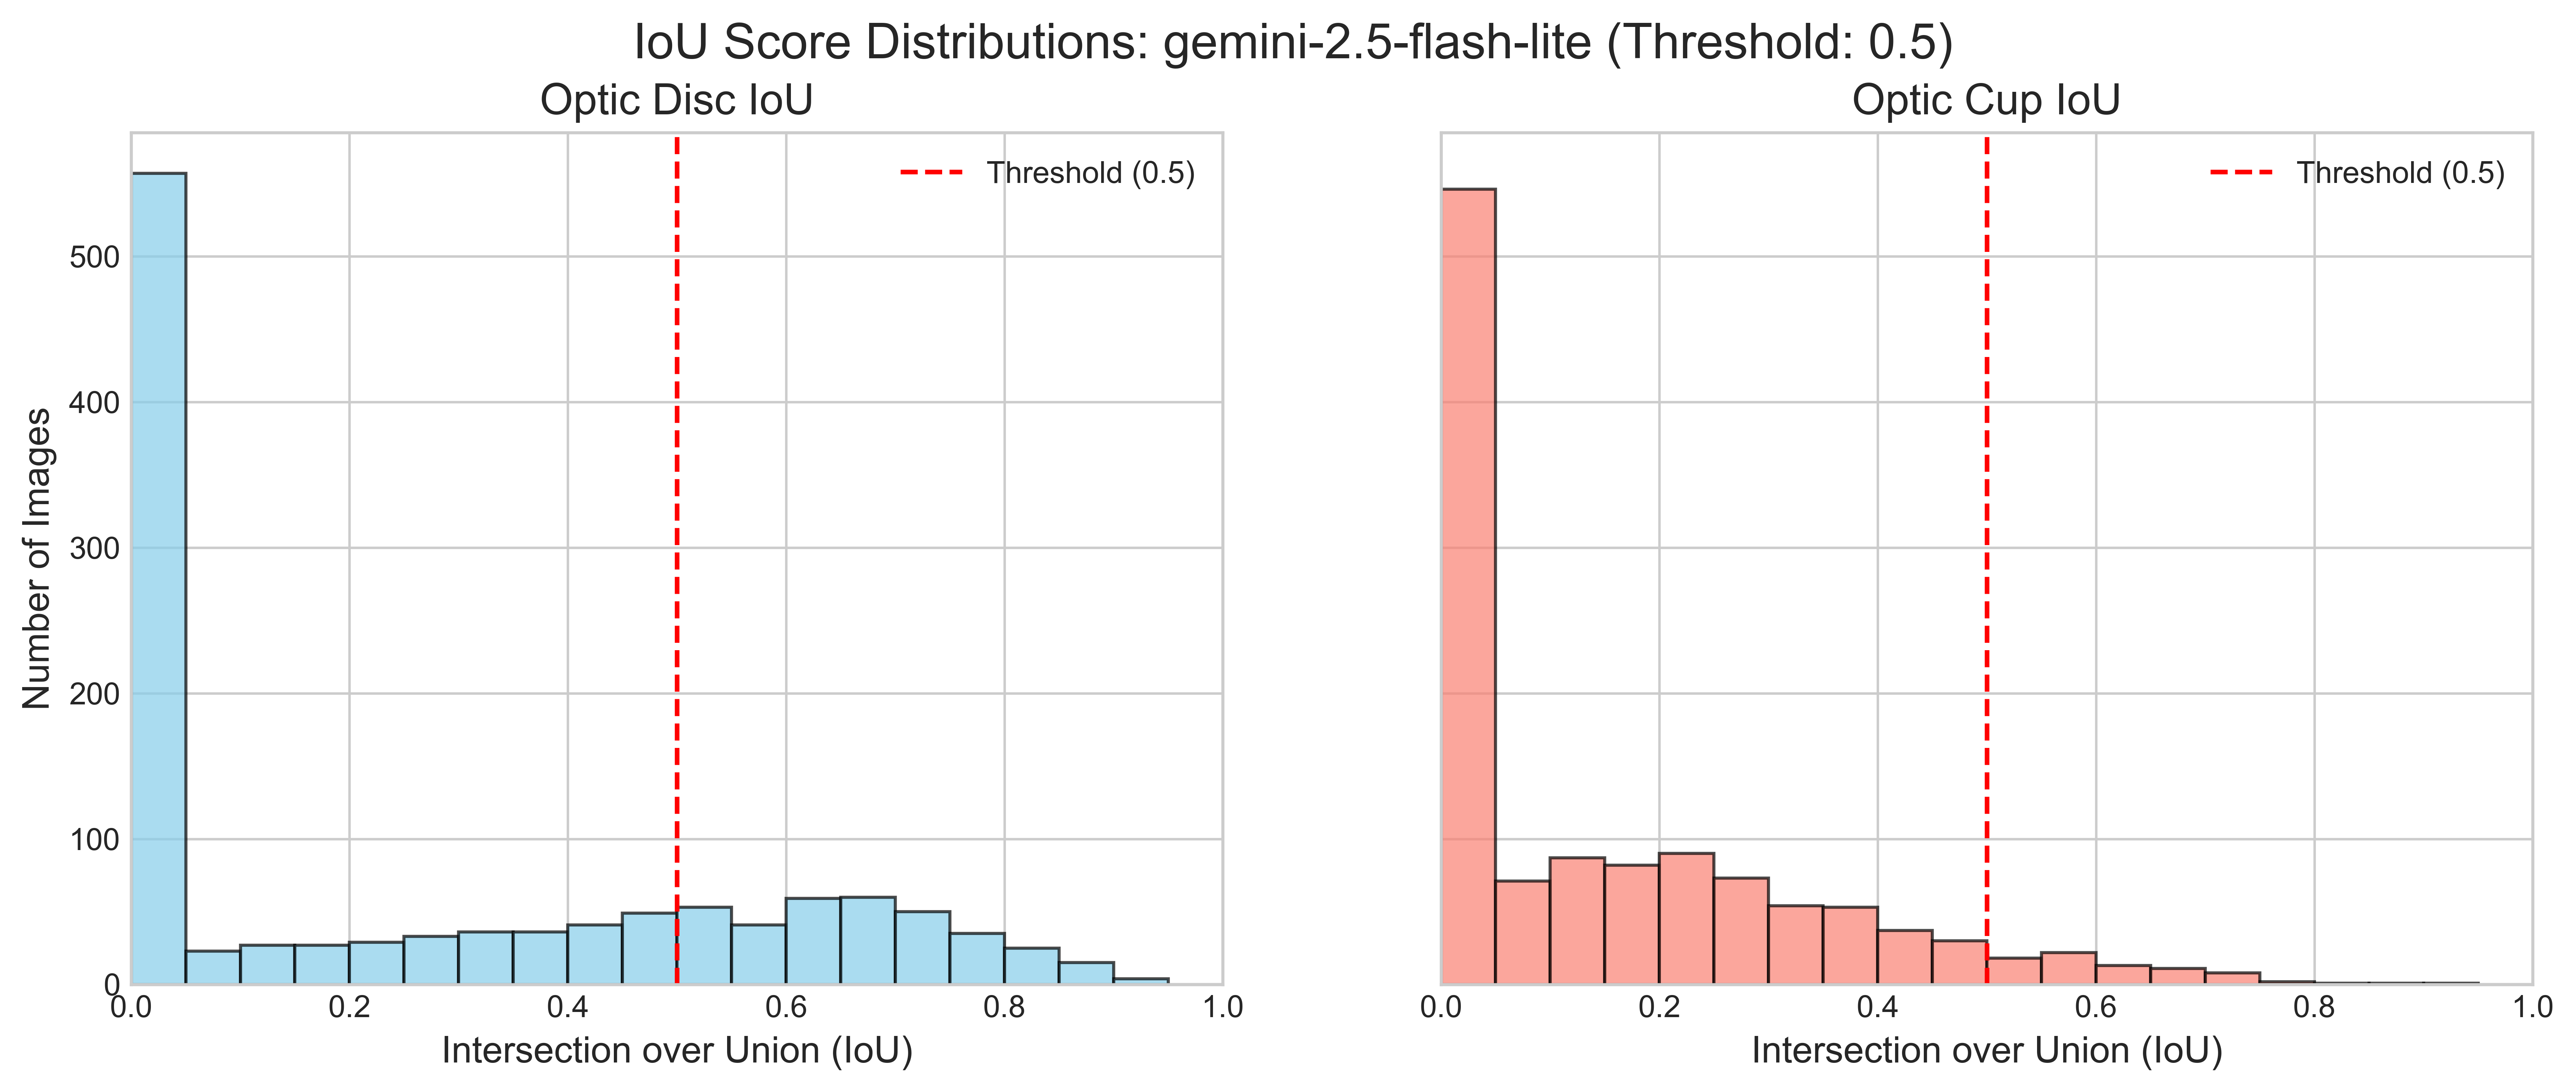

"\n✅ Re-analysis complete. The report above summarizes the model's performance using the new threshold.\n"

In [ ]:
# %% [markdown]
"""
# 06 Skin Lesion Results Re-Analysis Tool (Multithreaded)

*Last sync 01 Aug 2025*

This notebook re-calculates and re-plots evaluation metrics from a completed run's
cached predictions for the ISIC 2017 skin lesion segmentation task. It uses
multithreading to accelerate the processing of cached files.

**Instructions:**
1.  Ensure you have run the `04_Model_Evaluation_ISIC_2017` notebook with
    `SAVE_PREDICTIONS = True`.
2.  Set the `MODEL_TO_ANALYZE` variable below to the model you want to inspect.
3.  Set the `NEW_LOW_IOU_THRESHOLD` to the desired value for defining a "successful" detection.
4.  Use the `EXCLUDE_LOW_IOU_FROM_STATS` toggle to control the analysis behavior:
    - `True`: (Default) Excludes low-IoU cases from summary statistics (mean, CI).
      The plot will still show all cases but with a red threshold line.
    - `False`: Includes all cases (even IoU=0) in summary statistics.
      This gives a view of performance across the entire dataset.
"""

# %%
# ---------- Preamble & Setup ----------
import sys, logging, os, subprocess, importlib.util, json, io, base64, dataclasses
from datetime import datetime
from pathlib import Path
from typing import Tuple, List, Optional, Dict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from tqdm.notebook import tqdm
from dotenv import load_dotenv, find_dotenv

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Re-analysis notebook start.")

# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow", "pandas"):
    _ensure(extra)

# %%
# ---------- Dataset Path & Helper Functions ----------
# MODIFIED: Point to the ISIC 2017 dataset directory.
dataset_dir = Path("data/ISIC_2017_Part1").expanduser().resolve()
if not dataset_dir.is_dir():
    raise FileNotFoundError(f"Dataset directory not found at {dataset_dir}.")
logging.info("ISIC 2017 dataset found at %s", dataset_dir)


def load_prediction_from_cache(prediction_path: Path, target_shape: Tuple[int, int]) -> np.ndarray:
    """
    Loads a cached prediction JSON, combines all masks into one, and returns a single boolean mask.
    """
    default_mask = np.zeros(target_shape, dtype=bool)
    if not prediction_path.exists():
        logging.error(f"Prediction cache file not found: {prediction_path}")
        return default_mask

    with open(prediction_path, 'r') as f:
        try:
            items = json.load(f)
        except json.JSONDecodeError:
            logging.error(f"Could not decode JSON from cached file: {prediction_path}")
            return default_mask

    if not items:
        return default_mask # Return empty mask if prediction was empty list

    # Combine all predicted masks for the single class "lesion"
    combined_mask_np = np.zeros(target_shape, dtype=bool)
    for item in items:
        try:
            png_b64_str = item["mask_b64"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            mask_img = Image.open(io.BytesIO(png_bytes))
            mask_np = np.array(mask_img)
            # Ensure mask is boolean and combine with logical OR
            combined_mask_np = np.logical_or(combined_mask_np, mask_np > 127)
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.warning(f"Skipping malformed item in cached prediction: {item}. Error: {e}")
            continue
    return combined_mask_np

def parse_ground_truth_mask(mask_path: Path) -> Tuple[Optional[np.ndarray], Tuple[int, int]]:
    """
    Parses an ISIC 2017 ground truth PNG file into a binarized boolean NumPy array.
    Returns the boolean mask and its shape.
    """
    try:
        mask_img = Image.open(mask_path).convert("L")
        mask_data = np.array(mask_img)
        return mask_data > 127, mask_data.shape
    except (FileNotFoundError, UnidentifiedImageError) as e:
        logging.error("Could not read ground truth mask file %s: %s", mask_path, e)
        return None, (0, 0)

# %%
# ---------- Metric Calculation Functions ----------

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 1.0 # Perfect match if both are empty
    return np.sum(intersection) / np.sum(union)

def calculate_dice(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates the Dice Coefficient for boolean masks."""
    intersection = np.sum(np.logical_and(y_true, y_pred))
    denominator = np.sum(y_true) + np.sum(y_pred)
    if denominator == 0: return 1.0 # Perfect match if both are empty
    return (2. * intersection) / (denominator + 1e-7) # Add epsilon for stability

def calculate_bootstrap_ci(data: List[float], n_resamples: int = 1000) -> Tuple[float, float]:
    """Calculates the 95% confidence interval for a list of numbers using bootstrapping."""
    if not data or len(data) < 2: return 0.0, 0.0
    bootstrapped_means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_resamples)]
    return np.percentile(bootstrapped_means, 2.5), np.percentile(bootstrapped_means, 97.5)

# %% [markdown]
"""
### Re-Analysis Execution

This section loads the cached predictions, recalculates all metrics in parallel, and then generates a new report and plot based on the parameters you set below.
"""

# %%
# ---------- Main Re-Analysis Loop ----------

# <<< --- PARAMETERS TO CONTROL THE RE-ANALYSIS --- >>>
MODEL_TO_ANALYZE = "gemini-2.5-flash"
NEW_LOW_IOU_THRESHOLD = 0.75
EXCLUDE_LOW_IOU_FROM_STATS = True # Set to False to include all cases in stats/plots
MAX_WORKERS = os.cpu_count() or 4 # Use all available CPU cores, or default to 4

# --- Setup paths and find prediction files ---
model_name_safe = MODEL_TO_ANALYZE.replace("/", "_")
predictions_dir = dataset_dir / f"predictions_{model_name_safe}"
if not predictions_dir.is_dir():
    raise FileNotFoundError(f"Predictions directory not found for model '{MODEL_TO_ANALYZE}'. Please run the evaluation script first with SAVE_PREDICTIONS=True.")

prediction_files = list(predictions_dir.glob("*.json"))
if not prediction_files:
    raise FileNotFoundError(f"No prediction files found in {predictions_dir}.")

logging.info(f"Found {len(prediction_files)} cached predictions for model '{MODEL_TO_ANALYZE}'.")
logging.info(f"Starting re-analysis with up to {MAX_WORKERS} threads.")

# --- Worker function for parallel processing ---
def process_single_prediction(pred_path: Path) -> Optional[Dict]:
    """Processes a single prediction file to calculate metrics for the ISIC dataset."""
    image_stem = pred_path.stem

    # MODIFIED: Construct the ground truth mask path using the ISIC naming convention.
    mask_path = dataset_dir / "mask" / f"{image_stem}_Segmentation.png"
    if not mask_path.exists():
        # Suppress logging for cleaner parallel output, return None on failure
        return None

    gt_mask, gt_shape = parse_ground_truth_mask(mask_path)
    if gt_mask is None:
        return None

    predicted_mask = load_prediction_from_cache(pred_path, target_shape=gt_shape)

    # Recalculate all metrics
    iou = calculate_iou(gt_mask, predicted_mask)
    dice = calculate_dice(gt_mask, predicted_mask)

    return {"image_path": mask_path.name, "iou": iou, "dice": dice}

# --- Recalculate metrics in parallel ---
recalculated_results = []
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Use tqdm to show progress over the iterator returned by executor.map
    results_iterator = executor.map(process_single_prediction, prediction_files)
    for result in tqdm(results_iterator, total=len(prediction_files), desc=f"Re-analyzing {model_name_safe}"):
        if result is not None:
            recalculated_results.append(result)


# %% [markdown]
"""
### New Results Summary

The following report is generated from the recalculated metrics using your specified IoU threshold.
"""

# %%
# ---------- Aggregate, Display, and Save New Results ----------

if recalculated_results:
    df = pd.DataFrame(recalculated_results)

    # --- Determine which data to use for STATS based on the toggle ---
    if EXCLUDE_LOW_IOU_FROM_STATS:
        logging.info(f"Excluding cases with IoU < {NEW_LOW_IOU_THRESHOLD} from stats calculations.")
        runs_for_stats = df[df['iou'] >= NEW_LOW_IOU_THRESHOLD]
    else:
        logging.info("Including all cases (even IoU=0) in stats calculations.")
        runs_for_stats = df

    # --- Performance Metrics ---
    mean_iou = runs_for_stats['iou'].mean() if not runs_for_stats.empty else 0
    mean_dice = runs_for_stats['dice'].mean() if not runs_for_stats.empty else 0

    # --- Failure Analysis (based on the new threshold) ---
    total_runs = len(df)
    num_false_negatives = len(df[df['iou'] == 0])
    num_low_iou_failures = len(df[(df['iou'] > 0) & (df['iou'] < NEW_LOW_IOU_THRESHOLD)])

    # --- Confidence Intervals ---
    iou_ci = calculate_bootstrap_ci(runs_for_stats['iou'].tolist())
    dice_ci = calculate_bootstrap_ci(runs_for_stats['dice'].tolist())

    print("---" * 15)
    print(f"       Skin Lesion Segmentation Re-Analysis Report: {MODEL_TO_ANALYZE}")
    print("---" * 15)
    print(f"Total Cached Predictions Analyzed: {total_runs}")
    print(f"New IoU Threshold for Success:     {NEW_LOW_IOU_THRESHOLD}")
    print(f"Excluding Low IoU from Stats:      {EXCLUDE_LOW_IOU_FROM_STATS}")

    print("\n--- Performance Metrics ---")
    print(f"Mean IoU:                      {mean_iou:.4f} (95% CI: {iou_ci[0]:.4f} - {iou_ci[1]:.4f}) on {len(runs_for_stats)} images")
    print(f"Mean Dice Coefficient:         {mean_dice:.4f} (95% CI: {dice_ci[0]:.4f} - {dice_ci[1]:.4f})")

    print("\n--- Failure Analysis (New Threshold) ---")
    print(f"False Negatives (IoU=0): {num_false_negatives} ({num_false_negatives/total_runs:.1%})")
    print(f"Low IoU Failures:        {num_low_iou_failures} ({num_low_iou_failures/total_runs:.1%})")
    print("---" * 15)
    
    # --- Create and save summary dictionary ---
    summary_data = {
        "reanalysis_timestamp": datetime.now().isoformat(),
        "total_cached_predictions_analyzed": total_runs,
        "settings": {
            "model_analyzed": MODEL_TO_ANALYZE,
            "new_low_iou_threshold": NEW_LOW_IOU_THRESHOLD,
            "excluded_low_iou_from_stats": EXCLUDE_LOW_IOU_FROM_STATS,
        },
        "performance_metrics": {
            "mean_iou": mean_iou,
            "mean_dice": mean_dice,
            "mean_iou_95_ci": iou_ci,
            "mean_dice_95_ci": dice_ci,
            "num_images_in_stat_calc": len(runs_for_stats),
        },
        "failure_counts": {
            "false_negatives": num_false_negatives,
            "low_iou_failures": num_low_iou_failures,
        }
    }
    
    summary_path = dataset_dir / f"reanalysis_summary_isic_{model_name_safe}_thresh_{NEW_LOW_IOU_THRESHOLD}.json"
    with open(summary_path, 'w') as f:
        json.dump(summary_data, f, indent=4)
    logging.info(f"Saved re-analysis summary to {summary_path}")


    # --- Visualize and save the distribution of IoU scores ---
    # PLOT WILL ALWAYS SHOW ALL DATA, regardless of the stats toggle.
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6), dpi=600)
    fig.suptitle(f'IoU Score Distribution (ISIC 2017): {MODEL_TO_ANALYZE}', fontsize=16)

    ax.hist(df['iou'], bins=20, range=(0,1), edgecolor='black', alpha=0.75, color='cornflowerblue')
    ax.set_title(f'Lesion Segmentation IoU (n={total_runs})', fontsize=14)
    ax.set_xlabel('Intersection over Union (IoU)', fontsize=12)
    ax.set_ylabel('Number of Images', fontsize=12)
    ax.axvline(NEW_LOW_IOU_THRESHOLD, color='r', linestyle='--', label=f'Threshold ({NEW_LOW_IOU_THRESHOLD})')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

    plot_path = dataset_dir / f"reanalysis_iou_dist_isic_{model_name_safe}_thresh_{NEW_LOW_IOU_THRESHOLD}.png"
    plt.savefig(plot_path, bbox_inches='tight')
    logging.info(f"Saved re-analysis IoU plot to {plot_path}")
    plt.show()
else:
    print("No recalculated results were generated. Check if prediction files exist.")

# %% [markdown]
"""
✅ Re-analysis complete. The report above summarizes the model's performance using the new threshold.
"""


# Fitzpatrick Scale Classification

In [6]:
# %% [markdown]
"""
# 07 ITA-Derived Skin Tone Classification

*Last modified 04 Aug 2025*

This script performs an automated skin tone classification for the ISIC 2017
dataset based on the Individual Typology Angle (ITA). It calculates the ITA for
each image based on the color of non-lesional skin and then maps the ITA value
to a 6-bin category and a binary "Light vs. Dark" label.

This script is designed to measure constitutive pigmentation from the image data;
it does not and cannot capture an individual's sun-reactive phenotype (i.e., the
true Fitzpatrick skin type).

**Methodology (Updated based on 2022-2025 literature review):**
1.  Reads the master image list (`master_imagelist_isic.txt`) to ensure it
    processes the exact same set of images as the evaluation script.
2.  For each image, it loads the corresponding ground truth segmentation mask to
    identify and exclude the lesion area.
3.  Applies an **optional** YCbCr color mask, which is **disabled by default**.
    Recent literature suggests this mask, tuned on consumer photos, can
    incorrectly discard valid darker skin tones in dermoscopy.
4.  Converts the image to the CIE L*a*b* color space and calculates L* and b*
    values, rescaled to their standard float ranges.
5.  Applies a dynamic luminance filter to the non-lesional skin area, retaining
    pixels within a data-driven [floor, 95th percentile] lightness
    window. The floor is now set to a more inclusive `L* = 5.0`.
6.  An image is skipped if the remaining valid skin area is less than the larger
    of **2% of the image** or **200 absolute pixels**. This is more lenient
    than the previous 5% threshold.
7.  Calculates the ITA value for each valid pixel individually.
8.  Takes the **median** of all pixel-wise ITA values for a robust,
    outlier-resistant single score for the image.
9.  Classifies the median ITA into:
    a.  A 6-bin category based on the Chardon et al. (1991) thresholds.
    b.  A binary "Light (>28°)" vs. "Dark (≤28°)" label for fairness analysis.
10. Aggregates all results and saves them to multiple outputs:
    - A detailed CSV file (`ita_classification.csv`) with per-image data.
    - A JSON summary file (`summary_ita_classification.json`) with run
      parameters and aggregated results.
    - A text file (`skipped_images_ita.txt`) listing all images that could not
      be processed.
    - High-resolution plots of the ITA and Light/Dark distributions.

This process is multithreaded to accelerate file I/O.

**Citations:**
- Chardon A, et al. "Skin colour typology and suntanning pathways." Int J Cosmet Sci. 1991.
- Kinyanjui N M, et al. "Estimating Skin Tone and Effects on Classification Performance..." NeurIPS Fair ML for Health. 2019.
- Groh M, et al. "Towards Transparency in Dermatology Image Datasets..." arXiv. 2022.
- Benčević M, et al. "Skin Color Measurement from Dermatoscopic Images..." arXiv. 2025.
"""

# %%
# ---------- Preamble & Setup ----------
import sys
import logging
import os
import subprocess
import importlib.util
import json
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from typing import Tuple, List, Optional, Dict
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm
import matplotlib.pyplot as plt


# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("ITA-based skin tone classification script start.")


# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        if pkg == "cv2":
            pkg = "opencv-python-headless"
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("tqdm", "numpy", "Pillow", "pandas", "cv2", "matplotlib"):
    _ensure(extra)


# %%
# ---------- Constants and Configuration ----------

# --- Paths ---
DATASET_DIR = Path("data/ISIC_2017_Part1").expanduser().resolve()
IMAGE_DIR = DATASET_DIR / "image"
MASK_DIR = DATASET_DIR / "mask"
MASTER_LIST_PATH = DATASET_DIR / "master_imagelist_isic.txt"

# --- Outputs ---
OUTPUT_DIR = DATASET_DIR / "analysis_results"
OUTPUT_CSV_PATH = OUTPUT_DIR / "ita_classification.csv"
OUTPUT_JSON_SUMMARY_PATH = OUTPUT_DIR / "summary_ita_classification.json"
OUTPUT_SKIPPED_LIST_PATH = OUTPUT_DIR / "skipped_images_ita.txt"
OUTPUT_PLOT_ITA_PATH = OUTPUT_DIR / "dist_ita_scores.png"
OUTPUT_PLOT_SKINTONE_BIN_PATH = OUTPUT_DIR / "dist_skin_tone_bins.png"


# --- Analysis Toggles (Based on 2022-2025 Literature Review) ---

# Enable the YCbCr color mask. This is NOT recommended for dermoscopy as
# it can incorrectly filter out valid darker skin tones (types V-VI).
# It is kept as an option for analyses on standard clinical photographs.
USE_YCBCR = False

# The absolute minimum L* (lightness) value for the luminance filter.
# The previous value of 10.0 was found to be too aggressive for very dark skin.
L_STAR_FLOOR = 5.0

# The minimum required area of valid skin pixels to process an image.
# The check uses whichever of the two thresholds below is larger for a given image.
# This is relaxed from the original 5% to reduce erroneous skips on tight crops.
MIN_VALID_AREA_PCT = 0.02  # e.g., 0.02 for 2%
MIN_VALID_AREA_PIXELS = 200 # In absolute pixels


# --- Analysis Parameters ---
LIGHT_DARK_CUTPOINT = 28.0      # degrees, unchanged as per literature consensus

# --- Concurrency ---
N_THREADS = os.cpu_count() or 4


# %%
# ---------- Core Classification Functions ----------

def _to_lab_float(img_bgr: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    OpenCV converts to uint8-LAB with L in [0,255] and b in [0,255].
    This rescales to the canonical ranges: L*[0,100], b*[-128,127].
    """
    lab_uint8 = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l_star = lab_uint8[:, :, 0].astype(np.float32) * (100.0 / 255.0)
    b_star = lab_uint8[:, :, 2].astype(np.float32) - 128.0
    return l_star, b_star

def _pixelwise_ita(l_star: np.ndarray, b_star: np.ndarray) -> np.ndarray:
    """Vectorised pixel-level ITA map (degrees)."""
    # Use arctan2 for numerical stability (handles b* near zero)
    return np.degrees(np.arctan2(l_star - 50.0, b_star))

def classify_ita6(ita_value: float) -> int:
    """Chardon 1991 six-bin categorisation."""
    if ita_value > 55:      return 1
    elif ita_value > 41:    return 2
    elif ita_value > 28:    return 3
    elif ita_value > 10:    return 4
    elif ita_value > -30:   return 5
    else:                   return 6

def light_dark_bin(ita_value: float) -> str:
    """Binary classification for fairness analysis."""
    return "Light (>28°)" if ita_value > LIGHT_DARK_CUTPOINT else "Dark (≤28°)"

def _dynamic_lightness_mask(l_star: np.ndarray) -> np.ndarray:
    """
    Retains pixels with L* inside data-driven [floor, 95th percentile] window.
    Ensures very dark skin isn’t discarded by an aggressive hard floor.
    """
    floor = max(L_STAR_FLOOR, np.percentile(l_star, 1))
    ceil  = np.percentile(l_star, 95)
    return (l_star >= floor) & (l_star <= ceil)

def _optional_ycbcr_mask(img_bgr: np.ndarray) -> np.ndarray:
    """
    Simple YCbCr skin filter ported from the reference implementation.
    Acts as an additional *AND* mask to remove background artifacts.
    NOTE: Not recommended for dermoscopy; can filter valid dark skin.
    """
    ycbcr = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
    y, cr, cb = cv2.split(ycbcr)
    skin = (y > 80) & (cb > 85) & (cr > 135)
    skin &= (cr < (1.5862 * cb + 20)) & (cr > (0.3448 * cb + 76.2069))
    skin &= (cr > (-4.5652 * cb + 234.5652)) & (cr < (-1.15 * cb + 301.75))
    skin &= (cr < (-2.2857 * cb + 432.85))
    return skin

def calculate_and_classify(image_path: Path) -> Optional[Dict]:
    """
    Worker function to process a single image.
    Returns: {
        image_id, ita_median, ita_bin6, skin_tone_bin,
        valid_skin_pixel_count, valid_skin_area_pct, status
    }
    """
    image_id = image_path.stem
    mask_path = MASK_DIR / f"{image_id}_Segmentation.png"

    try:
        if not (image_path.exists() and mask_path.exists()):
            return {"image_id": image_id, "status": "error_file_not_found"}

        img_bgr = cv2.imread(str(image_path))
        if img_bgr is None:
            return {"image_id": image_id, "status": "error_cv2_read_failed"}

        lesion_np = np.array(Image.open(mask_path).convert("L")) > 127
        non_lesion_mask = ~lesion_np

        # Apply optional color mask (disabled by default for dermoscopy)
        if USE_YCBCR:
            color_mask = _optional_ycbcr_mask(img_bgr)
        else:
            # Create a mask that is all True, which has no effect when combined.
            color_mask = np.ones_like(non_lesion_mask, dtype=bool)
        
        candidate_mask = non_lesion_mask & color_mask

        l_star, b_star = _to_lab_float(img_bgr)
        lumi_mask = _dynamic_lightness_mask(l_star)
        valid_mask = candidate_mask & lumi_mask

        # New hybrid minimum area check
        valid_pixel_count = np.sum(valid_mask)
        pixel_threshold_from_pct = valid_mask.size * MIN_VALID_AREA_PCT
        final_pixel_threshold = max(pixel_threshold_from_pct, MIN_VALID_AREA_PIXELS)

        if valid_pixel_count < final_pixel_threshold:
            return {
                "image_id": image_id,
                "valid_skin_pixel_count": int(valid_pixel_count),
                "valid_skin_area_pct": round(valid_pixel_count / valid_mask.size, 4),
                "status": "skipped_insufficient_area",
            }

        ita_map = _pixelwise_ita(l_star, b_star)
        # Use nanmedian to be robust to potential NaNs from the arctan2 calculation
        ita_median = float(np.nanmedian(ita_map[valid_mask]))

        return {
            "image_id": image_id,
            "ita_median": round(ita_median, 4),
            "ita_bin6": classify_ita6(ita_median),
            "skin_tone_bin": light_dark_bin(ita_median),
            "valid_skin_pixel_count": int(valid_pixel_count),
            "valid_skin_area_pct": round(valid_pixel_count / valid_mask.size, 4),
            "status": "processed",
        }

    except (UnidentifiedImageError, cv2.error) as e:
        logging.error(f"Error processing {image_id}: {e}")
        return {"image_id": image_id, "status": f"error_{type(e).__name__}"}
    except Exception as e:
        logging.error(f"An unexpected error occurred processing {image_id}: {e}", exc_info=False)
        return {"image_id": image_id, "status": "error_unexpected"}


# %%
# ---------- Main Execution Loop ----------
if __name__ == "__main__":
    if not MASTER_LIST_PATH.exists():
        raise FileNotFoundError(
            f"Master image list not found at {MASTER_LIST_PATH}. "
            "Please run the '04_Model_Evaluation' script first to generate it."
        )

    with open(MASTER_LIST_PATH, 'r') as f:
        images_to_process = [IMAGE_DIR / f"{Path(line.strip()).stem}.jpg" for line in f.readlines()]
    
    logging.info("---" * 15)
    logging.info("Starting ITA classification with the following settings:")
    logging.info(f"  - YCbCr Color Mask: {'Enabled' if USE_YCBCR else 'Disabled'}")
    logging.info(f"  - L* Floor: {L_STAR_FLOOR}")
    logging.info(f"  - Min Area Threshold: {MIN_VALID_AREA_PCT*100}% or {MIN_VALID_AREA_PIXELS}px (whichever is larger)")
    logging.info(f"  - Light/Dark Cut-point: {LIGHT_DARK_CUTPOINT}°")
    logging.info("---" * 15)


    logging.info(f"Found {len(images_to_process)} images to process from master list.")
    logging.info(f"Using up to {N_THREADS} threads.")

    all_results = []
    with ThreadPoolExecutor(max_workers=N_THREADS) as executor:
        results_iterator = executor.map(calculate_and_classify, images_to_process)
        for result in tqdm(results_iterator, total=len(images_to_process), desc="Classifying Skin Tones"):
            if result:
                all_results.append(result)

    # --- Aggregate, Display, and Save New Results ---
    if all_results:
        df = pd.DataFrame(all_results)
        df_processed = df[df['status'] == 'processed'].copy()
        if not df_processed.empty:
            df_processed['ita_bin6'] = df_processed['ita_bin6'].astype(int)

        skipped_images = df[df['status'] != 'processed']

        print("\n---" * 15)
        print("      ITA-Derived Skin Tone Classification Summary")
        print("---" * 15)
        print(f"Total Images from Master List: {len(images_to_process)}")
        print(f"Successfully Processed:        {len(df_processed)}")
        print(f"Skipped or Errored Images:     {len(skipped_images)}")
        print("---\n")

        if not df_processed.empty:
            print("Distribution of Light vs. Dark Bins:")
            bin_counts = df_processed['skin_tone_bin'].value_counts().reindex(
                ["Light (>28°)", "Dark (≤28°)"]).fillna(0).astype(int)
            print(bin_counts.to_string())

            ita6_counts_series = df_processed['ita_bin6'].value_counts().sort_index()
            ita6_counts = ita6_counts_series.to_dict()
            print("\nDistribution of 6-level ITA Bins:")
            print(ita6_counts_series.to_string())
        else:
            print("No images were successfully processed to show a distribution.")
            bin_counts = pd.Series()
            ita6_counts = {}
        print("\n---" * 15)

        # --- Save all outputs ---
        OUTPUT_DIR.mkdir(exist_ok=True)

        df.to_csv(OUTPUT_CSV_PATH, index=False)
        logging.info(f"Saved detailed per-image results to: {OUTPUT_CSV_PATH}")

        if not skipped_images.empty:
            skipped_images[['image_id', 'status']].to_csv(OUTPUT_SKIPPED_LIST_PATH, sep='\t', index=False)
            logging.info(f"Saved list of {len(skipped_images)} skipped images to: {OUTPUT_SKIPPED_LIST_PATH}")

        summary_data = {
            "run_timestamp": datetime.now().isoformat(),
            "metric": "Individual Typology Angle (median)",
            "light_dark_cutpoint": LIGHT_DARK_CUTPOINT,
            "settings": {
                "use_ycbcr_mask": USE_YCBCR,
                "l_star_floor": L_STAR_FLOOR,
                "min_valid_area_percent": MIN_VALID_AREA_PCT,
                "min_valid_area_pixels": MIN_VALID_AREA_PIXELS,
            },
            "results": {
                "total_images_from_master_list": len(images_to_process),
                "processed_count": len(df_processed),
                "skipped_count": len(skipped_images),
                "ita_bin6_distribution": {str(k): int(v) for k, v in ita6_counts.items()},
                "light_dark_distribution": {k: int(v) for k, v in bin_counts.to_dict().items()},
            }
        }
        with open(OUTPUT_JSON_SUMMARY_PATH, 'w') as f:
            json.dump(summary_data, f, indent=4)
        logging.info(f"Saved JSON summary to: {OUTPUT_JSON_SUMMARY_PATH}")

        # --- Create and save visualizations ---
        plt.style.use('seaborn-v0_8-whitegrid')

        if not df_processed.empty:
            # Plot 1: Histogram of median ITA scores
            fig1, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
            ax1.hist(df_processed['ita_median'], bins=50, edgecolor='black', alpha=0.75, color='teal')
            ax1.set_title(f'Distribution of ITA (median per image) (n={len(df_processed)})', fontsize=16)
            ax1.set_xlabel('Individual Typology Angle (ITA°)', fontsize=12)
            ax1.set_ylabel('Number of Images', fontsize=12)
            ax1.axvline(LIGHT_DARK_CUTPOINT, color='crimson', linestyle='--', linewidth=2, label=f'Cut-point = {LIGHT_DARK_CUTPOINT}°')
            ax1.legend()
            fig1.tight_layout()
            plt.savefig(OUTPUT_PLOT_ITA_PATH, bbox_inches='tight')
            logging.info(f"Saved ITA distribution plot to: {OUTPUT_PLOT_ITA_PATH}")

            # Plot 2: Bar chart of Light vs. Dark bins
            fig2, ax2 = plt.subplots(figsize=(8, 6), dpi=300)
            bin_counts.plot(kind='bar', ax=ax2, color=['skyblue', 'coral'], edgecolor='black', width=0.7)
            ax2.set_title(f'Distribution of Light vs. Dark Skin Tones (n={len(df_processed)})', fontsize=16)
            ax2.set_xlabel('ITA-Derived Skin Tone Bin', fontsize=12)
            ax2.set_ylabel('Number of Images', fontsize=12)
            ax2.tick_params(axis='x', rotation=0)
            # Add labels to bars
            for container in ax2.containers:
                ax2.bar_label(container, fmt='%d', fontsize=11, padding=3)
            fig2.tight_layout()
            plt.savefig(OUTPUT_PLOT_SKINTONE_BIN_PATH, bbox_inches='tight')
            logging.info(f"Saved Light/Dark bin distribution plot to: {OUTPUT_PLOT_SKINTONE_BIN_PATH}")
            plt.close('all')

    else:
        logging.warning("No results were generated. Check for errors above.")

# %% [markdown]
"""
✅ Classification complete. The analysis has been saved to multiple files in the
`analysis_results` directory, including a detailed CSV, a JSON summary, a list
of skipped images, and distribution plots. The parameters used for this run
are documented in the JSON summary.
"""


2025-08-04 22:26:42 — INFO — ITA-based skin tone classification script start.
2025-08-04 22:26:42 — INFO — Installing Pillow (missing)
2025-08-04 22:26:44 — INFO — ---------------------------------------------
2025-08-04 22:26:44 — INFO — Starting ITA classification with the following settings:
2025-08-04 22:26:44 — INFO —   - YCbCr Color Mask: Disabled
2025-08-04 22:26:44 — INFO —   - L* Floor: 5.0
2025-08-04 22:26:44 — INFO —   - Min Area Threshold: 2.0% or 200px (whichever is larger)
2025-08-04 22:26:44 — INFO —   - Light/Dark Cut-point: 28.0°
2025-08-04 22:26:44 — INFO — ---------------------------------------------
2025-08-04 22:26:44 — INFO — Found 4074 images to process from master list.
2025-08-04 22:26:44 — INFO — Using up to 12 threads.
Classifying Skin Tones: 100%|██████████| 4074/4074 [08:35<00:00,  7.90it/s] 
2025-08-04 22:35:19 — INFO — Saved detailed per-image results to: D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\analysis_results\ita_classification.csv
2


---
---
---
---
---
---
---
---
---
---
---
---
---
---
---
      ITA-Derived Skin Tone Classification Summary
---------------------------------------------
Total Images from Master List: 4074
Successfully Processed:        4057
Skipped or Errored Images:     17
---

Distribution of Light vs. Dark Bins:
skin_tone_bin
Light (>28°)    3499
Dark (≤28°)      558

Distribution of 6-level ITA Bins:
ita_bin6
1    2485
2     583
3     431
4     350
5     170
6      38

---
---
---
---
---
---
---
---
---
---
---
---
---
---
---


2025-08-04 22:35:20 — INFO — Saved ITA distribution plot to: D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\analysis_results\dist_ita_scores.png
2025-08-04 22:35:20 — INFO — Saved Light/Dark bin distribution plot to: D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\analysis_results\dist_skin_tone_bins.png


'\n✅ Classification complete. The analysis has been saved to multiple files in the\n`analysis_results` directory, including a detailed CSV, a JSON summary, a list\nof skipped images, and distribution plots. The parameters used for this run\nare documented in the JSON summary.\n'

# Bias Analysis

In [7]:
# %% [markdown]
"""
# 08 Statistical Fairness Audit

*Last sync 03 Aug 2025*

This script conducts a comprehensive statistical fairness audit of a segmentation
model's performance on the ISIC 2017 dataset, stratified by an ITA-derived
skin tone proxy. It systematically implements an 8-step analysis plan
to identify, quantify, and report on performance disparities across different
skin tone groups.

**Methodology:**
1.  **Data Ingestion:** Loads and merges per-image IoU scores from a model
    evaluation run with the ITA classifications from the analysis script.
    - **ROBUSTNESS UPDATE:** If the IoU data file is missing, this script will
      now automatically regenerate it from the cached predictions.
2.  **Dual Analysis Mode:** A toggle (`RUN_THRESHOLDED_ANALYSIS`) controls whether the
    analysis is run only on the full, continuous IoU data (un-thresholded) or
    if a second, separate analysis is run on a "successful" subset where IoU meets
    a defined threshold.
3.  **Group Assignment:** Stratifies images into a primary binary group (Light/Dark)
    and a secondary 4-level group based on ITA values.
4.  **Descriptive Statistics:** Calculates per-group IoU counts, means, medians,
    and 95% BCa bootstrapped confidence intervals for each analysis mode.
5.  **Inferential Statistics:**
    - Performs a Kruskal-Wallis H-test for a global assessment of differences.
    - Conducts a post-hoc Dunn's test with Holm-Bonferroni correction to
      identify which specific group pairs differ significantly.
    - Calculates Cliff's Delta with 95% confidence intervals for each pair to
      quantify the effect size.
6.  **Binary Parity Check:** Compares the proportion of "successful" segmentations
    (IoU >= threshold) across groups using a Chi-squared test.
7.  **Visualization:** Generates and saves separate sets of high-resolution plots
    for both the un-thresholded and thresholded analyses.
8.  **Reporting:** Produces a detailed text report in the console and saves all
    results to a single, structured JSON file for documentation.
"""

# %%
# ---------- Preamble & Setup ----------
import sys
import logging
import os
import subprocess
import importlib.util
import json
import base64
import io
import argparse
from pathlib import Path
from datetime import datetime
import warnings
from concurrent.futures import ThreadPoolExecutor
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from PIL import Image, UnidentifiedImageError
import scipy.stats as ss
import scikit_posthocs as sp
from cliffs_delta import cliffs_delta
from tqdm import tqdm

# Suppress warnings if needed
warnings.filterwarnings("ignore", category=FutureWarning)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Statistical fairness audit script start.")

# %%
# ---------- Ensure helper packages ----------
def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("pandas", "numpy", "matplotlib", "scipy", "scikit-posthocs", "pingouin", "statsmodels", "tqdm", "Pillow", "cliffs_delta"):
    _ensure(extra)

# %%
# ---------- Configuration & Paths ----------

# --- Input Paths ---
DATASET_DIR = Path("data/ISIC_2017_Part1").expanduser().resolve()
ANALYSIS_RESULTS_DIR = DATASET_DIR / "analysis_results"
# IMPORTANT: This file is the output from the ITA classification script.
# New standard filename is 'ita_classification.csv'.
ITA_DATA_PATH = ANALYSIS_RESULTS_DIR / "ita_classification.csv"
# IMPORTANT: This file should be the CSV output from the re-analysis script (06)
MODEL_IOU_DATA_PATH = ANALYSIS_RESULTS_DIR / "recalculated_iou_scores.csv"
MODEL_BEING_ANALYZED = "gemini-2.5-flash" # For reporting purposes

# --- Output Paths ---
OUTPUT_DIR = ANALYSIS_RESULTS_DIR
OUTPUT_JSON_REPORT_PATH = OUTPUT_DIR / f"report_fairness_audit_{MODEL_BEING_ANALYZED}.json"

# --- Analysis Parameters ---
IOU_SUCCESS_THRESHOLD = 0.5 # Updated from 0.75
CONFIDENCE_LEVEL = 0.95
N_RESAMPLES_BOOT = 5000  # Increased from 1000 for stability
P_VALUE_ALPHA = 0.05
MAX_WORKERS = os.cpu_count() or 4
RUN_THRESHOLDED_ANALYSIS = True

# --- CLI Argument for Resamples ---
parser = argparse.ArgumentParser(description="Run statistical fairness audit.")
parser.add_argument("--n-resamples", type=int, default=N_RESAMPLES_BOOT, help=f"Number of bootstrap resamples (default: {N_RESAMPLES_BOOT})")
# In a real script execution, use parser.parse_args(). For interactive notebooks, we can skip.
try:
    args = parser.parse_args()
    N_RESAMPLES_BOOT = args.n_resamples
    logging.info(f"Using {N_RESAMPLES_BOOT} bootstrap resamples from CLI argument.")
except: # In notebook environment, args will fail
    logging.info(f"Using default {N_RESAMPLES_BOOT} bootstrap resamples.")


# %%
# ---------- Core Analysis & Helper Functions ----------

# --- Functions for Regenerating IoU Data (if needed) ---

def calculate_iou(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Calculates Intersection over Union (IoU) for boolean masks."""
    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    if np.sum(union) == 0: return 1.0
    return np.sum(intersection) / np.sum(union)

def load_prediction_from_cache(prediction_path: Path, target_shape: tuple) -> np.ndarray:
    """Loads a cached prediction JSON and returns a single combined boolean mask."""
    default_mask = np.zeros(target_shape, dtype=bool)
    if not prediction_path.exists(): return default_mask
    try:
        with open(prediction_path, 'r') as f: items = json.load(f)
    except (json.JSONDecodeError, IOError): return default_mask
    if not items: return default_mask

    combined_mask_np = np.zeros(target_shape, dtype=bool)
    for item in items:
        try:
            png_b64_str = item["mask_b64"]
            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            mask_img = Image.open(io.BytesIO(png_bytes))
            mask_np = np.array(mask_img)
            combined_mask_np = np.logical_or(combined_mask_np, mask_np > 127)
        except Exception: continue
    return combined_mask_np

def parse_gt_shape_and_mask(mask_path: Path) -> tuple[np.ndarray | None, tuple[int, int] | None]:
    """Parses a ground truth mask, returning the boolean mask and its shape."""
    try:
        mask_img = Image.open(mask_path).convert("L")
        mask_data = np.array(mask_img)
        return mask_data > 127, mask_data.shape
    except (FileNotFoundError, UnidentifiedImageError):
        return None, None

def recalculate_iou_for_image(pred_path: Path) -> dict | None:
    """Worker function to recalculate IoU for a single cached prediction."""
    image_stem = pred_path.stem
    mask_path = DATASET_DIR / "mask" / f"{image_stem}_Segmentation.png"

    gt_mask, gt_shape = parse_gt_shape_and_mask(mask_path)
    if gt_mask is None: return None

    predicted_mask = load_prediction_from_cache(pred_path, target_shape=gt_shape)
    iou_score = calculate_iou(gt_mask, predicted_mask)

    return {"image_path": mask_path.name, "iou": iou_score}

# --- Core Statistical Functions ---

def assign_ita_groups(df: pd.DataFrame) -> pd.DataFrame:
    """
    Assigns images to ITA-based groups.
    Expects columns 'ita_bin6' and 'skin_tone_bin' from the revised ITA script.
    Creates a 4-level bucket for descriptive stats.
    """
    four_level_map = {
        1: "I-II", 2: "I-II", 3: "III",
        4: "IV",   5: "V-VI", 6: "V-VI"
    }
    # The 'skin_tone_bin' column (e.g., "Light (>28°)") is assumed to exist from the input CSV
    # and will be used directly as the primary analysis group.
    df["ita_group4"] = df["ita_bin6"].map(four_level_map)
    return df

def calculate_descriptive_stats(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """Calculates descriptive statistics (count, mean, median, CI) for IoU by group."""
    summary = df.groupby(group_col)['iou'].agg(['count', 'mean', 'median']).reset_index()
    cis = []
    for name, group_df in df.groupby(group_col):
        if len(group_df['iou']) < 2:
            cis.append({'low': np.nan, 'high': np.nan})
            continue
        # Using .to_numpy() for performance
        group_iou_values = (group_df['iou'].to_numpy(),)
        bootstrap_result = ss.bootstrap(
            group_iou_values, np.mean, confidence_level=CONFIDENCE_LEVEL,
            n_resamples=N_RESAMPLES_BOOT, method='BCa', random_state=42 # For reproducibility
        )
        cis.append({'low': bootstrap_result.confidence_interval.low, 'high': bootstrap_result.confidence_interval.high})
    summary = summary.join(pd.DataFrame(cis))
    return summary

def _cliffs_delta_ci(x: np.ndarray, y: np.ndarray, n_resamples: int = 2000) -> tuple[float, float, float]:
    """Helper to calculate Cliff's Delta and its percentile bootstrap CI."""
    deltas = []
    rng = np.random.default_rng(42) # For reproducible CIs
    for _ in range(n_resamples):
        xs = rng.choice(x, len(x), replace=True)
        ys = rng.choice(y, len(y), replace=True)
        d, _ = cliffs_delta(xs, ys)
        deltas.append(d)
    
    low, high = np.percentile(deltas, [2.5, 97.5])
    # Calculate the point estimate on the original data
    d_point, _ = cliffs_delta(x, y)
    return float(d_point), float(low), float(high)

def perform_inferential_tests(df: pd.DataFrame, group_col: str) -> dict:
    """Performs Kruskal-Wallis, Dunn's post-hoc, and Cliff's Delta tests."""
    groups = [group['iou'].values for name, group in df.groupby(group_col)]
    if len(groups) < 2:
        return {"kruskal_h_statistic": None, "kruskal_p_value": None, "dunn_results": None, "cliff_delta_results": None}

    h_stat, p_global = ss.kruskal(*groups)
    dunn_results = sp.posthoc_dunn(df, val_col='iou', group_col=group_col, p_adjust='holm')

    # Re-enabled Cliff's Delta analysis with CIs and JSON-safe keys
    cliff_results = {}
    group_names = sorted(df[group_col].unique()) # Sort for consistent pairing
    for g1, g2 in itertools.combinations(group_names, 2):
        x = df.loc[df[group_col] == g1, 'iou'].values
        y = df.loc[df[group_col] == g2, 'iou'].values
        if len(x) > 1 and len(y) > 1:
            delta, lo, hi = _cliffs_delta_ci(x, y)
            key = f"{g1} vs {g2}"  # JSON-safe string key
            cliff_results[key] = {"delta": delta, "ci_low": lo, "ci_high": hi}

    return {
        "kruskal_h_statistic": h_stat, "kruskal_p_value": p_global,
        "dunn_results": dunn_results.to_dict('index'),
        "cliff_delta_results": cliff_results
    }

def check_binary_parity(df: pd.DataFrame, group_col: str) -> dict:
    """Performs a Chi-squared test for binary success rates across multiple groups."""
    df['is_successful'] = df['iou'] >= IOU_SUCCESS_THRESHOLD
    contingency_table = pd.crosstab(df[group_col], df['is_successful'])
    if contingency_table.shape[1] < 2 or contingency_table.shape[0] < 2:
        return {"contingency_table": contingency_table.to_dict(), "chi2_stat": None, "p_value": None}
    chi2_stat, p_value, _, _ = ss.chi2_contingency(contingency_table)
    return {"contingency_table": contingency_table.to_dict(), "chi2_statistic": chi2_stat, "p_value": p_value}

def generate_visualizations(df: pd.DataFrame, group_col: str, file_prefix: str):
    """Generates and saves all required plots."""
    plt.style.use('default')
    group_order = sorted(df[group_col].unique())
    file_prefix = file_prefix.replace("/", "_").replace(" ", "")

    # Plot 1: Violin + Box Plot
    fig, ax = plt.subplots(figsize=(12, 7), dpi=300)
    group_data = [df[df[group_col] == g]['iou'].values for g in group_order]
    parts = ax.violinplot(group_data, showmeans=False, showmedians=False, showextrema=False)
    for pc in parts['bodies']: pc.set_facecolor('#D4E6F1'); pc.set_edgecolor('black'); pc.set_alpha(0.8)
    # FIX 1: Renamed 'labels' to 'tick_labels' to resolve MatplotlibDeprecationWarning.
    ax.boxplot(group_data, tick_labels=group_order, showfliers=False, medianprops={'color': 'red', 'linewidth': 2})
    ax.set_title(f'IoU Score Distribution by {group_col.replace("_", " ").title()}', fontsize=16)
    ax.set_ylabel('Intersection over Union (IoU)', fontsize=12); ax.set_xlabel(group_col.replace("_", " ").title(), fontsize=12)
    ax.set_ylim(0, 1); ax.grid(True, which='major', linestyle='--', linewidth='0.5', color='grey')
    fig.tight_layout(); plt.savefig(OUTPUT_DIR / f"plot_violin_{file_prefix}.png")

    # Plot 2: Stacked Bar Plot for Parity
    parity_results = check_binary_parity(df, group_col)
    cont_table = pd.DataFrame(parity_results['contingency_table']).sort_index()
    if cont_table.empty: return
    if True not in cont_table.columns: cont_table[True] = 0
    if False not in cont_table.columns: cont_table[False] = 0
    cont_table = cont_table.reindex(columns=[False, True])

    cont_table_pct = cont_table.div(cont_table.sum(axis=1), axis=0)
    fig2, ax2 = plt.subplots(figsize=(10, 6), dpi=300)
    cont_table_pct.plot(kind='bar', stacked=True, ax=ax2, colormap='coolwarm_r', width=0.8)
    ax2.set_title(f'Success Rate (IoU >= {IOU_SUCCESS_THRESHOLD}) by {group_col.replace("_", " ").title()}', fontsize=16)
    ax2.set_ylabel('Proportion of Images', fontsize=12); ax2.set_xlabel(group_col.replace("_", " ").title(), fontsize=12)
    ax2.legend(title='Success', labels=['Fail', 'Pass']); ax2.tick_params(axis='x', rotation=0)
    # FIX 2: Replaced manual tick label setting with PercentFormatter to resolve UserWarning.
    ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    fig2.tight_layout()
    plt.savefig(OUTPUT_DIR / f"plot_bar_{file_prefix}.png"); plt.close('all')


# %%
# ---------- Main Execution Block ----------
if __name__ == "__main__":
    # --- 1. Load and Merge Data (with fallback regeneration) ---
    # Check for the new standard filename first, then fall back to the old one.
    if not ITA_DATA_PATH.exists():
        legacy_path = ANALYSIS_RESULTS_DIR / "fitzpatrick_classification.csv"
        if legacy_path.exists():
            logging.warning(f"'{ITA_DATA_PATH.name}' not found. Using legacy file '{legacy_path.name}'.")
            ITA_DATA_PATH = legacy_path
        else:
            raise FileNotFoundError(f"Critical input file missing. Neither '{ITA_DATA_PATH.name}' nor legacy file '{legacy_path.name}' were found.")

    if not MODEL_IOU_DATA_PATH.exists():
        logging.warning(f"'{MODEL_IOU_DATA_PATH.name}' not found. Attempting to regenerate it from cached predictions...")
        model_name_safe = MODEL_BEING_ANALYZED.replace('/', '_')
        predictions_dir = DATASET_DIR / f"predictions_{model_name_safe}"
        if not predictions_dir.is_dir():
            raise FileNotFoundError(f"Cannot regenerate IoU data because predictions directory not found: {predictions_dir}")
        prediction_files = list(predictions_dir.glob("*.json"))
        if not prediction_files:
            raise FileNotFoundError(f"No prediction files found in {predictions_dir}.")

        recalculated_results = []
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            results_iterator = executor.map(recalculate_iou_for_image, prediction_files)
            for result in tqdm(results_iterator, total=len(prediction_files), desc=f"Regenerating IoU data for {MODEL_BEING_ANALYZED}"):
                if result: recalculated_results.append(result)

        df_iou = pd.DataFrame(recalculated_results)
        df_iou.to_csv(MODEL_IOU_DATA_PATH, index=False)
        logging.info(f"Successfully regenerated and saved IoU data to '{MODEL_IOU_DATA_PATH.name}'.")
    else:
        logging.info(f"Loading existing IoU data from '{MODEL_IOU_DATA_PATH.name}'.")
        df_iou = pd.read_csv(MODEL_IOU_DATA_PATH)

    logging.info(f"Loading ITA data from '{ITA_DATA_PATH.name}'")
    df_ita = pd.read_csv(ITA_DATA_PATH)
    
    # --- Compatibility Layer for older data files ---
    # If expected columns are missing, try to create them from older column names.
    if 'ita_bin6' not in df_ita.columns and 'fitzpatrick_type' in df_ita.columns:
        logging.warning("Column 'ita_bin6' not found. Renaming 'fitzpatrick_type' for compatibility.")
        df_ita.rename(columns={'fitzpatrick_type': 'ita_bin6'}, inplace=True)

    if 'skin_tone_bin' not in df_ita.columns and 'ita_bin6' in df_ita.columns:
        logging.warning("Column 'skin_tone_bin' not found. Creating it from 'ita_bin6' for compatibility.")
        df_ita['skin_tone_bin'] = df_ita['ita_bin6'].apply(lambda x: 'Light (>28°)' if x <= 3 else 'Dark (≤28°)')
    
    # Ensure we only use images that were successfully processed by the ITA script
    df_ita_processed = df_ita[df_ita['status'] == 'processed'].copy()

    df_iou['image_id'] = df_iou['image_path'].apply(lambda x: Path(x).stem.replace('_Segmentation', ''))

    # Merge ITA data with IoU scores
    df_analysis = pd.merge(df_ita_processed, df_iou[['image_id', 'iou']], on='image_id')
    logging.info(f"Successfully merged data, resulting in {len(df_analysis)} images for analysis.")

    # Assign images to new ITA-based groups
    df_analysis = assign_ita_groups(df_analysis)

    # --- Run Analysis Pipeline ---
    full_report = {}
    
    analysis_modes = ["unthresholded"]
    if RUN_THRESHOLDED_ANALYSIS:
        analysis_modes.append("thresholded")
    
    # New analysis specifications
    analysis_specs = [
        ("Primary Analysis (Light vs Dark)", "skin_tone_bin"),
        ("Secondary Analysis (ITA 4-groups)", "ita_group4"),
    ]

    for mode in analysis_modes:
        df_run = df_analysis.copy()
        mode_suffix = f"({mode.capitalize()})"
        
        if mode == "thresholded":
            logging.info(f"\n--- Filtering data for THRESHOLDED analysis (IoU >= {IOU_SUCCESS_THRESHOLD}) ---")
            df_run = df_run[df_run['iou'] >= IOU_SUCCESS_THRESHOLD].copy()
            logging.info(f"Retained {len(df_run)} images for thresholded analysis.")

        for analysis_name, group_column in analysis_specs:
            report_key = f"{analysis_name} {mode_suffix}"
            logging.info(f"--- Running: {report_key} ---")
            
            if df_run.empty or df_run[group_column].nunique() < 2:
                logging.warning(f"Skipping '{report_key}' due to insufficient data or groups.")
                continue

            descriptives = calculate_descriptive_stats(df_run, group_column)
            inferentials = perform_inferential_tests(df_run, group_column)
            parity = check_binary_parity(df_run, group_column)
            
            base_prefix = "lightdark" if "Light vs Dark" in analysis_name else "ita4group"
            file_prefix = f"{base_prefix}_{MODEL_BEING_ANALYZED.replace('/', '_')}_{mode}"
            generate_visualizations(df_run, group_column, file_prefix)

            full_report[report_key] = {"descriptive_stats": descriptives.to_dict('records'), "inferential_tests": inferentials, "binary_parity_check": parity}

            # --- Print Console Report ---
            print("\n" + "="*80 + f"\n {report_key.upper()} ".center(80, "=") + "\n" + "="*80)
            print("\n1. Descriptive Statistics (IoU by Group):")
            print(descriptives.to_string(index=False))
            
            if inferentials.get('kruskal_p_value') is not None:
                print("\n2. Global Test (Kruskal-Wallis):")
                print(f"   H-statistic: {inferentials['kruskal_h_statistic']:.4f}")
                print(f"   P-value: {inferentials['kruskal_p_value']:.4f} {'(Significant)' if inferentials['kruskal_p_value'] < P_VALUE_ALPHA else '(Not Significant)'}")
            
            if inferentials.get('dunn_results'):
                print("\n3. Pairwise Contrasts (Dunn's Test with Holm Correction):")
                print(pd.DataFrame(inferentials['dunn_results']))
            
            if inferentials.get('cliff_delta_results'):
                print("\n4. Effect Size (Cliff's Delta with 95% CI):")
                for pair, values in inferentials['cliff_delta_results'].items():
                    print(f"   {pair}: {values['delta']:.3f} (95% CI: {values['ci_low']:.3f}, {values['ci_high']:.3f})")

            if mode == 'unthresholded':
                print("\n5. Binary Parity Check (Chi-Squared Test):")
                print("   Contingency Table (Success vs. Failure):")
                print(pd.DataFrame(parity['contingency_table']))
                if parity.get('p_value') is not None:
                    print(f"\n   Chi2-statistic: {parity['chi2_statistic']:.4f}")
                    print(f"   P-value: {parity['p_value']:.4f} {'(Significant Disparity)' if parity['p_value'] < P_VALUE_ALPHA else '(No Significant Disparity)'}")
            print("\n")

    # --- Save Final JSON Report ---
    final_json_output = {
        "report_generated_at": datetime.now().isoformat(),
        "model_analyzed": MODEL_BEING_ANALYZED,
        "iou_success_threshold": IOU_SUCCESS_THRESHOLD,
        "bootstrap_resamples": N_RESAMPLES_BOOT,
        "analysis": full_report
    }
    with open(OUTPUT_JSON_REPORT_PATH, 'w') as f:
        class NpEncoder(json.JSONEncoder):
            def default(self, obj):
                if isinstance(obj, np.integer): return int(obj)
                if isinstance(obj, np.floating): return float(obj)
                if isinstance(obj, np.ndarray): return obj.tolist()
                return super(NpEncoder, self).default(obj)
        
        json.dump(final_json_output, f, indent=4, cls=NpEncoder)
        
    logging.info(f"✅ Fairness audit complete. All reports and plots saved to '{OUTPUT_DIR}'.")


2025-08-04 22:35:21 — INFO — Statistical fairness audit script start.
2025-08-04 22:35:21 — INFO — Installing scikit-posthocs (missing)
2025-08-04 22:35:22 — INFO — Installing Pillow (missing)
usage: ipykernel_launcher.py [-h] [--n-resamples N_RESAMPLES]
ipykernel_launcher.py: error: unrecognized arguments: --f=c:\Users\steal\AppData\Roaming\jupyter\runtime\kernel-v3044bb48278e889dfb27b0ae8fc99077e674ac67e.json
2025-08-04 22:35:23 — INFO — Using default 5000 bootstrap resamples.
2025-08-04 22:35:23 — INFO — Loading existing IoU data from 'recalculated_iou_scores.csv'.
2025-08-04 22:35:23 — INFO — Loading ITA data from 'ita_classification.csv'
2025-08-04 22:35:23 — INFO — Successfully merged data, resulting in 4057 images for analysis.
2025-08-04 22:35:23 — INFO — --- Running: Primary Analysis (Light vs Dark) (Unthresholded) ---
2025-08-04 22:35:28 — INFO — --- Running: Secondary Analysis (ITA 4-groups) (Unthresholded) ---



 PRIMARY ANALYSIS (LIGHT VS DARK) (UNTHRESHOLDED) ===============

1. Descriptive Statistics (IoU by Group):
skin_tone_bin  count     mean   median      low     high
  Dark (≤28°)    558 0.590560 0.703007 0.565551 0.615284
 Light (>28°)   3499 0.686456 0.789543 0.677873 0.695457

2. Global Test (Kruskal-Wallis):
   H-statistic: 62.6135
   P-value: 0.0000 (Significant)

3. Pairwise Contrasts (Dunn's Test with Holm Correction):
               Dark (≤28°)  Light (>28°)
Dark (≤28°)   1.000000e+00  2.515251e-15
Light (>28°)  2.515251e-15  1.000000e+00

4. Effect Size (Cliff's Delta with 95% CI):
   Dark (≤28°) vs Light (>28°): -0.208 (95% CI: -0.259, -0.159)

5. Binary Parity Check (Chi-Squared Test):
   Contingency Table (Success vs. Failure):
              False  True 
Dark (≤28°)     180    378
Light (>28°)    660   2839

   Chi2-statistic: 51.7857
   P-value: 0.0000 (Significant Disparity)




2025-08-04 22:35:43 — INFO — 
--- Filtering data for THRESHOLDED analysis (IoU >= 0.5) ---
2025-08-04 22:35:43 — INFO — Retained 3217 images for thresholded analysis.
2025-08-04 22:35:43 — INFO — --- Running: Primary Analysis (Light vs Dark) (Thresholded) ---



 SECONDARY ANALYSIS (ITA 4-GROUPS) (UNTHRESHOLDED) ==============

1. Descriptive Statistics (IoU by Group):
ita_group4  count     mean   median      low     high
      I-II   3068 0.692310 0.792819 0.683051 0.701082
       III    431 0.644788 0.746754 0.617395 0.669582
        IV    350 0.607383 0.716479 0.575208 0.636796
      V-VI    208 0.562251 0.673856 0.517552 0.602350

2. Global Test (Kruskal-Wallis):
   H-statistic: 78.2440
   P-value: 0.0000 (Significant)

3. Pairwise Contrasts (Dunn's Test with Holm Correction):
              I-II       III            IV          V-VI
I-II  1.000000e+00  0.001375  4.860717e-08  9.595436e-11
III   1.374889e-03  1.000000  9.371342e-02  1.374889e-03
IV    4.860717e-08  0.093713  1.000000e+00  9.371342e-02
V-VI  9.595436e-11  0.001375  9.371342e-02  1.000000e+00

4. Effect Size (Cliff's Delta with 95% CI):
   I-II vs III: 0.104 (95% CI: 0.045, 0.162)
   I-II vs IV: 0.187 (95% CI: 0.124, 0.250)
   I-II vs V-VI: 0.279 (95% CI: 0.204, 0.353)
   II

2025-08-04 22:35:47 — INFO — --- Running: Secondary Analysis (ITA 4-groups) (Thresholded) ---



 PRIMARY ANALYSIS (LIGHT VS DARK) (THRESHOLDED) ================

1. Descriptive Statistics (IoU by Group):
skin_tone_bin  count     mean   median      low     high
  Dark (≤28°)    378 0.773980 0.789393 0.762475 0.785355
 Light (>28°)   2839 0.797973 0.827693 0.794009 0.802416

2. Global Test (Kruskal-Wallis):
   H-statistic: 18.4653
   P-value: 0.0000 (Significant)

3. Pairwise Contrasts (Dunn's Test with Holm Correction):
              Dark (≤28°)  Light (>28°)
Dark (≤28°)      1.000000      0.000017
Light (>28°)     0.000017      1.000000

4. Effect Size (Cliff's Delta with 95% CI):
   Dark (≤28°) vs Light (>28°): -0.136 (95% CI: -0.197, -0.078)




2025-08-04 22:36:00 — INFO — ✅ Fairness audit complete. All reports and plots saved to 'D:\Projects\gemini_image_segmentation\data\ISIC_2017_Part1\analysis_results'.



 SECONDARY ANALYSIS (ITA 4-GROUPS) (THRESHOLDED) ===============

1. Descriptive Statistics (IoU by Group):
ita_group4  count     mean   median      low     high
      I-II   2510 0.799606 0.829318 0.795057 0.804055
       III    329 0.785509 0.815215 0.772559 0.797376
        IV    247 0.775274 0.795136 0.760391 0.789416
      V-VI    131 0.771540 0.788414 0.752468 0.790177

2. Global Test (Kruskal-Wallis):
   H-statistic: 23.8930
   P-value: 0.0000 (Significant)

3. Pairwise Contrasts (Dunn's Test with Holm Correction):
          I-II       III        IV      V-VI
I-II  1.000000  0.107943  0.004514  0.004514
III   0.107943  1.000000  0.536573  0.285943
IV    0.004514  0.536573  1.000000  0.536573
V-VI  0.004514  0.285943  0.536573  1.000000

4. Effect Size (Cliff's Delta with 95% CI):
   I-II vs III: 0.075 (95% CI: 0.007, 0.139)
   I-II vs IV: 0.128 (95% CI: 0.053, 0.203)
   I-II vs V-VI: 0.176 (95% CI: 0.088, 0.267)
   III vs IV: 0.054 (95% CI: -0.038, 0.150)
   III vs V-VI: 0.099 